#  Data Sources and Analytical Sample

In [2]:
# ================================================================
# BLOCK 2 — LOAD ANALYSIS-READY DATASETS & QUICK PREVIEW
# Purpose:
#   - HSE: primary dataset for inferential analysis (used in this notebook)
#   - UKHLS: harmonised dataset for later robustness / longitudinal checks
#   - GSGB: descriptive context only (not analysed further here)
# ================================================================

import pandas as pd

# --- Define analysis/model-ready paths
HSE_PATH    = "data/processed/analysis-ready/hse_2018_analysis_ready.parquet"
UKHLS_PATH  = "data/processed/analysis-ready/ukhls_kln_analysis_ready_commonpidp.parquet"
GSGB_PATH   = "data/processed/model-ready/gsgb_a8_model_ready.parquet"

# --- Load datasets
hse    = pd.read_parquet(HSE_PATH)
ukhls  = pd.read_parquet(UKHLS_PATH)
gsgb   = pd.read_parquet(GSGB_PATH)

# --- Quick structural checks (no analysis here)
print("===== HSE (Primary inferential dataset) =====")
print("Shape:", hse.shape)
display(hse.head())

print("\n===== UKHLS (Secondary / longitudinal dataset) =====")
print("Shape:", ukhls.shape)
display(ukhls.head())

print("\n===== GSGB (Descriptive context only) =====")
print("Shape:", gsgb.shape)
display(gsgb.head())


===== HSE (Primary inferential dataset) =====
Shape: (10250, 24)


,participant_id,survey_year,sex,sex_label,age_group,age_group_label,ethnicity,ethnicity_label,income_group,income_group_label,...,pgsi_score,pgsi_category,pgsi_code_label,problem_gambling,problem_gambling_label,online_gambling,online_gambling_label,bmi,bmi_label,pgsi_3cat
0,2811527.0,2018.0,female,observed,70–74,observed,White,observed,None,observed,...,0.0,No risk,observed,0,observed,None,observed,22.852438,observed,No risk
1,2804238.0,2018.0,male,observed,70–74,observed,White,observed,None,observed,...,0.0,No risk,observed,0,observed,None,observed,28.901494,observed,No risk
2,2808193.0,2018.0,male,observed,65–69,observed,White,observed,None,observed,...,0.0,No risk,observed,0,observed,None,observed,27.957436,observed,No risk
3,2807643.0,2018.0,female,observed,65–69,observed,White,observed,None,observed,...,0.0,No risk,observed,0,observed,None,observed,41.396089,observed,No risk
4,2803796.0,2018.0,male,observed,55–59,observed,Mixed,observed,None,observed,...,0.0,No risk,observed,0,observed,yes,observed,35.582372,observed,No risk



===== UKHLS (Secondary / longitudinal dataset) =====
Shape: (66264, 36)


,participant_id,survey_wave,wave_number,household_reference_id,household_parent_id,household_parent_id_label,individual_crosssectional_weight,individual_longitudinal_weight,interview_year,interview_year_label,...,net_monthly_income_label,physical_health_score,physical_health_score_label,mental_health_score,mental_health_score_label,num_children,anxiety_level,anxiety_level_label,region,country
0,68008847.0,K,11,68008847.0,NaN,inapplicable,0.0,0.794699,2019.0,observed,...,observed,44.20,observed,9.0,observed,0.0,NaN,inapplicable,North East,England
1,68009527.0,K,11,68009527.0,68061288.0,observed,0.0,0.962017,2019.0,observed,...,observed,60.48,observed,16.0,observed,2.0,NaN,inapplicable,North East,England
2,68061288.0,K,11,68009527.0,68009527.0,observed,0.0,0.000000,2019.0,observed,...,observed,54.23,observed,11.0,observed,2.0,NaN,inapplicable,North East,England
3,68010887.0,K,11,68068082.0,68068082.0,observed,0.0,1.055802,2019.0,observed,...,observed,57.28,observed,9.0,observed,0.0,NaN,inapplicable,North East,England
4,68068082.0,K,11,68068082.0,68010887.0,observed,0.0,0.000000,2019.0,observed,...,observed,56.15,observed,9.0,observed,0.0,NaN,inapplicable,North East,England



===== GSGB (Descriptive context only) =====
Shape: (30, 10)


,group,pct_all,pct_no_lottery,unweighted_n,weighted_n,group_clean,group_type,sex,age_group,survey_year
0,All participants,0.463743,0.276684,5130.0,5133.497185,All participants,all,None,None,2023
1,All males,0.506754,0.322274,2284.0,2491.040487,All males,sex,male,None,2023
2,All females,0.422028,0.232500,2842.0,2637.116383,All females,sex,female,None,2023
3,18 to 24,0.375285,0.348435,332.0,535.070385,18 to 24,age,None,18 to 24,2023
4,25 to 34,0.415999,0.342749,781.0,891.145423,25 to 34,age,None,25 to 34,2023


In [3]:
# ================================================================
# SECTION — CREATE HARMONISED DATASETS
# analysis-ready → harmonised
# ================================================================
# Includes:
#   - sex_harmonised
#   - age_group_harmonised
#   - survey_year_harmonised
#   - income_quintile_harmonised (HSE + UKHLS)
#   - pgsi_3cat (HSE only, carried forward — NOT recreated)
# ================================================================

import os
import re
import numpy as np
import pandas as pd

# ------------------------------------------------
# Paths
# ------------------------------------------------
HSE_PATH   = "data/processed/analysis-ready/hse_2018_analysis_ready.parquet"
UKHLS_PATH = "data/processed/analysis-ready/ukhls_kln_analysis_ready_commonpidp.parquet"
GSGB_PATH  = "data/processed/model-ready/gsgb_a8_model_ready.parquet"

OUT_DIR = "data/processed/harmonised"
os.makedirs(OUT_DIR, exist_ok=True)

OUT_HSE   = f"{OUT_DIR}/hse_harmonised.parquet"
OUT_UKHLS = f"{OUT_DIR}/ukhls_harmonised.parquet"
OUT_GSGB  = f"{OUT_DIR}/gsgb_harmonised.parquet"

# ------------------------------------------------
# Load datasets
# ------------------------------------------------
hse   = pd.read_parquet(HSE_PATH)
ukhls = pd.read_parquet(UKHLS_PATH)
gsgb  = pd.read_parquet(GSGB_PATH)

print("Datasets loaded:")
print(f"HSE:   {hse.shape}")
print(f"UKHLS: {ukhls.shape}")
print(f"GSGB:  {gsgb.shape}")

# ------------------------------------------------
# Category definitions
# ------------------------------------------------
SEX_CAT   = ["male", "female", "missing"]
AGE_CAT   = ["18–24","25–34","35–44","45–54","55–64","65–74","75+","missing"]
INC_CAT   = ["1","2","3","4","5","missing"]
PGSI3_CAT = ["No risk", "Low risk", "At-risk gambling", "missing"]

# ------------------------------------------------
# Helper functions
# ------------------------------------------------
def clean_sex(x):
    if pd.isna(x):
        return "missing"
    s = str(x).strip().lower()
    if s in {"1", "male", "m"}:
        return "male"
    if s in {"2", "female", "f"}:
        return "female"
    return "missing"

def uk_age_to_band(age):
    if pd.isna(age):
        return "missing"
    try:
        a = int(float(age))
    except Exception:
        return "missing"
    if a < 18:   return "missing"
    if a <= 24:  return "18–24"
    if a <= 34:  return "25–34"
    if a <= 44:  return "35–44"
    if a <= 54:  return "45–54"
    if a <= 64:  return "55–64"
    if a <= 74:  return "65–74"
    return "75+"

HSE_AGE_MAP = {
    "16–19": "18–24", "18–24": "18–24", "20–24": "18–24",
    "25–29": "25–34", "30–34": "25–34",
    "35–39": "35–44", "40–44": "35–44",
    "45–49": "45–54", "50–54": "45–54",
    "55–59": "55–64", "60–64": "55–64",
    "65–69": "65–74", "70–74": "65–74",
    "75–79": "75+", "80–84": "75+", "85+": "75+", "75+": "75+", "75 plus": "75+"
}

def hse_age_to_band(x):
    if pd.isna(x):
        return "missing"
    return HSE_AGE_MAP.get(str(x).strip(), "missing")

def gsgb_to_age7(x):
    if pd.isna(x):
        return "missing"
    s = str(x).strip().lower()
    s = s.replace("to", "-").replace("plus", "+").replace(" ", "").replace("–", "-")
    digits = re.findall(r"\d+", s)
    if not digits:
        return "missing"
    lb = int(digits[0])
    if lb < 25:   return "18–24"
    if lb < 35:   return "25–34"
    if lb < 45:   return "35–44"
    if lb < 55:   return "45–54"
    if lb < 65:   return "55–64"
    if lb < 75:   return "65–74"
    return "75+"

# ------------------------------------------------
# 1) sex_harmonised
# ------------------------------------------------
for df in (hse, ukhls, gsgb):
    df["sex_harmonised"] = df["sex"].apply(clean_sex).fillna("missing")
    df["sex_harmonised"] = pd.Categorical(df["sex_harmonised"], categories=SEX_CAT)

# ------------------------------------------------
# 2) age_group_harmonised
# ------------------------------------------------
hse["age_group_harmonised"]   = hse["age_group"].apply(hse_age_to_band).fillna("missing")
ukhls["age_group_harmonised"] = ukhls["age_years"].apply(uk_age_to_band).fillna("missing")
gsgb["age_group_harmonised"]  = gsgb["age_group"].apply(gsgb_to_age7).fillna("missing")

for df in (hse, ukhls, gsgb):
    df["age_group_harmonised"] = pd.Categorical(
        df["age_group_harmonised"], categories=AGE_CAT, ordered=True
    )

# ------------------------------------------------
# 3) survey_year_harmonised
# ------------------------------------------------
hse["survey_year_harmonised"]   = pd.to_numeric(hse["survey_year"], errors="coerce")
ukhls["survey_year_harmonised"] = pd.to_numeric(ukhls["interview_year"], errors="coerce")
gsgb["survey_year_harmonised"]  = pd.to_numeric(gsgb["survey_year"], errors="coerce")

# ------------------------------------------------
# 4) income_quintile_harmonised
# ------------------------------------------------
if "income_quintile" in ukhls.columns:
    ukhls["income_quintile_harmonised"] = ukhls["income_quintile"].astype("string").fillna("missing")
else:
    ukhls["income_quintile_harmonised"] = pd.qcut(
        ukhls["net_monthly_income"], 5, labels=["1","2","3","4","5"], duplicates="drop"
    ).astype("string").fillna("missing")

hse_income_map = {"low": "1", "medium": "3", "high": "5"}
hse["income_group_clean"] = hse["income_group"].astype("string").str.lower().fillna("missing")
hse["income_quintile_harmonised"] = hse["income_group_clean"].map(hse_income_map).fillna("missing")

for df in (hse, ukhls):
    df["income_quintile_harmonised"] = pd.Categorical(
        df["income_quintile_harmonised"], categories=INC_CAT, ordered=True
    )

# ------------------------------------------------
# 5) PGSI (HSE only)
# ------------------------------------------------
if "pgsi_3cat" not in hse.columns:
    raise ValueError("pgsi_3cat must exist upstream.")

hse["pgsi_3cat"] = hse["pgsi_3cat"].astype("string").fillna("missing")
hse["pgsi_3cat"] = pd.Categorical(hse["pgsi_3cat"], categories=PGSI3_CAT, ordered=True)

print("PGSI variables carried forward successfully.")

# ------------------------------------------------
# 6) Save
# ------------------------------------------------
hse.to_parquet(OUT_HSE, index=False)
ukhls.to_parquet(OUT_UKHLS, index=False)
gsgb.to_parquet(OUT_GSGB, index=False)

print("\n✔ Harmonised datasets saved:")
print(" →", OUT_HSE)
print(" →", OUT_UKHLS)
print(" →", OUT_GSGB)

# ------------------------------------------------
# 7) Quick validation checks
# ------------------------------------------------
print("\nHSE age mapping (first 10 rows):")
display(hse[["age_group", "age_group_harmonised"]].head(10))

print("\nHSE age_group_harmonised distribution:")
display(hse["age_group_harmonised"].value_counts(dropna=False))

print("\nHSE pgsi_3cat distribution:")
display(hse["pgsi_3cat"].value_counts(dropna=False))

print("\nGSGB age mapping (unique):")
display(
    gsgb[["age_group", "age_group_harmonised"]]
    .drop_duplicates()
    .sort_values("age_group_harmonised")
    .reset_index(drop=True)
)



Datasets loaded:
HSE:   (10250, 24)
UKHLS: (66264, 36)
GSGB:  (30, 10)
PGSI variables carried forward successfully.

✔ Harmonised datasets saved:
 → data/processed/harmonised/hse_harmonised.parquet
 → data/processed/harmonised/ukhls_harmonised.parquet
 → data/processed/harmonised/gsgb_harmonised.parquet

HSE age mapping (first 10 rows):


,age_group,age_group_harmonised
0,70–74,65–74
1,70–74,65–74
2,65–69,65–74
3,65–69,65–74
4,55–59,55–64
5,50–54,45–54
6,None,missing
7,50–54,45–54
8,50–54,45–54
9,None,missing



HSE age_group_harmonised distribution:


age_group_harmonised
missing    2307
55–64      1415
75+        1331
65–74      1320
45–54      1314
35–44      1313
25–34       910
18–24       340
Name: count, dtype: int64


HSE pgsi_3cat distribution:


pgsi_3cat
No risk             6684
missing             3327
Low risk             164
At-risk gambling      75
Name: count, dtype: int64


GSGB age mapping (unique):


,age_group,age_group_harmonised
0,18 to 24,18–24
1,25 to 34,25–34
2,35 to 44,35–44
3,45 to 54,45–54
4,55 to 64,55–64
5,65 to 74,65–74
6,75 plus,75+
7,None,missing


In [4]:
# ================================================================
# 4.1 Data Sources and Analytical Sample
# ================================================================

import pandas as pd

# Load harmonised datasets
hse   = pd.read_parquet("data/processed/harmonised/hse_harmonised.parquet")
ukhls = pd.read_parquet("data/processed/harmonised/ukhls_harmonised.parquet")
gsgb  = pd.read_parquet("data/processed/harmonised/gsgb_harmonised.parquet")

# Combined individual-level dataset (HSE + UKHLS only)
combined = pd.read_parquet(
    "data/processed/harmonised/combined_individual_level.parquet"
)

print("=== Data Sources and Analytical Sample ===\n")

print("HSE (Health Survey for England)")
print(f"Rows: {hse.shape[0]:,} | Columns: {hse.shape[1]:,}")
print(f"Survey years: {hse['survey_year_harmonised'].min()}–{hse['survey_year_harmonised'].max()}\n")

print("UKHLS (Understanding Society)")
print(f"Rows: {ukhls.shape[0]:,} | Columns: {ukhls.shape[1]:,}")
print(f"Survey years: {ukhls['survey_year_harmonised'].min()}–{ukhls['survey_year_harmonised'].max()}\n")

print("GSGB (Gambling Survey for Great Britain)")
print(f"Rows: {gsgb.shape[0]:,} | Columns: {gsgb.shape[1]:,}")
print(f"Survey years: {gsgb['survey_year_harmonised'].min()}–{gsgb['survey_year_harmonised'].max()}\n")

print("Combined Individual-Level Dataset (HSE + UKHLS)")
print(f"Rows: {combined.shape[0]:,} | Columns: {combined.shape[1]:,}")


=== Data Sources and Analytical Sample ===

HSE (Health Survey for England)
Rows: 10,250 | Columns: 29
Survey years: 2018.0–2018.0

UKHLS (Understanding Society)
Rows: 66,264 | Columns: 40
Survey years: 2019.0–2024.0

GSGB (Gambling Survey for Great Britain)
Rows: 30 | Columns: 13
Survey years: 2023–2023

Combined Individual-Level Dataset (HSE + UKHLS)
Rows: 76,514 | Columns: 7


In [5]:
# ================================================================
# SECTION 2 — HARMONISATION DICTIONARY
# Purpose:
#   Document variable availability and harmonisation decisions
#   across HSE, UKHLS, and GSGB datasets.
# ================================================================

import pandas as pd

harmonisation_dict = [

    # ------------------------------------------------------------
    # Core Demographics (available across datasets)
    # ------------------------------------------------------------
    {
        "construct": "Sex",
        "hse_variable": "sex",
        "ukhls_variable": "sex",
        "gsgb_variable": "sex (A8)",
        "harmonised_name": "sex_harmonised",
        "harmonisation_logic": "Standardise to binary categories: male / female. Recode missing or unknown values.",
        "available_in_all": True
    },

    {
        "construct": "Age",
        "hse_variable": "age_group",
        "ukhls_variable": "age_years",
        "gsgb_variable": "age_group (A8)",
        "harmonised_name": "age_group_harmonised",
        "harmonisation_logic": (
            "Convert UKHLS age in years into standard age bands "
            "(18–24, 25–34, 35–44, 45–54, 55–64, 65–74, 75+). "
            "Use existing grouped variables for HSE and GSGB."
        ),
        "available_in_all": True
    },

    {
        "construct": "Survey year",
        "hse_variable": "survey_year",
        "ukhls_variable": "interview_year",
        "gsgb_variable": "survey_year",
        "harmonised_name": "survey_year_harmonised",
        "harmonisation_logic": "Convert all survey timing variables to a common numeric year format.",
        "available_in_all": True
    },

    # ------------------------------------------------------------
    # Socioeconomic variables (partially harmonisable)
    # ------------------------------------------------------------
    {
        "construct": "Income",
        "hse_variable": "income_group",
        "ukhls_variable": "income_quintile",
        "gsgb_variable": None,
        "harmonised_name": "income_quintile_harmonised",
        "harmonisation_logic": "Convert HSE and UKHLS income measures to quintiles for cross-dataset comparability.",
        "available_in_all": False
    },

    # ------------------------------------------------------------
    # Health variables (dataset-specific)
    # ------------------------------------------------------------
    {
        "construct": "Body Mass Index (BMI)",
        "hse_variable": "bmi",
        "ukhls_variable": None,
        "gsgb_variable": None,
        "harmonised_name": None,
        "harmonisation_logic": "Available in HSE only. Cannot be harmonised across datasets.",
        "available_in_all": False
    },

    {
        "construct": "GHQ-12 psychological distress",
        "hse_variable": "ghq12_score",
        "ukhls_variable": None,
        "gsgb_variable": None,
        "harmonised_name": None,
        "harmonisation_logic": "Available in HSE only. Used as the primary mental health outcome.",
        "available_in_all": False
    },

    # ------------------------------------------------------------
    # Gambling severity (HSE only — raw and derived)
    # ------------------------------------------------------------
    {
        "construct": "PGSI gambling severity score",
        "hse_variable": "pgsi_score",
        "ukhls_variable": None,
        "gsgb_variable": None,
        "harmonised_name": None,
        "harmonisation_logic": "Continuous PGSI score (0–27). Used for severity modelling.",
        "available_in_all": False
    },

    {
        "construct": "PGSI category (4-level)",
        "hse_variable": "pgsi_category",
        "ukhls_variable": None,
        "gsgb_variable": None,
        "harmonised_name": "pgsi_category",
        "harmonisation_logic": (
            "Derived from PGSI score using standard thresholds: "
            "non-problem, low risk, moderate risk, problem gambling."
        ),
        "available_in_all": False
    },

    {
        "construct": "PGSI category (collapsed)",
        "hse_variable": "pgsi_3cat",
        "ukhls_variable": None,
        "gsgb_variable": None,
        "harmonised_name": "pgsi_3cat",
        "harmonisation_logic": (
            "Collapsed PGSI classification (non-problem, low–moderate risk, "
            "problem gambling) to improve statistical stability in chi-square "
            "tests and regression models."
        ),
        "available_in_all": False
    },

    {
        "construct": "Problem gambling indicator",
        "hse_variable": "problem_gambling",
        "ukhls_variable": None,
        "gsgb_variable": None,
        "harmonised_name": "problem_gambling",
        "harmonisation_logic": (
            "Binary indicator derived from PGSI score. "
            "Used as outcome variable in regression and predictive models."
        ),
        "available_in_all": False
    },

    # ------------------------------------------------------------
    # Mental health (UKHLS only)
    # ------------------------------------------------------------
    {
        "construct": "Anxiety score",
        "hse_variable": None,
        "ukhls_variable": "anxiety_level",
        "gsgb_variable": None,
        "harmonised_name": None,
        "harmonisation_logic": "Available in UKHLS only. Cannot be harmonised across datasets.",
        "available_in_all": False
    },

    {
        "construct": "General mental health score",
        "hse_variable": None,
        "ukhls_variable": "mental_health_score",
        "gsgb_variable": None,
        "harmonised_name": None,
        "harmonisation_logic": "Available in UKHLS only. Cannot be harmonised across datasets.",
        "available_in_all": False
    },

    # ------------------------------------------------------------
    # Gambling-specific variables (GSGB only)
    # ------------------------------------------------------------
    {
        "construct": "Gambling participation (past 4 weeks)",
        "hse_variable": None,
        "ukhls_variable": None,
        "gsgb_variable": "A8 tables",
        "harmonised_name": None,
        "harmonisation_logic": "Available in GSGB only. Used for descriptive analysis.",
        "available_in_all": False
    },

    {
        "construct": "Types of gambling activities",
        "hse_variable": None,
        "ukhls_variable": None,
        "gsgb_variable": "A11 table",
        "harmonised_name": None,
        "harmonisation_logic": "Available in GSGB only. Used for descriptive analysis.",
        "available_in_all": False
    },

    {
        "construct": "Reasons for gambling",
        "hse_variable": None,
        "ukhls_variable": None,
        "gsgb_variable": "A14 table",
        "harmonised_name": None,
        "harmonisation_logic": "Available in GSGB only. Used for descriptive analysis.",
        "available_in_all": False
    },

    {
        "construct": "Attitudes towards gambling",
        "hse_variable": None,
        "ukhls_variable": None,
        "gsgb_variable": "A15 table",
        "harmonised_name": None,
        "harmonisation_logic": "Available in GSGB only. Used for descriptive analysis.",
        "available_in_all": False
    }
]

# Convert to DataFrame for display
df_harmonisation = pd.DataFrame(harmonisation_dict)

print("=== Harmonisation Dictionary (Section 2 — UPDATED) ===")
display(df_harmonisation)


=== Harmonisation Dictionary (Section 2 — UPDATED) ===


,construct,hse_variable,ukhls_variable,gsgb_variable,harmonised_name,harmonisation_logic,available_in_all
0,Sex,sex,sex,sex (A8),sex_harmonised,Standardise to binary categories: male / femal...,True
1,Age,age_group,age_years,age_group (A8),age_group_harmonised,Convert UKHLS age in years into standard age b...,True
2,Survey year,survey_year,interview_year,survey_year,survey_year_harmonised,Convert all survey timing variables to a commo...,True
3,Income,income_group,income_quintile,None,income_quintile_harmonised,Convert HSE and UKHLS income measures to quint...,False
4,Body Mass Index (BMI),bmi,None,None,None,Available in HSE only. Cannot be harmonised ac...,False
5,GHQ-12 psychological distress,ghq12_score,None,None,None,Available in HSE only. Used as the primary men...,False
6,PGSI gambling severity score,pgsi_score,None,None,None,Continuous PGSI score (0–27). Used for severit...,False
7,PGSI category (4-level),pgsi_category,None,None,pgsi_category,Derived from PGSI score using standard thresho...,False
8,PGSI category (collapsed),pgsi_3cat,None,None,pgsi_3cat,"Collapsed PGSI classification (non-problem, lo...",False
9,Problem gambling indicator,problem_gambling,None,None,problem_gambling,Binary indicator derived from PGSI score. Used...,False


In [6]:
# ================================================================ 
# FULL Validation Report (classic + harmonised checks)             
# Clean, read-only validation for Chapter 3 / early Chapter 4      
# ================================================================ 

import pandas as pd
import numpy as np

# -----------------------------
# Paths
# -----------------------------
HSE_HARM   = "data/processed/harmonised/hse_harmonised.parquet"
UKHLS_HARM = "data/processed/harmonised/ukhls_harmonised.parquet"
GSGB_HARM  = "data/processed/harmonised/gsgb_harmonised.parquet"

# GSGB is used for descriptive triangulation only, not modelling.  
# -----------------------------
# Load datasets
# -----------------------------
hse   = pd.read_parquet(HSE_HARM)
ukhls = pd.read_parquet(UKHLS_HARM)
gsgb  = pd.read_parquet(GSGB_HARM)

datasets = {"HSE": hse, "UKHLS": ukhls, "GSGB": gsgb}

print("Datasets loaded:")
print(f"HSE:   {hse.shape}")
print(f"UKHLS: {ukhls.shape}")
print(f"GSGB:  {gsgb.shape}")

# -----------------------------
# Allowed values for harmonised columns
# -----------------------------
allowed_sex    = {"male", "female", "missing"}
allowed_age    = {"18–24", "25–34", "35–44", "45–54", "55–64", "65–74", "75+", "missing"}
allowed_income = {"1", "2", "3", "4", "5", "missing"}

# -----------------------------
# Helper functions (READ-ONLY)
# -----------------------------
def _print_columns(name, df):
    print(f"\n=== {name} COLUMNS ===")
    print(list(df.columns))

def _missing_counts(df):
    miss = df.isna().sum()
    return miss[miss > 0].sort_values(ascending=False)

def _categorical_cols(df):
    return [c for c in df.columns if df[c].dtype == "object" or "category" in str(df[c].dtype)]

def _sample_uniques(df, cols, n_uniques=10):
    for col in cols:
        vals = df[col].dropna().unique()[:n_uniques]
        print(f"  {col}: {vals} ...")

def _invalid_values(series, allowed_set):
    s = series.dropna()
    bad = s[~s.isin(list(allowed_set))]
    if bad.empty:
        return None
    return bad.value_counts().rename("count").to_frame()

def _value_counts(series):
    return series.fillna("missing").value_counts().rename("count").to_frame()

def survey_year_range(series):
    y = pd.to_numeric(series, errors="coerce")
    return {
        "min": float(y.min()) if y.notna().any() else np.nan,
        "max": float(y.max()) if y.notna().any() else np.nan,
        "missing": int(y.isna().sum())
    }

# ================================================================
# MAIN VALIDATION LOOP (NON-DESTRUCTIVE)
# ================================================================
for name, df in datasets.items():

    # Work on a copy to avoid side effects
    dfx = df.copy()

    _print_columns(name, dfx)

    print(f"\n=== Validation Report for {name} ===")
    print(f"Rows: {dfx.shape[0]}, Columns: {dfx.shape[1]}")

    # Missing values
    miss = _missing_counts(dfx)
    print("\nMissing values per column:")
    print("None" if miss.empty else miss)

    # Duplicates
    print(f"\nDuplicate rows: {dfx.duplicated().sum()}")

    # Data types
    print("\nData types:")
    print(dfx.dtypes)

    # Sample categorical values
    key_cats = _categorical_cols(dfx)
    print("\nUnique values for categorical columns (sample):")
    _sample_uniques(dfx, key_cats[:6])

    # ------------------------------------------------------------
    # Harmonised integrity checks
    # ------------------------------------------------------------
    if "survey_year_harmonised" in dfx.columns:
        yr = survey_year_range(dfx["survey_year_harmonised"])
        print(
            f"\nSurvey year range: {yr['min']} to {yr['max']} "
            f"(missing: {yr['missing']})"
        )

    if "sex_harmonised" in dfx.columns:
        bad = _invalid_values(dfx["sex_harmonised"], allowed_sex)
        if bad is not None:
            print("\nInvalid values in sex_harmonised:")
            print(bad)
        print("\nsex_harmonised distribution:")
        print(_value_counts(dfx["sex_harmonised"]))

    if "age_group_harmonised" in dfx.columns:
        bad = _invalid_values(dfx["age_group_harmonised"], allowed_age)
        if bad is not None:
            print("\nInvalid values in age_group_harmonised:")
            print(bad)
        print("\nage_group_harmonised distribution:")
        print(_value_counts(dfx["age_group_harmonised"]))

    if "income_quintile_harmonised" in dfx.columns:
        bad = _invalid_values(dfx["income_quintile_harmonised"], allowed_income)
        if bad is not None:
            print("\nInvalid values in income_quintile_harmonised:")
            print(bad)
        print("\nincome_quintile_harmonised distribution:")
        print(_value_counts(dfx["income_quintile_harmonised"]))

    print("-" * 60)

Datasets loaded:
HSE:   (10250, 29)
UKHLS: (66264, 40)
GSGB:  (30, 13)

=== HSE COLUMNS ===
['participant_id', 'survey_year', 'sex', 'sex_label', 'age_group', 'age_group_label', 'ethnicity', 'ethnicity_label', 'income_group', 'income_group_label', 'social_class', 'social_class_label', 'ghq12_score', 'ghq12_label', 'pgsi_score', 'pgsi_category', 'pgsi_code_label', 'problem_gambling', 'problem_gambling_label', 'online_gambling', 'online_gambling_label', 'bmi', 'bmi_label', 'pgsi_3cat', 'sex_harmonised', 'age_group_harmonised', 'survey_year_harmonised', 'income_group_clean', 'income_quintile_harmonised']

=== Validation Report for HSE ===
Rows: 10250, Columns: 29

Missing values per column:
income_group       10131
online_gambling     9651
pgsi_score          3327
pgsi_category       3327
ghq12_score         2747
age_group           2307
social_class        2239
bmi                 1981
ethnicity             32
dtype: int64

Duplicate rows: 0

Data types:
participant_id                   

# Harmonised Variables and Descriptive Validation

In [7]:
# ================================================================
# 4.2 Variable Construction and Harmonisation Summary
# Purpose:
#   Document which harmonised and analysis-ready variables
#   are available in each dataset and used in Chapter 4.
# ================================================================

import pandas as pd

# ------------------------------------------------
# Load harmonised datasets
# ------------------------------------------------
hse = pd.read_parquet("data/processed/harmonised/hse_harmonised.parquet")
ukhls = pd.read_parquet("data/processed/harmonised/ukhls_harmonised.parquet")
gsgb = pd.read_parquet("data/processed/harmonised/gsgb_harmonised.parquet")
combined = pd.read_parquet(
    "data/processed/harmonised/combined_individual_level.parquet"
)

print("=== Variable Availability Summary (Harmonised & Analysis-ready) ===\n")

# ------------------------------------------------
# Core harmonised demographic variables
# (available across datasets where applicable)
# ------------------------------------------------
harmonised_vars = [
    "sex_harmonised",
    "age_group_harmonised",
    "survey_year_harmonised",
    "income_quintile_harmonised"
]

print("Core harmonised demographic variables:\n")

print("HSE:")
print([v for v in harmonised_vars if v in hse.columns], "\n")

print("UKHLS:")
print([v for v in harmonised_vars if v in ukhls.columns], "\n")

print("GSGB:")
print([v for v in harmonised_vars if v in gsgb.columns], "\n")

print("Combined individual-level dataset:")
print([v for v in harmonised_vars if v in combined.columns], "\n")

# ------------------------------------------------
# HSE-specific outcome variables (analysis-ready)
# ------------------------------------------------
hse_specific_vars = [
    "pgsi_score",
    "pgsi_category",
    "pgsi_3cat",
    "problem_gambling",
    "ghq12_score"
]

print("HSE-specific gambling and mental health variables:")
print([v for v in hse_specific_vars if v in hse.columns], "\n")

# ------------------------------------------------
# UKHLS-specific mental health variables
# ------------------------------------------------
ukhls_specific_vars = [
    "mental_health_score",
    "anxiety_level"
]

print("UKHLS-specific mental health variables:")
print([v for v in ukhls_specific_vars if v in ukhls.columns], "\n")

# ------------------------------------------------
# GSGB descriptive gambling participation variables
# ------------------------------------------------
gsgb_specific_vars = [
    "pct_all",
    "pct_no_lottery",
    "weighted_n",
    "unweighted_n",
    "group_type"
]

print("GSGB descriptive gambling participation variables:")
print([v for v in gsgb_specific_vars if v in gsgb.columns])


=== Variable Availability Summary (Harmonised & Analysis-ready) ===

Core harmonised demographic variables:

HSE:
['sex_harmonised', 'age_group_harmonised', 'survey_year_harmonised', 'income_quintile_harmonised'] 

UKHLS:
['sex_harmonised', 'age_group_harmonised', 'survey_year_harmonised', 'income_quintile_harmonised'] 

GSGB:
['sex_harmonised', 'age_group_harmonised', 'survey_year_harmonised'] 

Combined individual-level dataset:
['sex_harmonised', 'age_group_harmonised', 'survey_year_harmonised', 'income_quintile_harmonised'] 

HSE-specific gambling and mental health variables:
['pgsi_score', 'pgsi_category', 'pgsi_3cat', 'problem_gambling', 'ghq12_score'] 

UKHLS-specific mental health variables:
['mental_health_score', 'anxiety_level'] 

GSGB descriptive gambling participation variables:
['pct_all', 'pct_no_lottery', 'weighted_n', 'unweighted_n', 'group_type']


In [8]:
# ================================================================
# SECTION 4 — BUILD COMBINED HARMONISED DATASET (OPTION A)
# Combines individual-level datasets only (HSE + UKHLS)
# ================================================================

import pandas as pd
import os

# ---------------------------
# Load harmonised datasets
# ---------------------------
HSE_HARM = "data/processed/harmonised/hse_harmonised.parquet"
UKHLS_HARM = "data/processed/harmonised/ukhls_harmonised.parquet"

hse = pd.read_parquet(HSE_HARM)
ukhls = pd.read_parquet(UKHLS_HARM)

print("Loaded harmonised datasets:")
print("HSE:", hse.shape)
print("UKHLS:", ukhls.shape)
print("----------------------------------------------------")

# ================================================================
# STEP 1 — Select harmonised variables only
# (shared demographic variables)
# ================================================================
cols_shared = [
    "participant_id",
    "sex_harmonised",
    "age_group_harmonised",
    "survey_year_harmonised",
    "income_quintile_harmonised"
]

hse_sel   = hse[[c for c in cols_shared if c in hse.columns]].copy()
ukhls_sel = ukhls[[c for c in cols_shared if c in ukhls.columns]].copy()

# ================================================================
# STEP 2 — Add dataset identifier + unique cross-dataset ID
# ================================================================
hse_sel["dataset"] = "HSE"
ukhls_sel["dataset"] = "UKHLS"

# Create globally unique ID (safe for modelling & validation)
hse_sel["global_id"] = "HSE_" + hse_sel["participant_id"].astype("Int64").astype(str)
ukhls_sel["global_id"] = "UKHLS_" + ukhls_sel["participant_id"].astype("Int64").astype(str)

# ================================================================
# STEP 3 — Ensure consistent column order
# ================================================================
combined_cols = sorted(set(hse_sel.columns) | set(ukhls_sel.columns))

hse_sel = hse_sel.reindex(columns=combined_cols)
ukhls_sel = ukhls_sel.reindex(columns=combined_cols)

# ================================================================
# STEP 4 — Concatenate datasets
# ================================================================
combined = pd.concat([hse_sel, ukhls_sel], ignore_index=True)

# ================================================================
# STEP 5 — Reinforce categorical integrity
# ================================================================
AGE_CAT = ["18–24","25–34","35–44","45–54","55–64","65–74","75+","missing"]
INC_CAT = ["1","2","3","4","5","missing"]

if "age_group_harmonised" in combined.columns:
    combined["age_group_harmonised"] = pd.Categorical(
        combined["age_group_harmonised"],
        categories=AGE_CAT,
        ordered=True
    )

if "income_quintile_harmonised" in combined.columns:
    combined["income_quintile_harmonised"] = pd.Categorical(
        combined["income_quintile_harmonised"],
        categories=INC_CAT,
        ordered=True
    )

print("\nCombined dataset created.")
print("Rows:", combined.shape[0])
print("Columns:", combined.shape[1])
display(combined.head())

# ================================================================
# STEP 6 — Save combined dataset
# ================================================================
OUT_COMBINED = "data/processed/harmonised/combined_individual_level.parquet"
os.makedirs("data/processed/harmonised", exist_ok=True)

combined.to_parquet(OUT_COMBINED, index=False)

print("\n✔ SECTION 4 COMPLETED — Combined dataset saved:")
print(" →", OUT_COMBINED)


Loaded harmonised datasets:
HSE: (10250, 29)
UKHLS: (66264, 40)
----------------------------------------------------

Combined dataset created.
Rows: 76514
Columns: 7


,age_group_harmonised,dataset,global_id,income_quintile_harmonised,participant_id,sex_harmonised,survey_year_harmonised
0,65–74,HSE,HSE_2811527,missing,2811527.0,female,2018.0
1,65–74,HSE,HSE_2804238,missing,2804238.0,male,2018.0
2,65–74,HSE,HSE_2808193,missing,2808193.0,male,2018.0
3,65–74,HSE,HSE_2807643,missing,2807643.0,female,2018.0
4,55–64,HSE,HSE_2803796,missing,2803796.0,male,2018.0



✔ SECTION 4 COMPLETED — Combined dataset saved:
 → data/processed/harmonised/combined_individual_level.parquet


In [9]:
# ================================================================
# Combined Harmonised Data – Final Validation
# Clean, stable, dissertation-ready
# ================================================================

import pandas as pd
import numpy as np

# -----------------------------
# Load combined harmonised data
# -----------------------------
COMBINED_PATH = "data/processed/harmonised/combined_individual_level.parquet"
combined = pd.read_parquet(COMBINED_PATH)

print("=== Combined Harmonised Data Validation ===")
print(f"Rows: {combined.shape[0]:,} | Columns: {combined.shape[1]:,}\n")

# ------------------------------------------------
# 1. Missing values per column (non-zero only)
# ------------------------------------------------
missing = combined.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("Missing values per column:")
print("None" if missing.empty else missing)
print()

# ------------------------------------------------
# 2. Data types overview
# ------------------------------------------------
print("Data types:")
print(combined.dtypes)
print()

# ------------------------------------------------
# 3. Quick preview of unique values
# ------------------------------------------------
print("Unique values (first 8 shown):")
for col in combined.columns[:8]:
    print(f"  {col}: {combined[col].dropna().unique()[:8]} ...")
print()

# ------------------------------------------------
# 4. Distributions for harmonised core variables
# ------------------------------------------------
if "sex_harmonised" in combined.columns:
    print("sex_harmonised distribution:")
    print(combined["sex_harmonised"].value_counts(dropna=False))
    print()

if "age_group_harmonised" in combined.columns:
    print("age_group_harmonised distribution:")
    print(combined["age_group_harmonised"].value_counts(dropna=False))
    print()

if "income_quintile_harmonised" in combined.columns:
    print("income_quintile_harmonised distribution:")
    print(combined["income_quintile_harmonised"].value_counts(dropna=False))
    print()

# ------------------------------------------------
# 5. Survey year sanity check (PATCH 2)
# ------------------------------------------------
if "survey_year_harmonised" in combined.columns:
    y = pd.to_numeric(combined["survey_year_harmonised"], errors="coerce")
    y_min = y.min()
    y_max = y.max()
    y_missing = y.isna().sum()

    print(
        f"Survey year range: {y_min} to {y_max} "
        f"(missing: {y_missing})"
    )
    print()

# ------------------------------------------------
# 6. Duplicate row check
# ------------------------------------------------
dups = combined.duplicated().sum()
print(f"Duplicate rows (entire row): {dups}")
print()

# ------------------------------------------------
# 7. Column list (explicit, for audit trail)
# ------------------------------------------------
print("Columns in combined dataset:")
print(list(combined.columns))


=== Combined Harmonised Data Validation ===
Rows: 76,514 | Columns: 7

Missing values per column:
survey_year_harmonised    1
dtype: int64

Data types:
age_group_harmonised          category
dataset                         object
global_id                       object
income_quintile_harmonised    category
participant_id                 float64
sex_harmonised                category
survey_year_harmonised         float64
dtype: object

Unique values (first 8 shown):
  age_group_harmonised: ['65–74', '55–64', '45–54', 'missing', '25–34', '35–44', '18–24', '75+']
Categories (8, object): ['18–24' < '25–34' < '35–44' < '45–54' < '55–64' < '65–74' < '75+' < 'missing'] ...
  dataset: ['HSE' 'UKHLS'] ...
  global_id: ['HSE_2811527' 'HSE_2804238' 'HSE_2808193' 'HSE_2807643' 'HSE_2803796'
 'HSE_2806132' 'HSE_2809499' 'HSE_2804411'] ...
  income_quintile_harmonised: ['missing', '5', '3', '1', '4', '2']
Categories (6, object): ['1' < '2' < '3' < '4' < '5' < 'missing'] ...
  participant_id: [28115

Exploratory Data Analysis

=== ANALYTIC SAMPLE LOADED ===
Rows: 76,514 | Columns: 7
--------------------------------------------------

=== Sex composition ===


,count,percent
sex_harmonised,,
female,43154,56.4
male,33356,43.6
missing,4,0.0



=== Age group composition ===


,count,percent
age_group_harmonised,,
55–64,14703,19.2
45–54,13636,17.8
65–74,13019,17.0
35–44,10686,14.0
75+,8579,11.2
25–34,8156,10.7
18–24,4785,6.3
missing,2950,3.9



=== Dataset composition ===


,count,percent
dataset,,
UKHLS,66264,86.6
HSE,10250,13.4



=== Survey year distribution ===


,count,percent
survey_year_harmonised,,
2018.0,10250,13.4
2019.0,12756,16.7
2020.0,22158,29.0
2021.0,8976,11.7
2022.0,13415,17.5
2023.0,8694,11.4
2024.0,264,0.3
NaN,1,0.0


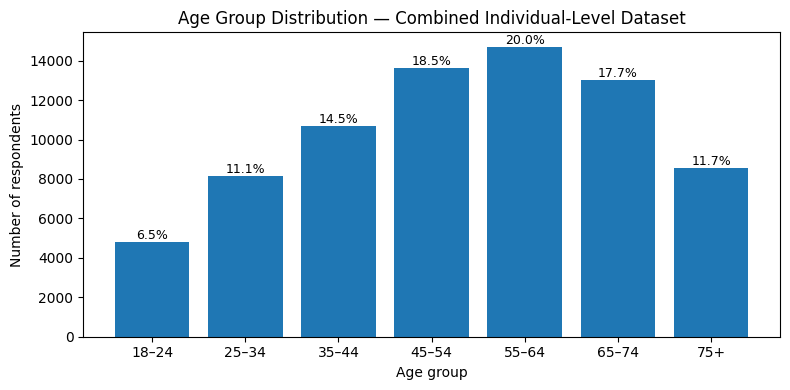

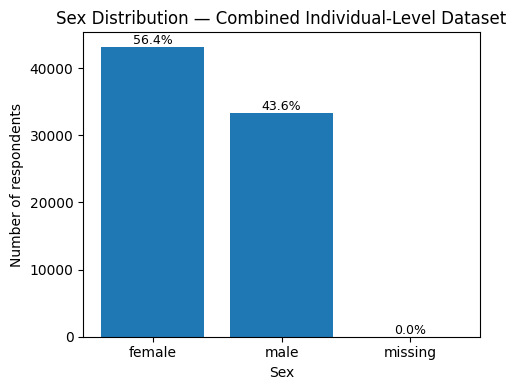

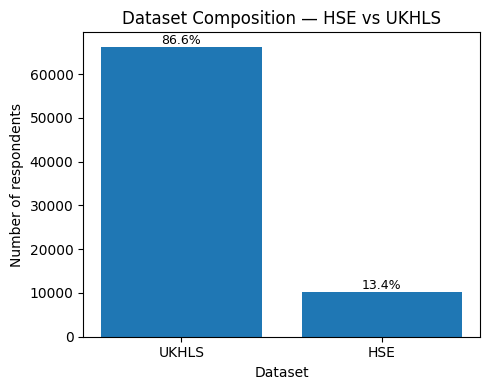

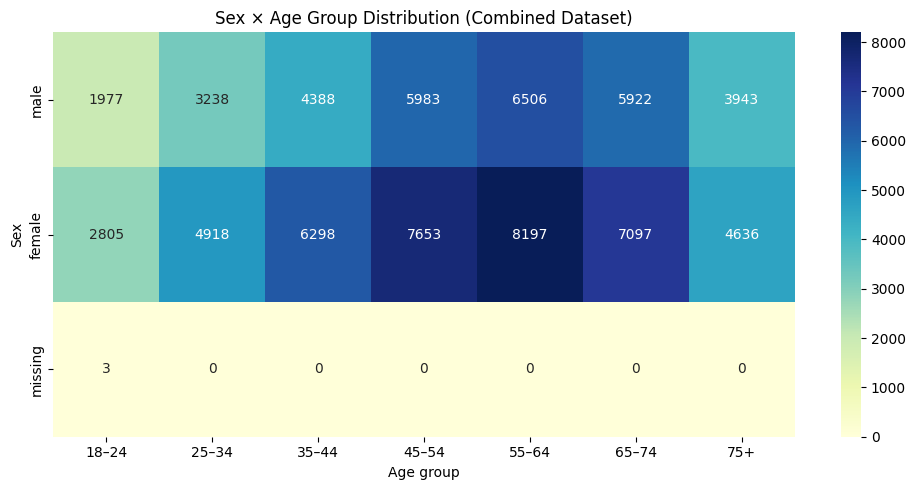

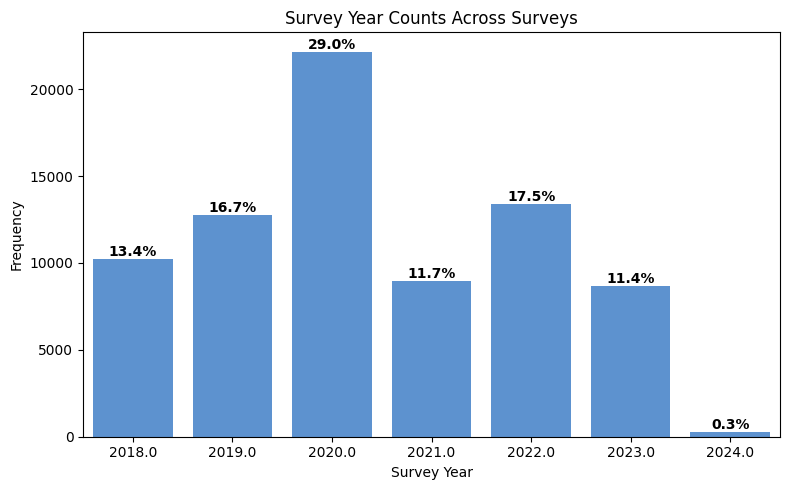

In [10]:
# ================================================================
# 4.3.1 Sample Composition (Cross-Sectional)
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# Load combined individual-level dataset
# ------------------------------------------------
COMBINED_PATH = "data/processed/harmonised/combined_individual_level.parquet"
df = pd.read_parquet(COMBINED_PATH)

print("=== ANALYTIC SAMPLE LOADED ===")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")
print("--------------------------------------------------")

# ------------------------------------------------
# Helper: count + percentage table
# ------------------------------------------------
def count_percent(series):
    counts = series.value_counts(dropna=False)
    perc = (counts / counts.sum() * 100).round(1)
    return pd.DataFrame({
        "count": counts,
        "percent": perc
    })

# ================================================================
# A. Sex composition (TABLE)
# ================================================================
print("\n=== Sex composition ===")
sex_table = count_percent(df["sex_harmonised"])
display(sex_table)

# ================================================================
# B. Age group composition (TABLE)
# ================================================================
print("\n=== Age group composition ===")
age_table = count_percent(df["age_group_harmonised"])
display(age_table)

# ================================================================
# C. Dataset composition (TABLE)
# ================================================================
print("\n=== Dataset composition ===")
dataset_table = count_percent(df["dataset"])
display(dataset_table)

# ================================================================
# D. Survey year distribution (TABLE)
# ================================================================
print("\n=== Survey year distribution ===")
year_table = count_percent(df["survey_year_harmonised"])
display(year_table.sort_index())

# ================================================================
# PLOT 1 — Age group distribution (Combined dataset)
# ================================================================
age_order = [
    "18–24","25–34","35–44","45–54",
    "55–64","65–74","75+"
]

age_counts = (
    df["age_group_harmonised"]
    .dropna()
    .value_counts()
    .reindex(age_order)
)

age_pct = (age_counts / age_counts.sum()) * 100

plt.figure(figsize=(8,4))
bars = plt.bar(age_counts.index.astype(str), age_counts.values)

for bar, pct in zip(bars, age_pct):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Age Group Distribution — Combined Individual-Level Dataset")
plt.xlabel("Age group")
plt.ylabel("Number of respondents")
plt.tight_layout()
plt.show()

# ================================================================
# PLOT 2 — Sex distribution (Combined dataset)
# ================================================================
sex_counts = df["sex_harmonised"].value_counts()

plt.figure(figsize=(5,4))
bars = plt.bar(sex_counts.index.astype(str), sex_counts.values)

for bar, pct in zip(bars, sex_counts / sex_counts.sum() * 100):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Sex Distribution — Combined Individual-Level Dataset")
plt.xlabel("Sex")
plt.ylabel("Number of respondents")
plt.tight_layout()
plt.show()

# ================================================================
# PLOT 3 — Dataset composition (HSE vs UKHLS)
# ================================================================
ds_counts = df["dataset"].value_counts()

plt.figure(figsize=(5,4))
bars = plt.bar(ds_counts.index.astype(str), ds_counts.values)

for bar, pct in zip(bars, ds_counts / ds_counts.sum() * 100):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Dataset Composition — HSE vs UKHLS")
plt.xlabel("Dataset")
plt.ylabel("Number of respondents")
plt.tight_layout()
plt.show()

# ================================================================
# PLOT 4 — Sex × Age group cross-tabulation (Heatmap)
# ================================================================
ct_sex_age = pd.crosstab(
    df["sex_harmonised"],
    df["age_group_harmonised"]
)

ct_sex_age = ct_sex_age.reindex(columns=age_order)
# Create crosstab
plt.figure(figsize=(10,5))
sns.heatmap(
    ct_sex_age,
    annot=True,
    fmt="d",
    cmap="YlGnBu"
)

plt.title("Sex × Age Group Distribution (Combined Dataset)")
plt.xlabel("Age group")
plt.ylabel("Sex")
plt.tight_layout()
plt.show()

# 5 Survey Year Distribution (Uniform colour + % labels)
plt.figure(figsize=(8,5))

# Use a single colour (adjust if you'd prefer another)
ax = sns.countplot(
    data=combined,
    x="survey_year_harmonised",
    color="#4A90E2"   # consistent blue tone
)

plt.title("Survey Year Counts Across Surveys")
plt.xlabel("Survey Year")
plt.ylabel("Frequency")

# ----- Add % labels above each bar -----
total = len(combined)

for p in ax.patches:
    count = p.get_height()
    pct = 100 * count / total
    ax.annotate(f"{pct:.1f}%",
                (p.get_x() + p.get_width() / 2., count),
                ha="center", va="bottom",
                fontsize=10, fontweight="bold")

plt.tight_layout()
#   plt.savefig(f"{EDA_DIR}/combined_survey_year_distribution.png", dpi=300)
plt.show()


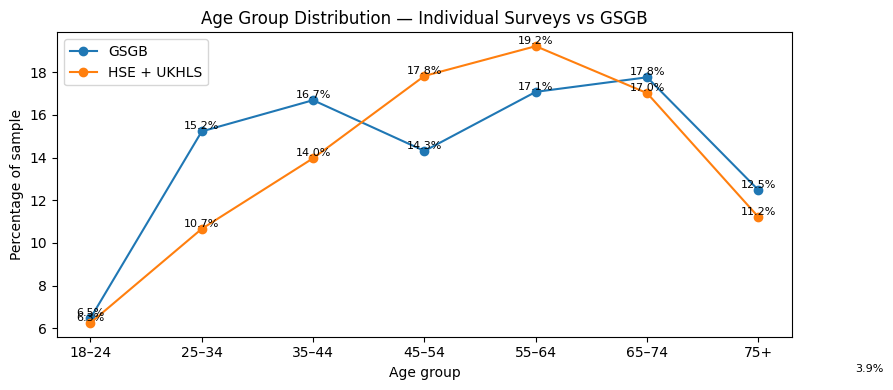

In [11]:
# ================================================================
# 4.3.1 Sample Composition (Contextual EDA)
# Includes GSGB for descriptive comparison ONLY
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# Load datasets
# ------------------------------------------------
combined = pd.read_parquet(
    "data/processed/harmonised/combined_individual_level.parquet"
)

gsgb = pd.read_parquet(
    "data/processed/harmonised/gsgb_harmonised.parquet"
)

# ------------------------------------------------
# Prepare GSGB for plotting
# (use unweighted counts; age rows only)
# ------------------------------------------------
gsgb_age = (
    gsgb[gsgb["group_type"] == "age"]
    .copy()
)

# Use unweighted_n as proxy counts
gsgb_age = gsgb_age.dropna(subset=["age_group_harmonised", "unweighted_n"])
gsgb_age["count"] = gsgb_age["unweighted_n"]
gsgb_age["source"] = "GSGB"

# ------------------------------------------------
# Prepare combined individual-level data
# ------------------------------------------------
ind_age = (
    combined["age_group_harmonised"]
    .value_counts()
    .rename("count")
    .reset_index()
    .rename(columns={"index": "age_group_harmonised"})
)

ind_age["source"] = "HSE + UKHLS"

# ------------------------------------------------
# Combine for plotting
# ------------------------------------------------
plot_df = pd.concat(
    [
        ind_age[["age_group_harmonised", "count", "source"]],
        gsgb_age[["age_group_harmonised", "count", "source"]]
    ],
    ignore_index=True
)

# Calculate percentages within each source
plot_df["percent"] = (
    plot_df
    .groupby("source")["count"]
    .transform(lambda x: x / x.sum() * 100)
)

# ------------------------------------------------
# Plot — Age group distribution
# ------------------------------------------------
age_order = [
    "18–24","25–34","35–44","45–54",
    "55–64","65–74","75+"
]

plt.figure(figsize=(9, 4))

for source, sub in plot_df.groupby("source"):
    sub = sub.set_index("age_group_harmonised").reindex(age_order).dropna()
    plt.plot(
        sub.index.astype(str),
        sub["percent"],
        marker="o",
        label=source
    )

for _, row in plot_df.iterrows():
    plt.text(
        row["age_group_harmonised"],
        row["percent"],
        f"{row['percent']:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

plt.title("Age Group Distribution — Individual Surveys vs GSGB")
plt.xlabel("Age group")
plt.ylabel("Percentage of sample")
plt.legend()
plt.tight_layout()
plt.show()


=== OUTCOME DISTRIBUTIONS (CROSS-SECTIONAL) ===
HSE rows:   10,250 | columns: 29
UKHLS rows: 66,264 | columns: 40
--------------------------------------------------

--- 2) PGSI-3 distribution (HSE) ---
PGSI (3-category) distribution:


,count,percent
pgsi_3cat,,
No risk,6684,65.2
Low risk,164,1.6
At-risk gambling,75,0.7
missing,3327,32.5


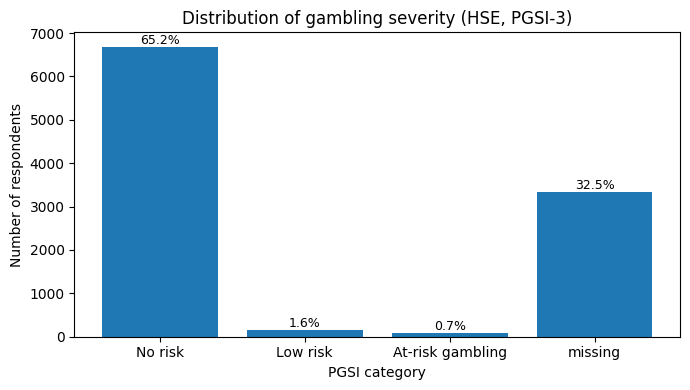


PGSI score summary statistics (HSE):


,count,mean,median,std,min,max
0,6923,0.11,0.0,1.0,0.0,27.0



--- 3) GHQ-12 distribution (HSE) ---
GHQ-12 psychological distress summary (HSE):


,count,mean,median,std,min,max
0,7503,1.57,0.0,2.8,0.0,12.0


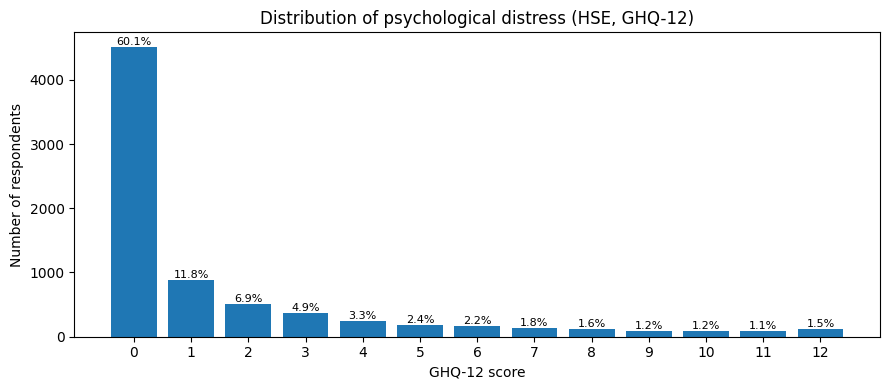


--- 4) Mental health score distribution (UKHLS) ---
Mental health score summary (UKHLS):


,count,mean,median,std,min,max
0,64767,11.68,11.0,5.66,0.0,36.0


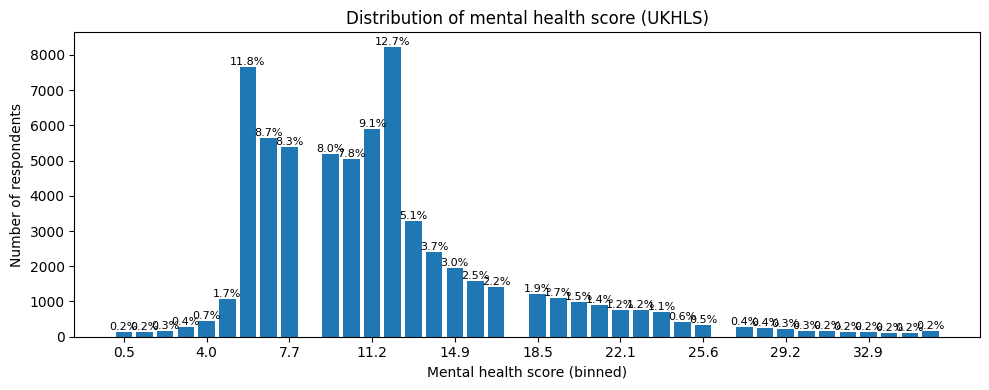


Note:
PGSI is available only in HSE, so gambling severity is described using the HSE sample.
GHQ-12 (HSE) and mental_health_score (UKHLS) are presented as separate outcome distributions,
because they are measured on different scales and are not directly interchangeable.
All plots show sample size on the y-axis and percentage labels for ease of comparison.
Missing PGSI categories reflect non-response to PGSI items rather than an absence of gambling behaviour.


In [12]:
# ================================================================
# SECTION 4.3.2 — Outcome Distributions (Cross-Sectional)
# ================================================================
# Purpose:
#   Describe gambling severity and mental health outcomes independently.
#
# Outputs:
#   (1) PGSI-3 distribution (HSE) — bar chart (COUNTS) + % labels
#   (2) PGSI score summary stats (HSE)
#   (3) GHQ-12 distribution (HSE) — binned bar chart (COUNTS) + % labels
#   (4) GHQ-12 summary stats (HSE)
#   (5) Mental health score distribution (UKHLS) — binned bar chart (COUNTS) + % labels
#   (6) Mental health score summary stats (UKHLS)
#
# Notes:
#   - HSE: pgsi_3cat, pgsi_score, ghq12_score
#   - UKHLS: mental_health_score
#   - Y-axis is always sample size (counts); % is shown on bars.
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------
# Paths
# ------------------------------------------------
HSE_PATH   = "data/processed/harmonised/hse_harmonised.parquet"
UKHLS_PATH = "data/processed/harmonised/ukhls_harmonised.parquet"

# ------------------------------------------------
# Load datasets
# ------------------------------------------------
hse   = pd.read_parquet(HSE_PATH)
ukhls = pd.read_parquet(UKHLS_PATH)

print("=== OUTCOME DISTRIBUTIONS (CROSS-SECTIONAL) ===")
print(f"HSE rows:   {hse.shape[0]:,} | columns: {hse.shape[1]:,}")
print(f"UKHLS rows: {ukhls.shape[0]:,} | columns: {ukhls.shape[1]:,}")
print("--------------------------------------------------")

# ------------------------------------------------
# Helper: annotate % on bar charts (counts on y-axis)
# ------------------------------------------------
def annotate_bar_percents(ax, counts, fontsize=9):
    """
    counts: array-like counts in the same order as bars drawn.
    Adds % label above each bar based on total counts.
    """
    total = np.nansum(counts)
    if total == 0:
        return
    for rect, c in zip(ax.patches, counts):
        if c and c > 0:
            pct = (c / total) * 100
            ax.text(
                rect.get_x() + rect.get_width() / 2,
                rect.get_height(),
                f"{pct:.1f}%",
                ha="center",
                va="bottom",
                fontsize=fontsize
            )

def summary_stats(series: pd.Series) -> pd.DataFrame:
    s = pd.to_numeric(series, errors="coerce").dropna()
    return pd.DataFrame({
        "count": [int(s.shape[0])],
        "mean": [s.mean()],
        "median": [s.median()],
        "std": [s.std()],
        "min": [s.min()],
        "max": [s.max()]
    }).round(2)

# ================================================================
# 2️ PGSI-3 distribution (HSE)
# ================================================================
print("\n--- 2) PGSI-3 distribution (HSE) ---")

if "pgsi_3cat" not in hse.columns:
    raise KeyError("pgsi_3cat not found in HSE harmonised data.")

pgsi_order = ["No risk", "Low risk", "At-risk gambling", "missing"]

hse["pgsi_3cat"] = (
    hse["pgsi_3cat"]
    .astype("object")
    .fillna("missing")
)

hse["pgsi_3cat"] = pd.Categorical(
    hse["pgsi_3cat"],
    categories=pgsi_order,
    ordered=True
)

pgsi_counts = hse["pgsi_3cat"].value_counts(dropna=False).sort_index()
pgsi_dist = pd.DataFrame({
    "count": pgsi_counts,
    "percent": (pgsi_counts / pgsi_counts.sum() * 100).round(1)
})

print("PGSI (3-category) distribution:")
display(pgsi_dist)

# Plot: counts + % labels
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(pgsi_dist.index.astype(str), pgsi_dist["count"].values)
annotate_bar_percents(ax, pgsi_dist["count"].values, fontsize=9)
ax.set_ylabel("Number of respondents")
ax.set_xlabel("PGSI category")
ax.set_title("Distribution of gambling severity (HSE, PGSI-3)")
plt.tight_layout()
plt.show()

# PGSI score summary statistics (numeric)
print("\nPGSI score summary statistics (HSE):")
if "pgsi_score" in hse.columns:
    display(summary_stats(hse["pgsi_score"]))
else:
    print("pgsi_score not found in HSE harmonised data.")

# ================================================================
# 3️ GHQ-12 score distribution (HSE)
# ================================================================
print("\n--- 3) GHQ-12 distribution (HSE) ---")

if "ghq12_score" not in hse.columns:
    raise KeyError("ghq12_score not found in HSE harmonised data.")

ghq = pd.to_numeric(hse["ghq12_score"], errors="coerce").dropna()

print("GHQ-12 psychological distress summary (HSE):")
display(summary_stats(ghq))

# GHQ-12 is typically 0–12 (in your data max is 12)
# Use integer bins centered on each score: 0,1,2,...,12
ghq_min = int(np.floor(ghq.min())) if len(ghq) else 0
ghq_max = int(np.ceil(ghq.max())) if len(ghq) else 12
ghq_bins = np.arange(ghq_min - 0.5, ghq_max + 1.5, 1)

ghq_counts, edges = np.histogram(ghq, bins=ghq_bins)
ghq_labels = [str(int(e + 0.5)) for e in edges[:-1]]  # label each integer score

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(ghq_labels, ghq_counts)
annotate_bar_percents(ax, ghq_counts, fontsize=8)
ax.set_ylabel("Number of respondents")
ax.set_xlabel("GHQ-12 score")
ax.set_title("Distribution of psychological distress (HSE, GHQ-12)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ================================================================
# 4️ Mental health score distribution (UKHLS)
# ================================================================
print("\n--- 4) Mental health score distribution (UKHLS) ---")

if "mental_health_score" not in ukhls.columns:
    raise KeyError("mental_health_score not found in UKHLS harmonised data.")

mh = pd.to_numeric(ukhls["mental_health_score"], errors="coerce").dropna()

print("Mental health score summary (UKHLS):")
display(summary_stats(mh))

# UKHLS mental_health_score often has a wider range than GHQ-12.
# Use data-driven binning (Freedman–Diaconis), with a safe fallback.
def fd_bins(x: pd.Series, fallback=20):
    x = x.dropna()
    if x.shape[0] < 2:
        return fallback
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    if iqr <= 0:
        return fallback
    bin_width = 2 * iqr / (x.shape[0] ** (1/3))
    if bin_width <= 0:
        return fallback
    bins = int(np.ceil((x.max() - x.min()) / bin_width))
    return max(10, min(40, bins))  # keep readable

mh_nbins = fd_bins(mh, fallback=20)

mh_counts, mh_edges = np.histogram(mh, bins=mh_nbins)
mh_centers = (mh_edges[:-1] + mh_edges[1:]) / 2
mh_labels = [f"{c:.1f}" for c in mh_centers]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(mh_counts)), mh_counts)
annotate_bar_percents(ax, mh_counts, fontsize=8)
ax.set_ylabel("Number of respondents")
ax.set_xlabel("Mental health score (binned)")
ax.set_title("Distribution of mental health score (UKHLS)")
# Show fewer x tick labels to avoid clutter
step = max(1, len(mh_labels) // 10)
ax.set_xticks(range(0, len(mh_labels), step))
ax.set_xticklabels([mh_labels[i] for i in range(0, len(mh_labels), step)], rotation=0)
plt.tight_layout()
plt.show()

# ================================================================
# Interpretation note (Chapter 4 narrative)
# ================================================================
print(
    "\nNote:\n"
    "PGSI is available only in HSE, so gambling severity is described using the HSE sample.\n"
    "GHQ-12 (HSE) and mental_health_score (UKHLS) are presented as separate outcome distributions,\n"
    "because they are measured on different scales and are not directly interchangeable.\n"
    "All plots show sample size on the y-axis and percentage labels for ease of comparison.\n"
    "Missing PGSI categories reflect non-response to PGSI items rather than an absence of gambling behaviour."
)


=== HSE DATA FOR SOCIO-DEMOGRAPHIC ANALYSIS ===
Rows: 10,250
--------------------------------------------------

=== Gambling severity by sex ===


pgsi_3cat,No risk,Low risk,At-risk gambling,missing
sex_harmonised,,,,
male,2908,118,59,1603
female,3776,46,16,1724


pgsi_3cat,No risk,Low risk,At-risk gambling,missing
sex_harmonised,,,,
male,62.0,2.5,1.3,34.2
female,67.9,0.8,0.3,31.0


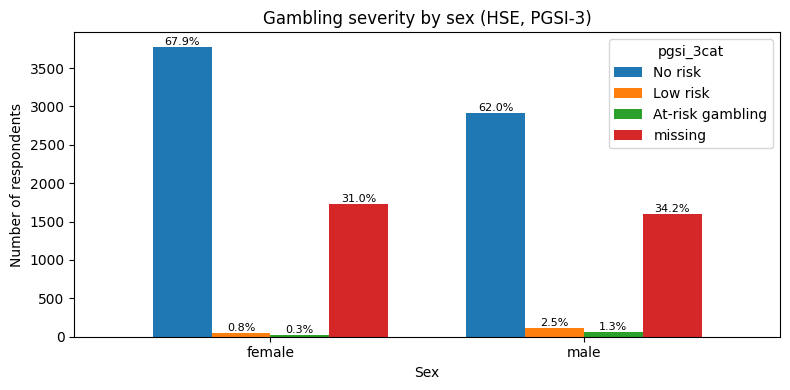

Chi-square (sex × PGSI-binary): χ²(1) = 85.95, p = 0.0000
Cramér’s V: 0.111


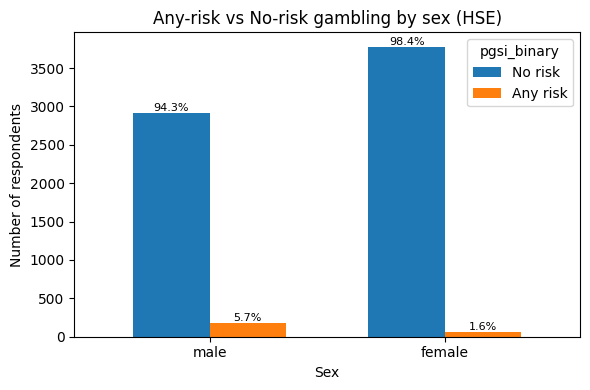


=== Gambling severity by age group ===


pgsi_3cat,No risk,Low risk,At-risk gambling,missing
age_group_harmonised,,,,
18–24,258,12,0,70
25–34,708,30,19,153
35–44,1079,48,19,167
45–54,1085,31,16,182
55–64,1180,20,13,202
65–74,1136,12,4,168
75+,1076,10,2,243
missing,162,1,2,2142


pgsi_3cat,No risk,Low risk,At-risk gambling,missing
age_group_harmonised,,,,
18–24,75.9,3.5,0.0,20.6
25–34,77.8,3.3,2.1,16.8
35–44,82.2,3.7,1.4,12.7
45–54,82.6,2.4,1.2,13.9
55–64,83.4,1.4,0.9,14.3
65–74,86.1,0.9,0.3,12.7
75+,80.8,0.8,0.2,18.3
missing,7.0,0.0,0.1,92.8


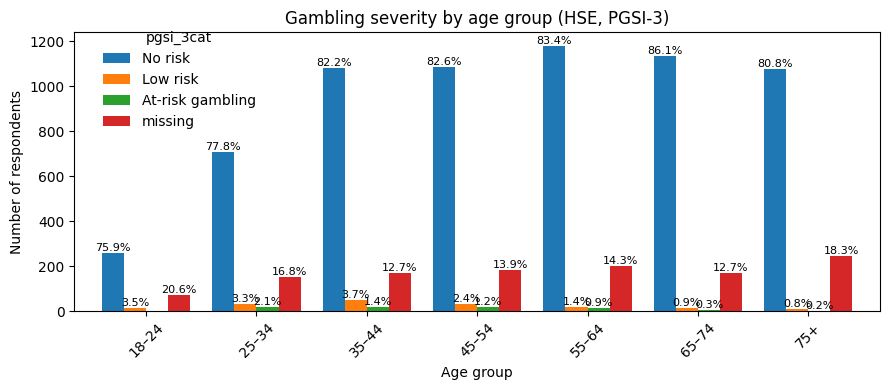

Chi-square (age × PGSI-binary): χ²(6) = 76.68, p = 0.0000
Cramér’s V: 0.107


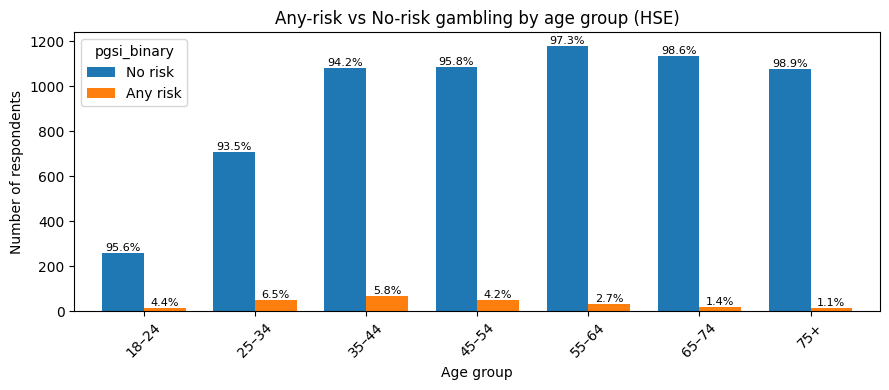


=== Gambling severity by income quintile (descriptive only) ===


pgsi_3cat,No risk,Low risk,At-risk gambling,missing
income_quintile_harmonised,,,,
1,47,1,0,14
3,21,1,0,11
5,18,1,0,5
missing,6598,161,75,3297


pgsi_3cat,No risk,Low risk,At-risk gambling,missing
income_quintile_harmonised,,,,
1,75.8,1.6,0.0,22.6
3,63.6,3.0,0.0,33.3
5,75.0,4.2,0.0,20.8
missing,65.1,1.6,0.7,32.5



Note:
Income data are missing for a large proportion of the HSE sample.
Income-based results are descriptive only and not used for inference.


In [13]:
# ================================================================
# 4.3.3 Gambling Severity by Socio-Demographic Characteristics (HSE)
# ================================================================
# Outcome:
#   - Gambling severity (PGSI)
#
# Approach:
#   - Descriptive: PGSI-3 categories (includes missing)
#   - Inferential: PGSI-binary (excludes missing)
#
# Variables:
#   - sex_harmonised
#   - age_group_harmonised
#   - income_quintile_harmonised (descriptive only)
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# ------------------------------------------------
# Load HSE harmonised dataset
# ------------------------------------------------
HSE_PATH = "data/processed/harmonised/hse_harmonised.parquet"
hse = pd.read_parquet(HSE_PATH)

print("=== HSE DATA FOR SOCIO-DEMOGRAPHIC ANALYSIS ===")
print(f"Rows: {hse.shape[0]:,}")
print("--------------------------------------------------")

# ------------------------------------------------
# PGSI-3 (DESCRIPTIVE)
# ------------------------------------------------
pgsi3_order = ["No risk", "Low risk", "At-risk gambling", "missing"]

hse["pgsi_3cat"] = (
    hse["pgsi_3cat"]
    .astype("object")
    .fillna("missing")
)

hse["pgsi_3cat"] = pd.Categorical(
    hse["pgsi_3cat"],
    categories=pgsi3_order,
    ordered=True
)

# ------------------------------------------------
# PGSI-BINARY (INFERENTIAL)
# ------------------------------------------------
def pgsi_binary_map(x):
    if x in ["Low risk", "At-risk gambling"]:
        return "Any risk"
    if x == "No risk":
        return "No risk"
    return "missing"

hse["pgsi_binary"] = hse["pgsi_3cat"].astype("object").apply(pgsi_binary_map)

hse["pgsi_binary"] = pd.Categorical(
    hse["pgsi_binary"],
    categories=["No risk", "Any risk", "missing"],
    ordered=True
)

# ------------------------------------------------
# Helper: annotate bar percentages
# ------------------------------------------------
def annotate_percentages(ax, counts_df):
    totals = counts_df.sum(axis=1)
    for container in ax.containers:
        for bar, total in zip(container, totals):
            if bar.get_height() > 0:
                pct = (bar.get_height() / total) * 100
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height(),
                    f"{pct:.1f}%",
                    ha="center",
                    va="bottom",
                    fontsize=8
                )

# ================================================================
# A. SEX
# ================================================================
print("\n=== Gambling severity by sex ===")

# --- Descriptive (PGSI-3) ---
ct_sex = pd.crosstab(hse["sex_harmonised"], hse["pgsi_3cat"])
display(ct_sex)
display((ct_sex.div(ct_sex.sum(axis=1), axis=0) * 100).round(1))

ax = ct_sex.loc[["female", "male"]].plot(
    kind="bar", figsize=(8,4), width=0.75
)
annotate_percentages(ax, ct_sex.loc[["female", "male"]])
plt.title("Gambling severity by sex (HSE, PGSI-3)")
plt.ylabel("Number of respondents")
plt.xlabel("Sex")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Inferential (PGSI-binary) ---
sex_bin = hse[
    (hse["sex_harmonised"] != "missing") &
    (hse["pgsi_binary"] != "missing")
]

ct_sex_bin = pd.crosstab(sex_bin["sex_harmonised"], sex_bin["pgsi_binary"])

chi2, p, dof, _ = chi2_contingency(ct_sex_bin)
n = ct_sex_bin.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_sex_bin.shape) - 1)))

print(f"Chi-square (sex × PGSI-binary): χ²({dof}) = {chi2:.2f}, p = {p:.4f}")
print(f"Cramér’s V: {cramers_v:.3f}")

ax = ct_sex_bin.plot(kind="bar", figsize=(6,4), width=0.65)
annotate_percentages(ax, ct_sex_bin)
plt.title("Any-risk vs No-risk gambling by sex (HSE)")
plt.ylabel("Number of respondents")
plt.xlabel("Sex")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ================================================================
# B. AGE GROUP
# ================================================================
print("\n=== Gambling severity by age group ===")

# --- Descriptive (PGSI-3) ---
ct_age = pd.crosstab(hse["age_group_harmonised"], hse["pgsi_3cat"])
display(ct_age)
display((ct_age.div(ct_age.sum(axis=1), axis=0) * 100).round(1))

ax = ct_age.drop(index="missing").plot(
    kind="bar", figsize=(9,4), width=0.80
)
annotate_percentages(ax, ct_age.drop(index="missing"))
plt.title("Gambling severity by age group (HSE, PGSI-3)")
plt.ylabel("Number of respondents")
plt.xlabel("Age group")
plt.xticks(rotation=45)
plt.legend(
    title="pgsi_3cat",
    loc="upper center",
    bbox_to_anchor=(0.13, 1.05),
    frameon=False
)
plt.tight_layout()
plt.show()

# --- Inferential (PGSI-binary) ---
age_bin = hse[
    (hse["age_group_harmonised"] != "missing") &
    (hse["pgsi_binary"] != "missing")
]

ct_age_bin = pd.crosstab(age_bin["age_group_harmonised"], age_bin["pgsi_binary"])

chi2, p, dof, _ = chi2_contingency(ct_age_bin)
n = ct_age_bin.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct_age_bin.shape) - 1)))

print(f"Chi-square (age × PGSI-binary): χ²({dof}) = {chi2:.2f}, p = {p:.4f}")
print(f"Cramér’s V: {cramers_v:.3f}")

ax = ct_age_bin.plot(kind="bar", figsize=(9,4), width=0.75)
annotate_percentages(ax, ct_age_bin)
plt.title("Any-risk vs No-risk gambling by age group (HSE)")
plt.ylabel("Number of respondents")
plt.xlabel("Age group")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ================================================================
# C. INCOME (DESCRIPTIVE ONLY)
# ================================================================
print("\n=== Gambling severity by income quintile (descriptive only) ===")

ct_inc = pd.crosstab(hse["income_quintile_harmonised"], hse["pgsi_3cat"])
display(ct_inc)
display((ct_inc.div(ct_inc.sum(axis=1), axis=0) * 100).round(1))



print(
    "\nNote:\n"
    "Income data are missing for a large proportion of the HSE sample.\n"
    "Income-based results are descriptive only and not used for inference."
)


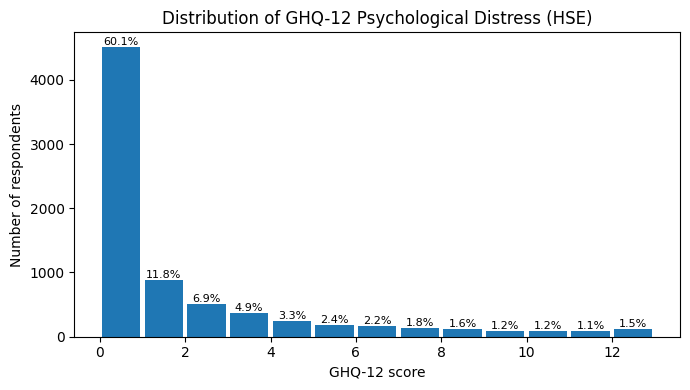


GHQ-12 summary statistics (HSE):


mean     1.57
50%      0.00
std      2.80
min      0.00
max     12.00
Name: ghq12_score, dtype: float64

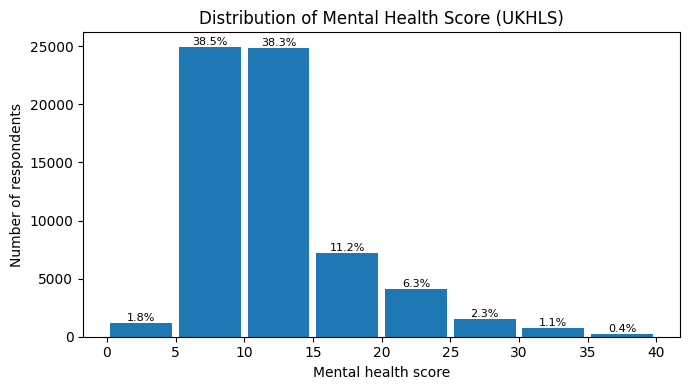


Mental health score summary (UKHLS):


mean    11.68
50%     11.00
std      5.66
min      0.00
max     36.00
Name: mental_health_score, dtype: float64

In [14]:
# ================================================================
# 4.3.4a Mental Health Outcome Distributions (Cross-Sectional)
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Load datasets
# ------------------------------------------------
hse = pd.read_parquet("data/processed/harmonised/hse_harmonised.parquet")
ukhls = pd.read_parquet("data/processed/harmonised/ukhls_harmonised.parquet")

# ------------------------------------------------
# Helper: histogram with percentage labels
# ------------------------------------------------
def hist_with_percent(data, bins, xlabel, title):
    counts, bin_edges = np.histogram(data, bins=bins)
    percent = counts / counts.sum() * 100
    bin_centers = bin_edges[:-1] + np.diff(bin_edges) / 2

    plt.figure(figsize=(7,4))
    bars = plt.bar(bin_centers, counts, width=np.diff(bin_edges)*0.9)

    for bar, pct in zip(bars, percent):
        if bar.get_height() > 0:
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"{pct:.1f}%",
                ha="center",
                va="bottom",
                fontsize=8
            )

    plt.xlabel(xlabel)
    plt.ylabel("Number of respondents")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------
# HSE: GHQ-12 distribution
# ------------------------------------------------
ghq = hse["ghq12_score"].dropna()

# GHQ-12 is integer-scaled (0–12)
ghq_bins = np.arange(0, 14)

hist_with_percent(
    ghq,
    bins=ghq_bins,
    xlabel="GHQ-12 score",
    title="Distribution of GHQ-12 Psychological Distress (HSE)"
)

# Summary statistics
ghq_summary = ghq.describe()[["mean","50%","std","min","max"]].round(2)
print("\nGHQ-12 summary statistics (HSE):")
display(ghq_summary)

# ------------------------------------------------
# UKHLS: Mental health score distribution
# ------------------------------------------------
mh = ukhls["mental_health_score"].dropna()

# Broader UKHLS scale → wider bins
mh_bins = np.arange(0, mh.max() + 5, 5)

hist_with_percent(
    mh,
    bins=mh_bins,
    xlabel="Mental health score",
    title="Distribution of Mental Health Score (UKHLS)"
)

mh_summary = mh.describe()[["mean","50%","std","min","max"]].round(2)
print("\nMental health score summary (UKHLS):")
display(mh_summary)


HSE GHQ-12 by sex (Mann–Whitney U): U=6362386, p=0.0000, r=0.085


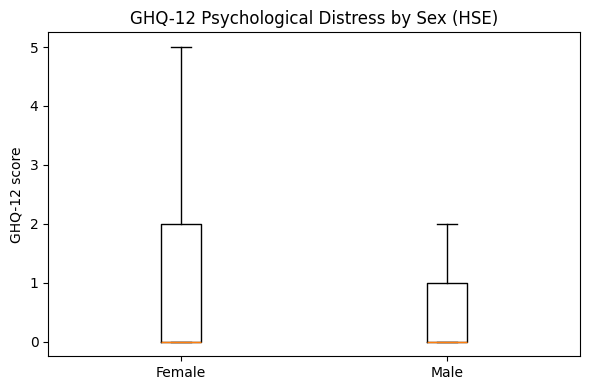

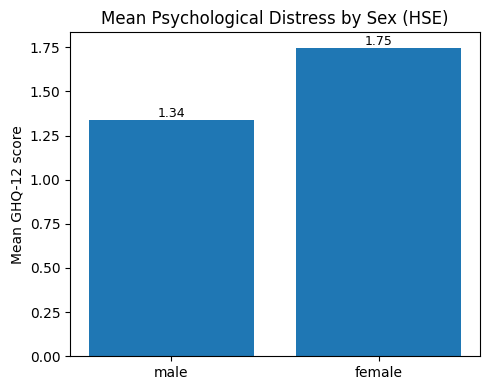

HSE GHQ-12 by age group (Kruskal–Wallis): H=76.10, p=0.0000


<Figure size 900x400 with 0 Axes>

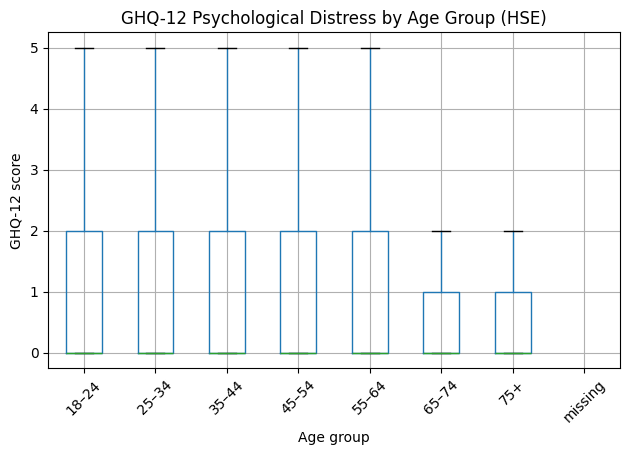

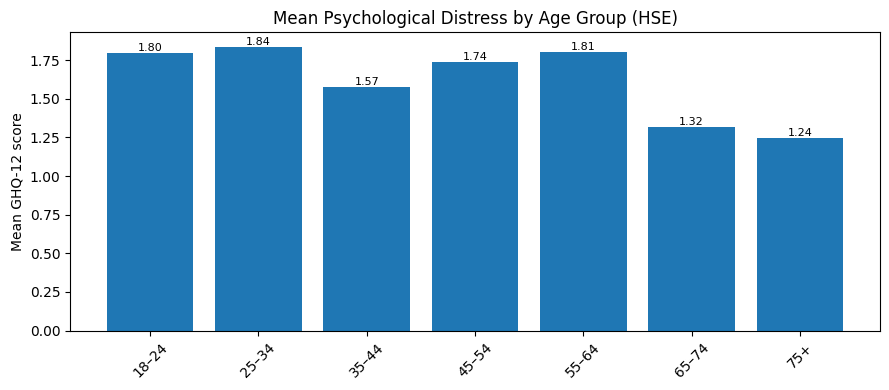

HSE GHQ-12 by income quintile (Kruskal–Wallis, descriptive): H=1.05, p=0.5928


<Figure size 800x400 with 0 Axes>

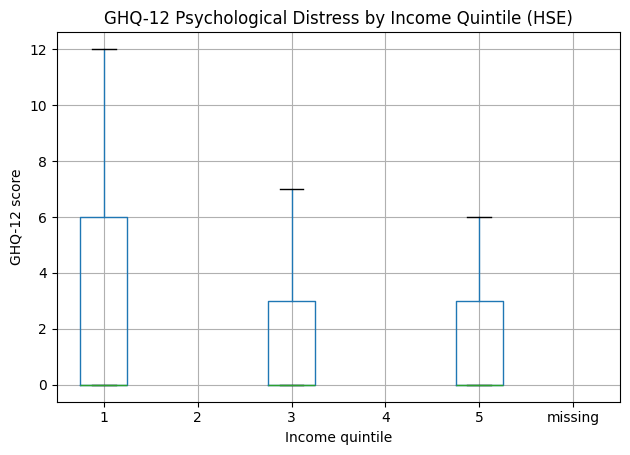

Note:
Income data are missing for a substantial proportion of the HSE sample.
Income-based analyses are descriptive and interpreted cautiously.


In [15]:
# ================================================================
# 4.3.4b Mental Health by Socio-Demographic Characteristics
# ================================================================
# Non-parametric comparisons:
# - Mann–Whitney U (sex)
# - Kruskal–Wallis (age group / income)
#
# Includes:
# - Statistical tests
# - Effect sizes
# - Boxplots (distributional evidence)
# - Bar charts (mean differences for interpretability)
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, kruskal

# ------------------------------------------------
# Helper: rank-biserial effect size (Mann–Whitney)
# ------------------------------------------------
def rank_biserial(u, n1, n2):
    return 1 - (2 * u) / (n1 * n2)

# ================================================================
# A. HSE — GHQ-12 by Sex
# ================================================================
ghq_sex = hse[
    (hse["sex_harmonised"].isin(["male", "female"])) &
    (hse["ghq12_score"].notna())
]

male = ghq_sex.loc[ghq_sex["sex_harmonised"] == "male", "ghq12_score"]
female = ghq_sex.loc[ghq_sex["sex_harmonised"] == "female", "ghq12_score"]

u_sex, p_sex = mannwhitneyu(male, female, alternative="two-sided")
r_sex = rank_biserial(u_sex, len(male), len(female))

print(
    f"HSE GHQ-12 by sex (Mann–Whitney U): "
    f"U={u_sex:.0f}, p={p_sex:.4f}, r={r_sex:.3f}"
)

# ---- Boxplot (distribution) ----
plt.figure(figsize=(6,4))
plt.boxplot(
    [female, male],
    tick_labels=["Female", "Male"],
    showfliers=False
)
plt.ylabel("GHQ-12 score")
plt.title("GHQ-12 Psychological Distress by Sex (HSE)")
plt.tight_layout()
plt.show()

# ---- Bar chart (mean GHQ-12) ----
sex_means = ghq_sex.groupby("sex_harmonised", observed=False)["ghq12_score"].mean()

plt.figure(figsize=(5,4))
bars = plt.bar(sex_means.index, sex_means.values)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center", va="bottom", fontsize=9
    )

plt.ylabel("Mean GHQ-12 score")
plt.title("Mean Psychological Distress by Sex (HSE)")
plt.tight_layout()
plt.show()

# ================================================================
# B. HSE — GHQ-12 by Age Group
# ================================================================
ghq_age = hse[
    (hse["age_group_harmonised"] != "missing") &
    (hse["ghq12_score"].notna())
]

groups = [
    g["ghq12_score"].values
    for _, g in ghq_age.groupby(
        "age_group_harmonised", observed=False
    )
    if g.shape[0] > 10
]

h_age, p_age = kruskal(*groups)

print(
    f"HSE GHQ-12 by age group (Kruskal–Wallis): "
    f"H={h_age:.2f}, p={p_age:.4f}"
)

# ---- Boxplot ----
plt.figure(figsize=(9,4))
ghq_age.boxplot(
    column="ghq12_score",
    by="age_group_harmonised",
    showfliers=False
)
plt.suptitle("")
plt.title("GHQ-12 Psychological Distress by Age Group (HSE)")
plt.xlabel("Age group")
plt.ylabel("GHQ-12 score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ---- Bar chart (means) ----
age_means = (
    ghq_age
    .groupby("age_group_harmonised", observed=False)["ghq12_score"]
    .mean()
)

plt.figure(figsize=(9,4))
bars = plt.bar(age_means.index, age_means.values)

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha="center", va="bottom", fontsize=8
    )

plt.ylabel("Mean GHQ-12 score")
plt.title("Mean Psychological Distress by Age Group (HSE)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ================================================================
# C. HSE — GHQ-12 by Income Quintile (DESCRIPTIVE)
# ================================================================
ghq_income = hse[
    (hse["income_quintile_harmonised"] != "missing") &
    (hse["ghq12_score"].notna())
]

groups = [
    g["ghq12_score"].values
    for _, g in ghq_income.groupby(
        "income_quintile_harmonised", observed=False
    )
    if g.shape[0] > 10
]

h_inc, p_inc = kruskal(*groups)

print(
    f"HSE GHQ-12 by income quintile (Kruskal–Wallis, descriptive): "
    f"H={h_inc:.2f}, p={p_inc:.4f}"
)

# ---- Boxplot ----
plt.figure(figsize=(8,4))
ghq_income.boxplot(
    column="ghq12_score",
    by="income_quintile_harmonised",
    showfliers=False
)
plt.suptitle("")
plt.title("GHQ-12 Psychological Distress by Income Quintile (HSE)")
plt.xlabel("Income quintile")
plt.ylabel("GHQ-12 score")
plt.tight_layout()
plt.show()

print(
    "Note:\n"
    "Income data are missing for a substantial proportion of the HSE sample.\n"
    "Income-based analyses are descriptive and interpreted cautiously."
)



=== UKHLS LOADED ===
Rows: 66,264 | Columns: 40

=== CLEAN EMPLOYMENT STATUS ===
employment_clean
Not in labour force    30836
Employed               26135
Unemployed              9293
Name: count, dtype: int64

=== FINAL ANALYTIC SAMPLE ===
Rows: 64,760
Participants: 22,036
Survey years: 2019.0–2024.0

=== GEE MAIN EFFECTS MODEL ===
                               GEE Regression Results                              
Dep. Variable:         mental_health_score   No. Observations:                64760
Model:                                 GEE   No. clusters:                    22036
Method:                        Generalized   Min. cluster size:                   1
                      Estimating Equations   Max. cluster size:                   3
Family:                           Gaussian   Mean cluster size:                 2.9
Dependence structure:         Exchangeable   Num. iterations:                     6
Date:                     Tue, 06 Jan 2026   Scale:                         

,employment_clean,income_quintile_harmonised,mean,median,n
0,Employed,1,11.39,11.0,783
1,Employed,2,11.91,11.0,2844
2,Employed,3,11.80,11.0,6145
3,Employed,4,11.54,11.0,7705
4,Employed,5,11.08,10.0,8369
5,Not in labour force,1,12.42,11.0,10144
6,Not in labour force,2,11.85,11.0,7180
7,Not in labour force,3,11.82,11.0,5043
8,Not in labour force,4,11.42,10.0,4034
9,Not in labour force,5,10.63,9.0,3332


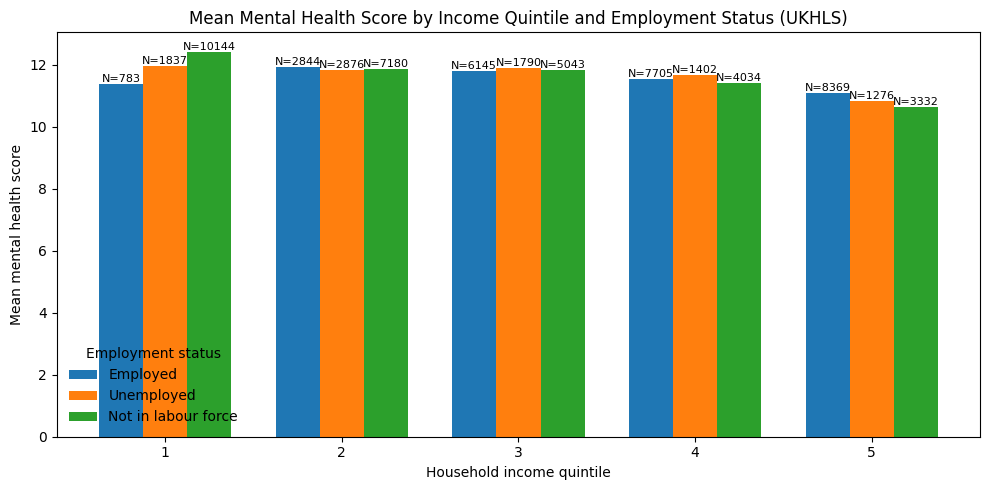

In [16]:
# ================================================================
# UKHLS — Mental Health by Income Quintile × Employment Status
# Includes:
# - sanity outputs (exact blocks)
# - GEE main-effects model output
# - income × employment summary table (mean/median/N)
# - grouped bar plot with N labels
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings

# ------------------------------------------------
# 1) Load dataset
# ------------------------------------------------
ukhls = pd.read_parquet("data/processed/harmonised/ukhls_harmonised.parquet")

print("=== UKHLS LOADED ===")
print(f"Rows: {ukhls.shape[0]:,} | Columns: {ukhls.shape[1]:,}")

# ------------------------------------------------
# 2) Clean employment status (conceptual)
# ------------------------------------------------
ukhls["employment_clean"] = np.select(
    [
        ukhls["employment_status"] == 1,
        ukhls["employment_status"] == 2
    ],
    [
        "Employed",
        "Unemployed"
    ],
    default="Not in labour force"
)

print("\n=== CLEAN EMPLOYMENT STATUS ===")
print(ukhls["employment_clean"].value_counts())

# ------------------------------------------------
# 3) Final analytic sample (as you reported)
#    NOTE:
#    - keep income != "missing" for modelling and plotting clarity
#    - keep sex in {male,female} to avoid nan SE lines
# ------------------------------------------------
df = ukhls[
    (ukhls["mental_health_score"].notna()) &
    (ukhls["income_quintile_harmonised"] != "missing") &
    (ukhls["sex_harmonised"].isin(["male", "female"])) &
    (ukhls["age_years"].notna())
].copy()

# age centering for stability and interpretation
df["age_years_c"] = df["age_years"] - df["age_years"].mean()

print("\n=== FINAL ANALYTIC SAMPLE ===")
print(f"Rows: {df.shape[0]:,}")
print(f"Participants: {df['participant_id'].nunique():,}")
print(
    f"Survey years: {df['survey_year_harmonised'].min()}–"
    f"{df['survey_year_harmonised'].max()}"
)

# ------------------------------------------------
# 4) GEE main effects model (income + employment + sex + age)
# ------------------------------------------------
print("\n=== GEE MAIN EFFECTS MODEL ===")

# Silence only the common runtime warning from robust SE edge cases
warnings.filterwarnings(
    "ignore",
    category=RuntimeWarning,
    module="statsmodels.genmod.generalized_estimating_equations"
)

gee_model = smf.gee(
    formula=(
        "mental_health_score ~ "
        "C(income_quintile_harmonised) + "
        "C(employment_clean) + "
        "C(sex_harmonised) + "
        "age_years_c"
    ),
    groups="participant_id",
    data=df,
    family=sm.families.Gaussian(),
    cov_struct=sm.cov_struct.Exchangeable()
)

gee_res = gee_model.fit()
print(gee_res.summary())

# ------------------------------------------------
# 5) Summary table: income × employment (mean/median/N)
# ------------------------------------------------
summary_ie = (
    df
    .groupby(["employment_clean", "income_quintile_harmonised"], observed=True)["mental_health_score"]
    .agg(mean="mean", median="median", n="count")
    .reset_index()
)

summary_ie[["mean", "median"]] = summary_ie[["mean", "median"]].round(2)

print("\n=== SUMMARY TABLE: INCOME × EMPLOYMENT (MEAN / MEDIAN / N) ===")
display(summary_ie)

# ------------------------------------------------
# 6) Grouped bar plot (mean mental health) with N labels
# ------------------------------------------------
income_order = ["1", "2", "3", "4", "5"]
employment_order = ["Employed", "Unemployed", "Not in labour force"]

summary_ie["income_quintile_harmonised"] = summary_ie["income_quintile_harmonised"].astype(str)

x = np.arange(len(income_order))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

for i, emp in enumerate(employment_order):
    sub = (
        summary_ie[summary_ie["employment_clean"] == emp]
        .set_index("income_quintile_harmonised")
        .reindex(income_order)
    )

    bars = ax.bar(
        x + i * width,
        sub["mean"],
        width=width,
        label=emp
    )

    # annotate N on bars
    for bar, n in zip(bars, sub["n"]):
        if not pd.isna(n):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
                f"N={int(n)}",
                ha="center",
                va="bottom",
                fontsize=8
            )

ax.set_xlabel("Household income quintile")
ax.set_ylabel("Mean mental health score")
ax.set_title("Mean Mental Health Score by Income Quintile and Employment Status (UKHLS)")

ax.set_xticks(x + width)
ax.set_xticklabels(income_order)

ax.legend(title="Employment status", frameon=False)

plt.tight_layout()
plt.show()


In [17]:
# === Triangulation: HSE × UKHLS × GSGB by sex × age7 × (income where available) ===
import pandas as pd
import numpy as np

HSE_PATH   = "data/processed/harmonised/hse_harmonised.parquet"
UKHLS_PATH = "data/processed/harmonised/ukhls_harmonised.parquet"
GSGB_PATH  = "data/processed/harmonised/gsgb_harmonised.parquet"

hse   = pd.read_parquet(HSE_PATH)
ukhls = pd.read_parquet(UKHLS_PATH)
gsgb  = pd.read_parquet(GSGB_PATH)

# ----------------------------
# Helpers: age → 7 bands; % → proportion
# ----------------------------
age7_order = ["18–24","25–34","35–44","45–54","55–64","65–74","75+"]
sex_order  = ["female","male","missing"]
inc_order  = ["1","2","3","4","5","missing"]

def to_age7_label(s):
    if s is None or (isinstance(s, float) and np.isnan(s)): return np.nan
    x = str(s).strip().lower()
    x = (x.replace("–","-").replace("—","-").replace("to","-")
           .replace("plus","+").replace("years","").replace("year","")
           .replace("yrs","").replace(" ", ""))
    if x in {"75+","75","80-84","85+"}: return "75+"
    left = None
    if "-" in x:
        head = x.split("-")[0]
        digs = "".join(ch for ch in head if ch.isdigit())
        left = int(digs) if digs else None
    else:
        digs = "".join(ch for ch in x if ch.isdigit())
        left = int(digs) if digs else None
    if left is None: return np.nan
    if left < 25: return "18–24"
    if left < 35: return "25–34"
    if left < 45: return "35–44"
    if left < 55: return "45–54"
    if left < 65: return "55–64"
    if left < 75: return "65–74"
    return "75+"

def to_prop(s):
    s = pd.to_numeric(s, errors="coerce")
    if s.dropna().max() is not None and s.dropna().max() > 1.5:
        s = s / 100.0
    return s

# ----------------------------
# HSE summaries (PGSI / GHQ-12 / problem_gambling)
# ----------------------------
hse = hse.copy()
hse["age7"] = hse["age_group_harmonised"].apply(to_age7_label)
hse["sex_harmonised"] = pd.Categorical(hse["sex_harmonised"].fillna("missing"),
                                       categories=sex_order)
hse["age7"] = pd.Categorical(hse["age7"], categories=age7_order, ordered=True)
if "income_quintile_harmonised" in hse.columns:
    hse["income_quintile_harmonised"] = pd.Categorical(
        hse["income_quintile_harmonised"].astype(str),
        categories=inc_order, ordered=True
    )
hse["is_problem_gambler"] = (hse["problem_gambling"].astype(str) == "problem_gambler").astype(float)

hse_keys = ["sex_harmonised","age7","income_quintile_harmonised"] if "income_quintile_harmonised" in hse.columns else ["sex_harmonised","age7"]
hse_sum = (hse
    .dropna(subset=["sex_harmonised","age7"])
    .groupby(hse_keys, observed=True, dropna=False)
    .agg(n_hse=("participant_id","count"),
         pgsi_mean=("pgsi_score","mean"),
         ghq12_mean=("ghq12_score","mean"),
         problem_rate=("is_problem_gambler","mean"))
    .reset_index()
)

# ----------------------------
# UKHLS summaries (anxiety / mental health score)
# ----------------------------
ukhls = ukhls.copy()
ukhls["age7"] = ukhls["age_group_harmonised"].apply(to_age7_label)
ukhls["sex_harmonised"] = pd.Categorical(ukhls["sex_harmonised"].fillna("missing"),
                                         categories=sex_order)
ukhls["age7"] = pd.Categorical(ukhls["age7"], categories=age7_order, ordered=True)
if "income_quintile_harmonised" in ukhls.columns:
    ukhls["income_quintile_harmonised"] = pd.Categorical(
        ukhls["income_quintile_harmonised"].astype(str),
        categories=inc_order, ordered=True
    )

uk_keys = ["sex_harmonised","age7","income_quintile_harmonised"] if "income_quintile_harmonised" in ukhls.columns else ["sex_harmonised","age7"]
uk_sum = (ukhls
    .dropna(subset=["sex_harmonised","age7"])
    .groupby(uk_keys, observed=True, dropna=False)
    .agg(n_ukhls=("participant_id","count"),
         anxiety_mean=("anxiety_level","mean"),
         mh_score_mean=("mental_health_score","mean"))
    .reset_index()
)

# ----------------------------
# GSGB summaries — **use sex_age rows** (preferred)
# ----------------------------
g = gsgb.copy()
g["group_type"] = g.get("group_type", "").astype(str).str.lower()
sex_age_rows = g["group_type"].eq("sex_age")
if sex_age_rows.any():
    df = g.loc[sex_age_rows].copy()

    # Sex selection
    if "sex_harmonised" in df and df["sex_harmonised"].notna().any():
        df["sex_use"] = df["sex_harmonised"]
    elif "sex" in df:
        df["sex_use"] = df["sex"]
    else:
        def parse_sex(text):
            t = str(text).lower()
            if "female" in t: return "female"
            if "male" in t:   return "male"
            return "missing"
        df["sex_use"] = df.get("group_clean", df.get("group", "")).apply(parse_sex)

    # Age selection
    if "age_group_harmonised" in df and df["age_group_harmonised"].notna().any():
        df["age_use"] = df["age_group_harmonised"]
    elif "age_group" in df and df["age_group"].notna().any():
        df["age_use"] = df["age_group"]
    else:
        df["age_use"] = df.get("group_clean", df.get("group", ""))

else:
    # Fallback: age-only rows (sex missing)
    df = g.loc[g["group_type"].eq("age")].copy()
    df["sex_use"] = "missing"
    df["age_use"] = df["age_group_harmonised"].where(df["age_group_harmonised"].notna(), df["age_group"])

# Clean & harmonise
df["sex_use"] = df["sex_use"].replace({"None":"missing"}).fillna("missing").str.lower()
df["sex_use"] = pd.Categorical(df["sex_use"], categories=sex_order)
df["age7"] = df["age_use"].apply(to_age7_label)
df["age7"] = pd.Categorical(df["age7"], categories=age7_order, ordered=True)

for col in ["pct_all","pct_no_lottery"]:
    if col in df.columns:
        df[col] = to_prop(df[col])

gs_sum = (df
    .dropna(subset=["sex_use","age7"])
    .groupby(["sex_use","age7"], observed=True, dropna=False)
    .agg(gsgb_rows=("sex_use","count"),
         gsgb_pct_all_mean=("pct_all","mean"),
         gsgb_pct_nolot_mean=("pct_no_lottery","mean"))
    .reset_index()
    .rename(columns={"sex_use":"sex_harmonised"})
)

# ----------------------------
# Merge: HSE ⨝ UKHLS, then add GSGB on (sex, age7)
# ----------------------------
tri = pd.merge(hse_sum, uk_sum, how="outer", on=hse_keys)
tri = pd.merge(tri, gs_sum, how="left", on=["sex_harmonised","age7"])

tri["age7"] = pd.Categorical(tri["age7"], categories=age7_order, ordered=True)
if "income_quintile_harmonised" in tri.columns:
    tri = tri.sort_values(["sex_harmonised","age7","income_quintile_harmonised"])
else:
    tri = tri.sort_values(["sex_harmonised","age7"])

# ----------------------------
# Quick “bullet” notes (relative to medians across available rows)
# ----------------------------
def med(s): 
    s = pd.to_numeric(s, errors="coerce")
    return np.nanmedian(s) if s.notna().any() else np.nan

m_part = med(tri.get("gsgb_pct_all_mean"))
m_ghq  = med(tri.get("ghq12_mean"))
m_prob = med(tri.get("problem_rate"))
m_anx  = med(tri.get("anxiety_mean"))

def bullet(row):
    msgs = []
    if pd.notna(row.get("gsgb_pct_all_mean")) and pd.notna(m_part) and row["gsgb_pct_all_mean"] > m_part:
        msgs.append("Higher GSGB participation")
    if pd.notna(row.get("ghq12_mean")) and pd.notna(m_ghq) and row["ghq12_mean"] > m_ghq:
        msgs.append("Higher HSE GHQ-12")
    if pd.notna(row.get("anxiety_mean")) and pd.notna(m_anx) and row["anxiety_mean"] > m_anx:
        msgs.append("Higher UKHLS anxiety")
    if pd.notna(row.get("problem_rate")) and pd.notna(m_prob) and row["problem_rate"] > m_prob:
        msgs.append("↑ problem-gambling rate")
    return " • ".join(msgs)

tri["notes"] = tri.apply(bullet, axis=1)

# Preview (percents shown as %)
view_cols = ["sex_harmonised","age7"]
if "income_quintile_harmonised" in tri.columns:
    view_cols += ["income_quintile_harmonised"]
view_cols += ["n_hse","problem_rate","pgsi_mean","ghq12_mean",
              "n_ukhls","anxiety_mean","mh_score_mean",
              "gsgb_pct_all_mean","gsgb_pct_nolot_mean","notes"]

preview = tri[view_cols].copy()
for c in ["problem_rate","gsgb_pct_all_mean","gsgb_pct_nolot_mean"]:
    if c in preview.columns:
        preview[c] = (preview[c]*100).round(1)

print("\n=== Triangulation table (HSE × UKHLS × GSGB) — grouped by sex × age7 × income (where available) ===")
display(preview.head(30))



=== Triangulation table (HSE × UKHLS × GSGB) — grouped by sex × age7 × income (where available) ===


,sex_harmonised,age7,income_quintile_harmonised,n_hse,problem_rate,pgsi_mean,ghq12_mean,n_ukhls,anxiety_mean,mh_score_mean,gsgb_pct_all_mean,gsgb_pct_nolot_mean,notes
0,female,18–24,1,4.0,0.0,0.000000,2.666667,1068.0,1.792208,14.038160,25.7,22.7,Higher HSE GHQ-12
1,female,18–24,2,NaN,NaN,NaN,NaN,713.0,1.776744,13.569164,25.7,22.7,
2,female,18–24,3,2.0,0.0,0.000000,0.000000,549.0,1.758427,13.243948,25.7,22.7,
3,female,18–24,4,NaN,NaN,NaN,NaN,226.0,1.811111,11.832558,25.7,22.7,
4,female,18–24,5,2.0,0.0,0.000000,0.000000,80.0,1.761905,13.115385,25.7,22.7,
5,female,18–24,missing,161.0,0.0,0.030303,2.608696,NaN,NaN,NaN,25.7,22.7,Higher HSE GHQ-12
6,female,25–34,1,3.0,0.0,0.000000,9.333333,916.0,1.824742,13.480505,37.9,29.3,Higher HSE GHQ-12
7,female,25–34,2,NaN,NaN,NaN,NaN,840.0,1.773399,13.349383,37.9,29.3,
8,female,25–34,3,4.0,0.0,0.000000,1.000000,1115.0,1.743733,12.939114,37.9,29.3,
9,female,25–34,4,NaN,NaN,NaN,NaN,1064.0,1.812821,12.473231,37.9,29.3,


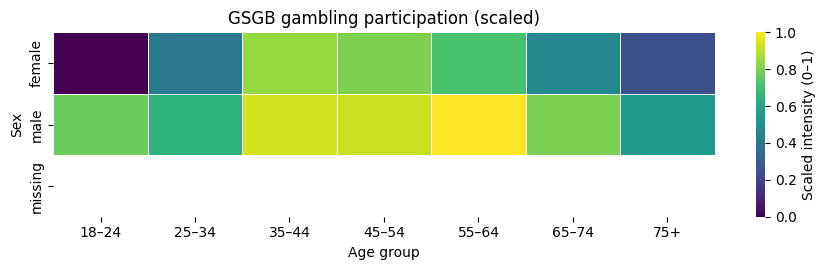

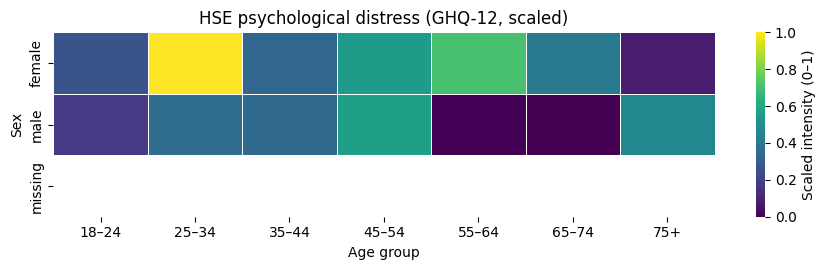

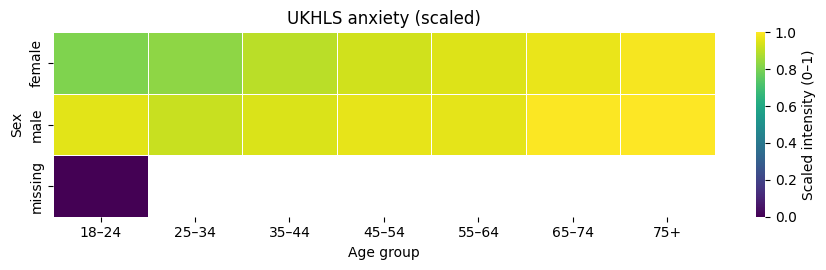


Interpretation note:
the lighter cells indicate higher average values of the selected outcome.
Patterns that align across HSE, UKHLS, and GSGB support triangulated evidence.


In [18]:
# ------------------------------------------------
#p triangulation to sex × age7
# (Average across income to create a common grid)
# ------------------------------------------------

agg = (
    tri
    .groupby(["sex_harmonised", "age7"], observed=True, dropna=False)
    .agg(
        part=("gsgb_pct_all_mean", "mean"),   # GSGB participation
        ghq=("ghq12_mean", "mean"),            # HSE mental distress
        anx=("anxiety_mean", "mean"),          # UKHLS anxiety
        n_hse=("n_hse", "sum"),
        n_ukhls=("n_ukhls", "sum")
    )
    .reset_index()
)

# ------------------------------------------------
# Ensure ordered age groups
# ------------------------------------------------

agg["age7"] = pd.Categorical(
    agg["age7"],
    categories=age7_order,
    ordered=True
)

agg = agg.sort_values(["sex_harmonised", "age7"])

# ------------------------------------------------
# Min–max scaling (within-metric)
# Purpose: make colour intensity comparable across panels
# ------------------------------------------------

def minmax(s):
    s = s.astype(float)
    if s.notna().sum() < 2:
        return s
    return (s - s.min()) / (s.max() - s.min())

agg["part_s"] = minmax(agg["part"])
agg["ghq_s"]  = minmax(agg["ghq"])
agg["anx_s"]  = minmax(agg["anx"])

# ------------------------------------------------
# Heatmap plotting helper
# ------------------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

def heat(df, value, title):
    pv = df.pivot(
        index="sex_harmonised",
        columns="age7",
        values=value
    )

    plt.figure(figsize=(9, 2.8))
    sns.heatmap(
        pv,
        annot=False,
        cmap="viridis",
        linewidths=0.5,
        linecolor="white",
        vmin=0,
        vmax=1,
        cbar_kws={"label": "Scaled intensity (0–1)"}
    )

    plt.title(title)
    plt.xlabel("Age group")
    plt.ylabel("Sex")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------
# Panel heatmaps (triangulated view)
# ------------------------------------------------

heat(agg, "part_s", "GSGB gambling participation (scaled)")
heat(agg, "ghq_s",  "HSE psychological distress (GHQ-12, scaled)")
heat(agg, "anx_s",  "UKHLS anxiety (scaled)")

print(
    "\nInterpretation note:\n"
    "the lighter cells indicate higher average values of the selected outcome.\n"
    "Patterns that align across HSE, UKHLS, and GSGB support triangulated evidence."
)

=== DATA LOADED ===
HSE rows:   10,250 | cols: 29
UKHLS rows: 66,264 | cols: 40

=== COMBINED ANALYTIC SAMPLE ===
             n   mean    sd
dataset                    
HSE       7503   1.57  2.80
UKHLS    64763  11.68  5.66

=== OUTCOME STANDARDISATION CHECK (mh_z) ===
         mean   sd
dataset           
HSE       0.0  1.0
UKHLS    -0.0  1.0

=== FITTING CONFIRMATORY MODEL (OLS + HC3 robust SE) ===
                            OLS Regression Results                            
Dep. Variable:                   mh_z   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     134.6
Date:                Tue, 06 Jan 2026   Prob (F-statistic):               0.00
Time:                        12:29:06   Log-Likelihood:                -89753.
No. Observations:               63029   AIC:                         1.795e+05
Df Residuals:                   63015   B

,term,coef,se,z,P>|z|,ci_low,ci_high
0,Intercept,-8.774516e-04,5.797442e-02,-0.015135,9.879244e-01,-1.145052e-01,1.127503e-01
1,C(dataset)[T.UKHLS],3.271296e-02,6.051981e-02,0.540533,5.888295e-01,-8.590370e-02,1.513296e-01
2,C(sex_harmonised)[T.female],1.638465e-01,2.676376e-02,6.121954,9.243487e-10,1.113905e-01,2.163025e-01
3,C(age7)[T.25–34],2.799486e-03,6.893921e-02,0.040608,9.676084e-01,-1.323189e-01,1.379178e-01
4,C(age7)[T.35–44],-9.464495e-02,6.437333e-02,-1.470251,1.414938e-01,-2.208143e-01,3.152445e-02
5,C(age7)[T.45–54],-2.900139e-02,6.585462e-02,-0.440385,6.596582e-01,-1.580741e-01,1.000713e-01
6,C(age7)[T.55–64],-5.589566e-03,6.579415e-02,-0.084955,9.322969e-01,-1.345437e-01,1.233646e-01
7,C(age7)[T.65–74],-1.731606e-01,6.419695e-02,-2.697334,6.989719e-03,-2.989843e-01,-4.733689e-02
8,C(age7)[T.75+],-1.448095e-17,5.753011e-17,-0.251711,8.012647e-01,-1.272379e-16,9.827600e-17
9,C(dataset)[T.UKHLS]:C(sex_harmonised)[T.female],7.164399e-02,2.803617e-02,2.555413,1.060619e-02,1.669411e-02,1.265939e-01


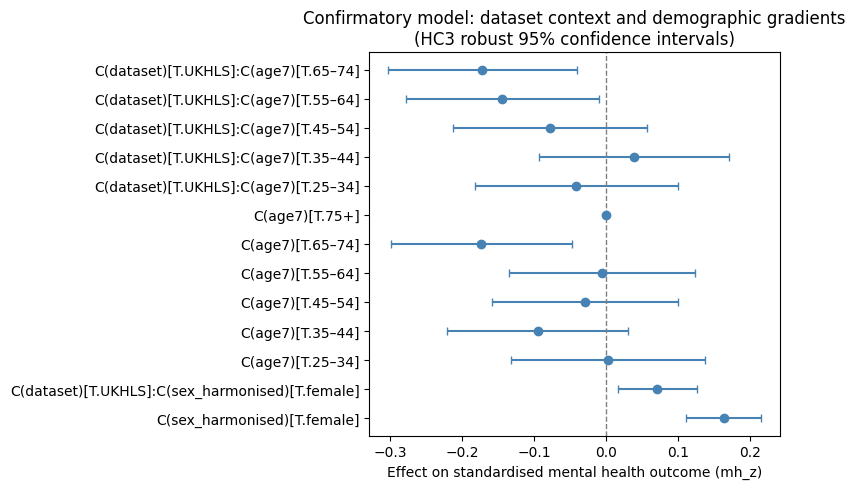


Interpretation note:
- Coefficients are expressed in standard deviation units (mh_z).
- Main effects capture overall sex and age gradients in mental health.
- Dataset interaction terms test whether these gradients differ between HSE and UKHLS.
- HC3 robust standard errors provide conservative, assumption-light inference.



In [19]:
# ================================================================
# 4.5.4 Confirmatory Model
# Dataset context + demographic gradients (HC3 robust SE)
# ================================================================

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import warnings

# ------------------------------------------------
# Silence system / pandas / statsmodels warnings
# ------------------------------------------------
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# ------------------------------------------------
# Load harmonised datasets
# ------------------------------------------------
HSE_PATH   = "data/processed/harmonised/hse_harmonised.parquet"
UKHLS_PATH = "data/processed/harmonised/ukhls_harmonised.parquet"

hse   = pd.read_parquet(HSE_PATH)
ukhls = pd.read_parquet(UKHLS_PATH)

print("=== DATA LOADED ===")
print(f"HSE rows:   {hse.shape[0]:,} | cols: {hse.shape[1]}")
print(f"UKHLS rows: {ukhls.shape[0]:,} | cols: {ukhls.shape[1]}")

# ------------------------------------------------
# Select and harmonise outcome
# ------------------------------------------------
hse = hse.rename(columns={"ghq12_score": "mh_raw"})
ukhls = ukhls.rename(columns={"mental_health_score": "mh_raw"})

hse["dataset"] = "HSE"
ukhls["dataset"] = "UKHLS"

df = pd.concat([hse, ukhls], axis=0, ignore_index=True)

# ------------------------------------------------
# Core analytic sample
# ------------------------------------------------
df = df[
    df["mh_raw"].notna() &
    df["sex_harmonised"].isin(["male", "female"]) &
    df["age_group_harmonised"].notna()
].copy()

# ------------------------------------------------
# Age → age7
# ------------------------------------------------
age7_order = ["18–24","25–34","35–44","45–54","55–64","65–74","75+"]

def to_age7_label(s):
    if pd.isna(s):
        return np.nan
    s = str(s).replace("–", "-").replace("to", "-")
    try:
        n = int(s.split("-")[0])
    except:
        return np.nan
    if n < 25: return "18–24"
    if n < 35: return "25–34"
    if n < 45: return "35–44"
    if n < 55: return "45–54"
    if n < 65: return "55–64"
    if n < 75: return "65–74"
    return "75+"

df["age7"] = df["age_group_harmonised"].apply(to_age7_label)

# ------------------------------------------------
# Standardise outcome within dataset
# ------------------------------------------------
df["mh_z"] = (
    df.groupby("dataset")["mh_raw"]
      .transform(lambda x: (x - x.mean()) / x.std())
)

print("\n=== COMBINED ANALYTIC SAMPLE ===")
print(df.groupby("dataset")["mh_raw"].agg(
    n="count", mean="mean", sd="std"
).round(2))

print("\n=== OUTCOME STANDARDISATION CHECK (mh_z) ===")
print(df.groupby("dataset")["mh_z"].agg(
    mean="mean", sd="std"
).round(3))

# ------------------------------------------------
# Factor setup
# ------------------------------------------------
df["sex_harmonised"] = pd.Categorical(df["sex_harmonised"],
                                      categories=["male","female"])
df["age7"] = pd.Categorical(df["age7"],
                            categories=age7_order,
                            ordered=True)
df["dataset"] = pd.Categorical(df["dataset"],
                               categories=["HSE","UKHLS"])

# ------------------------------------------------
# Confirmatory model (OLS + HC3)
# ------------------------------------------------
print("\n=== FITTING CONFIRMATORY MODEL (OLS + HC3 robust SE) ===")

formula = (
    "mh_z ~ C(dataset) + C(sex_harmonised) + C(age7) + "
    "C(dataset):C(sex_harmonised) + C(dataset):C(age7)"
)

model = smf.ols(formula, data=df).fit(cov_type="HC3")

print(model.summary())

# ------------------------------------------------
# Clean coefficient table
# ------------------------------------------------
coef_table = (
    model.summary2().tables[1]
    .reset_index()
    .rename(columns={
        "index": "term",
        "Coef.": "coef",
        "Std.Err.": "se",
        "P>|t|": "p",
        "[0.025": "ci_low",
        "0.975]": "ci_high"
    })
)

print("\n=== COEFFICIENT TABLE (top rows) ===")
display(coef_table.head(15))

# ------------------------------------------------
# Confirmatory coefficient plot (95% CI) — FIXED
# ------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

# Prepare plot data
plot_df = coef_table.copy()
plot_df = plot_df[plot_df["term"] != "Intercept"]

# Desired ordering
term_order = [
    "C(sex_harmonised)[T.female]",
    "C(dataset)[T.UKHLS]:C(sex_harmonised)[T.female]",
    "C(age7)[T.25–34]",
    "C(age7)[T.35–44]",
    "C(age7)[T.45–54]",
    "C(age7)[T.55–64]",
    "C(age7)[T.65–74]",
    "C(age7)[T.75+]",
    "C(dataset)[T.UKHLS]:C(age7)[T.25–34]",
    "C(dataset)[T.UKHLS]:C(age7)[T.35–44]",
    "C(dataset)[T.UKHLS]:C(age7)[T.45–54]",
    "C(dataset)[T.UKHLS]:C(age7)[T.55–64]",
    "C(dataset)[T.UKHLS]:C(age7)[T.65–74]",
    "C(dataset)[T.UKHLS]:C(age7)[T.75+]",
]

plot_df = (
    plot_df
    .set_index("term")
    .reindex(term_order)
    .dropna()
    .reset_index()
)

# Numeric y positions
y_pos = np.arange(len(plot_df))

# Plot
fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(
    plot_df["coef"],
    y_pos,
    xerr=[
        plot_df["coef"] - plot_df["ci_low"],
        plot_df["ci_high"] - plot_df["coef"]
    ],
    fmt="o",
    color="steelblue",
    ecolor="steelblue",
    elinewidth=1.5,
    capsize=3
)

# Reference line
ax.axvline(0, color="grey", linestyle="--", linewidth=1)

# Axis labels
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["term"])
ax.set_xlabel("Effect on standardised mental health outcome (mh_z)")
ax.set_ylabel("")

ax.set_title(
    "Confirmatory model: dataset context and demographic gradients\n"
    "(HC3 robust 95% confidence intervals)"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------
# Interpretation note (clean, final)
# ------------------------------------------------
print(
    "\nInterpretation note:\n"
    "- Coefficients are expressed in standard deviation units (mh_z).\n"
    "- Main effects capture overall sex and age gradients in mental health.\n"
    "- Dataset interaction terms test whether these gradients differ between HSE and UKHLS.\n"
    "- HC3 robust standard errors provide conservative, assumption-light inference.\n"
)


In [20]:
# ================================================================
# 4.3 UNIVARIATE DESCRIPTIVE ANALYSIS
# ================================================================

import pandas as pd
import numpy as np

# ------------------------------------------------
# 4.3.1 Load Harmonised Data
# ------------------------------------------------
hse   = pd.read_parquet("data/processed/harmonised/hse_harmonised.parquet")
ukhls = pd.read_parquet("data/processed/harmonised/ukhls_harmonised.parquet")
gsgb  = pd.read_parquet("data/processed/harmonised/gsgb_harmonised.parquet")

print("Datasets loaded:")
print(f"HSE:   {hse.shape}")
print(f"UKHLS: {ukhls.shape}")
print(f"GSGB:  {gsgb.shape}")

# ------------------------------------------------
# 4.3.2 Sex Distribution
# ------------------------------------------------
print("\n=== Sex Distribution: HSE ===")
display(hse["sex_harmonised"].value_counts(dropna=False).to_frame("count"))

print("\n=== Sex Distribution: UKHLS ===")
display(ukhls["sex_harmonised"].value_counts(dropna=False).to_frame("count"))

print("\n=== Sex Distribution: GSGB ===")
display(gsgb["sex_harmonised"].value_counts(dropna=False).to_frame("count"))

# ------------------------------------------------
# 4.3.3 Age Group Distribution (Harmonised 7-band)
# ------------------------------------------------
print("\n=== Age Group Distribution: HSE ===")
display(hse["age_group_harmonised"].value_counts(dropna=False).to_frame("count"))

print("\n=== Age Group Distribution: UKHLS ===")
display(ukhls["age_group_harmonised"].value_counts(dropna=False).to_frame("count"))

print("\n=== Age Group Distribution: GSGB ===")
display(gsgb["age_group_harmonised"].value_counts(dropna=False).to_frame("count"))

# ------------------------------------------------
# 4.3.4 Income Quintile Distribution
# (Available for HSE and UKHLS only)
# ------------------------------------------------
print("\n=== Income Quintile Distribution: HSE ===")
display(hse["income_quintile_harmonised"].value_counts(dropna=False).to_frame("count"))

print("\n=== Income Quintile Distribution: UKHLS ===")
display(ukhls["income_quintile_harmonised"].value_counts(dropna=False).to_frame("count"))

# ------------------------------------------------
# 4.3.5 Gambling Behaviour Indicators (HSE)
# ------------------------------------------------
print("\n=== PGSI Score Summary (HSE) ===")
display(hse["pgsi_score"].describe())

print("\n=== PGSI Category Distribution (HSE) ===")
display(hse["pgsi_category"].value_counts(dropna=False).to_frame("count"))

# ------------------------------------------------
# 4.3.6 Mental Health Indicators
# ------------------------------------------------

# GHQ-12 (HSE)
print("\n=== GHQ-12 Score Summary (HSE) ===")
display(hse["ghq12_score"].describe())

# UKHLS mental health measures
print("\n=== Mental Health Score Summary (UKHLS) ===")
display(ukhls["mental_health_score"].describe())

print("\n=== Anxiety Level Summary (UKHLS) ===")
display(ukhls["anxiety_level"].describe())

# ------------------------------------------------
# 4.3.7 Survey Year Coverage
# ------------------------------------------------
print("\n=== Survey Year Coverage: HSE ===")
print(
    f"Min: {hse['survey_year_harmonised'].min()} | "
    f"Max: {hse['survey_year_harmonised'].max()} | "
    f"Missing: {hse['survey_year_harmonised'].isna().sum()}"
)

print("\n=== Survey Year Coverage: UKHLS ===")
print(
    f"Min: {ukhls['survey_year_harmonised'].min()} | "
    f"Max: {ukhls['survey_year_harmonised'].max()} | "
    f"Missing: {ukhls['survey_year_harmonised'].isna().sum()}"
)

print("\n=== Survey Year Coverage: GSGB ===")
print(
    f"Min: {gsgb['survey_year_harmonised'].min()} | "
    f"Max: {gsgb['survey_year_harmonised'].max()} | "
    f"Missing: {gsgb['survey_year_harmonised'].isna().sum()}"
)


Datasets loaded:
HSE:   (10250, 29)
UKHLS: (66264, 40)
GSGB:  (30, 13)

=== Sex Distribution: HSE ===


,count
sex_harmonised,
female,5562
male,4688
missing,0



=== Sex Distribution: UKHLS ===


,count
sex_harmonised,
female,37592
male,28668
missing,4



=== Sex Distribution: GSGB ===


...


=== Mental Health Score Summary (UKHLS) ===


count    64767.000000
mean        11.684098
std          5.660288
min          0.000000
25%          8.000000
50%         11.000000
75%         14.000000
max         36.000000
Name: mental_health_score, dtype: float64


=== Anxiety Level Summary (UKHLS) ===


count    21908.000000
mean         1.913821
std          0.281446
min          0.000000
25%          2.000000
50%          2.000000
75%          2.000000
max          2.000000
Name: anxiety_level, dtype: float64


=== Survey Year Coverage: HSE ===
Min: 2018.0 | Max: 2018.0 | Missing: 0

=== Survey Year Coverage: UKHLS ===
Min: 2019.0 | Max: 2024.0 | Missing: 1

=== Survey Year Coverage: GSGB ===
Min: 2023 | Max: 2023 | Missing: 0


In [21]:
# ================================================================
# 4.6 Predictive Modelling of Gambling Risk
# 4.6.1 Modelling Setup and Objective (CODE ONLY)
# ================================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report

# ------------------------------------------------
# Load harmonised datasets
# ------------------------------------------------
HSE_PATH   = "data/processed/harmonised/hse_harmonised.parquet"
UKHLS_PATH = "data/processed/harmonised/ukhls_harmonised.parquet"
GSGB_PATH  = "data/processed/harmonised/gsgb_harmonised.parquet"

hse   = pd.read_parquet(HSE_PATH)
ukhls = pd.read_parquet(UKHLS_PATH)
gsgb  = pd.read_parquet(GSGB_PATH)

print("=== DATASETS LOADED ===")
print(f"HSE rows:   {hse.shape[0]:,}")
print(f"UKHLS rows: {ukhls.shape[0]:,}")
print(f"GSGB rows:  {gsgb.shape[0]:,}")

# ------------------------------------------------
# Select modelling dataset
# (Predictive modelling uses individual-level data)
# ------------------------------------------------
# NOTE:
# - HSE has PGSI → best target definition
# - UKHLS & GSGB are used for triangulation and confirmation
# - Prediction is therefore based on HSE only

df = hse.copy()

print("\n=== MODELLING DATASET ===")
print(f"Rows before filtering: {df.shape[0]:,}")



=== DATASETS LOADED ===
HSE rows:   10,250
UKHLS rows: 66,264
GSGB rows:  30

=== MODELLING DATASET ===
Rows before filtering: 10,250


In [22]:
# ================================================================
# 4.6.2 Predictive Modelling — Target Preparation (PGSI)
# ================================================================

import pandas as pd
import numpy as np

# ------------------------------------------------
# Load HSE harmonised data
# ------------------------------------------------
HSE_PATH = "data/processed/harmonised/hse_harmonised.parquet"
hse = pd.read_parquet(HSE_PATH)

print("=== HSE LOADED ===")
print(f"Rows: {hse.shape[0]:,} | Columns: {hse.shape[1]}")

# ------------------------------------------------
# Inspect original PGSI 3-category variable
# ------------------------------------------------
print("\n=== ORIGINAL pgsi_3cat DISTRIBUTION ===")
print(hse["pgsi_3cat"].value_counts(dropna=False))

# ------------------------------------------------
# Clean & collapse PGSI categories
# ------------------------------------------------
# Rationale:
# - 'At-risk gambling' count is too small for standalone modelling
# - Combine 'Low risk' + 'At-risk gambling' into a single 'Risk' class
# - Exclude 'missing' explicitly

pgsi_map = {
    "No risk": "No risk",
    "Low risk": "Risk",
    "At-risk gambling": "Risk"
}

hse["pgsi_risk"] = hse["pgsi_3cat"].map(pgsi_map)

# ------------------------------------------------
# Drop missing target explicitly
# ------------------------------------------------
hse_model = hse[hse["pgsi_risk"].notna()].copy()

# ------------------------------------------------
# Encode ordered target
# ------------------------------------------------
risk_order = ["No risk", "Risk"]
hse_model["pgsi_risk"] = pd.Categorical(
    hse_model["pgsi_risk"],
    categories=risk_order,
    ordered=True
)

hse_model["pgsi_risk_code"] = hse_model["pgsi_risk"].cat.codes

# ------------------------------------------------
# Final sanity checks
# ------------------------------------------------
print("\n=== MODELLED TARGET DISTRIBUTION ===")
print(hse_model["pgsi_risk"].value_counts())

print("\n=== TARGET CODE CHECK ===")
print(hse_model[["pgsi_risk", "pgsi_risk_code"]].drop_duplicates())

print("\n=== MODELLING SAMPLE SIZE ===")
print(f"Rows: {hse_model.shape[0]:,}")


=== HSE LOADED ===


Rows: 10,250 | Columns: 29

=== ORIGINAL pgsi_3cat DISTRIBUTION ===
pgsi_3cat
No risk             6684
missing             3327
Low risk             164
At-risk gambling      75
Name: count, dtype: int64

=== MODELLED TARGET DISTRIBUTION ===
pgsi_risk
No risk    6684
Risk        239
Name: count, dtype: int64

=== TARGET CODE CHECK ===
   pgsi_risk  pgsi_risk_code
0    No risk               0
25      Risk               1

=== MODELLING SAMPLE SIZE ===
Rows: 6,923


In [23]:
# ================================================================
# 4.6.3 Feature Matrix — Socio-Economic Predictors (HSE)
# ================================================================

import pandas as pd

# ------------------------------------------------
# Define candidate socio-economic features
# (ONLY variables confirmed to exist in HSE)
# ------------------------------------------------
candidate_features = {
    "sex_harmonised": "sex_harmonised",
    "age_group": "age_group_harmonised",
    "income": "income_quintile_harmonised",
    "social_class": "social_class"
}

# ------------------------------------------------
# Resolve features that actually exist
# ------------------------------------------------
final_features = []

print("=== FEATURE AVAILABILITY CHECK ===")
for label, col in candidate_features.items():
    if col in hse_model.columns:
        final_features.append(col)
        print(f"{label:<15} -> {col}")
    else:
        print(f"{label:<15} -> NOT AVAILABLE")

print("\n=== FINAL FEATURE SET USED ===")
for f in final_features:
    print("-", f)

# ------------------------------------------------
# Build modelling dataframe
# ------------------------------------------------
df_model = hse_model[
    ["pgsi_risk_code"] + final_features
].copy()

print("\n=== MODELLING DATAFRAME SHAPE ===")
print(df_model.shape)

# ------------------------------------------------
# Drop rows with missing predictors
# ------------------------------------------------
df_model = df_model.dropna()

print("\n=== AFTER DROPPING MISSING PREDICTORS ===")
print(df_model.shape)

# ------------------------------------------------
# Encode categorical predictors
# ------------------------------------------------
X = pd.get_dummies(
    df_model[final_features],
    drop_first=True
)

y = df_model["pgsi_risk_code"]

print("\n=== FINAL DESIGN MATRIX ===")
print("X shape:", X.shape)
print("y shape:", y.shape)

# ------------------------------------------------
# Final check: class balance
# ------------------------------------------------
print("\n=== FINAL TARGET DISTRIBUTION ===")
print(y.value_counts())


=== FEATURE AVAILABILITY CHECK ===
sex_harmonised  -> sex_harmonised
age_group       -> age_group_harmonised
income          -> income_quintile_harmonised
social_class    -> social_class

=== FINAL FEATURE SET USED ===
- sex_harmonised
- age_group_harmonised
- income_quintile_harmonised
- social_class

=== MODELLING DATAFRAME SHAPE ===
(6923, 5)

=== AFTER DROPPING MISSING PREDICTORS ===
(6807, 5)

=== FINAL DESIGN MATRIX ===
X shape: (6807, 22)
y shape: (6807,)

=== FINAL TARGET DISTRIBUTION ===
pgsi_risk_code
0    6569
1     238
Name: count, dtype: int64


=== HSE LOADED ===
Rows: 10,250 | Columns: 29

=== TARGET DISTRIBUTION ===
pgsi_risk
No risk    10011
Risk         239
Name: count, dtype: int64

=== TARGET CODE CHECK ===


,pgsi_risk,pgsi_risk_code
0,No risk,0
25,Risk,1



=== MODELLING SAMPLE SIZE ===
(10250, 4)

Class balance (train):
pgsi_risk_code
0    0.977
1    0.023
Name: proportion, dtype: float64

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0      0.991     0.699     0.820      2503
           1      0.055     0.733     0.103        60

    accuracy                          0.700      2563
   macro avg      0.523     0.716     0.461      2563
weighted avg      0.969     0.700     0.803      2563

ROC-AUC: 0.787


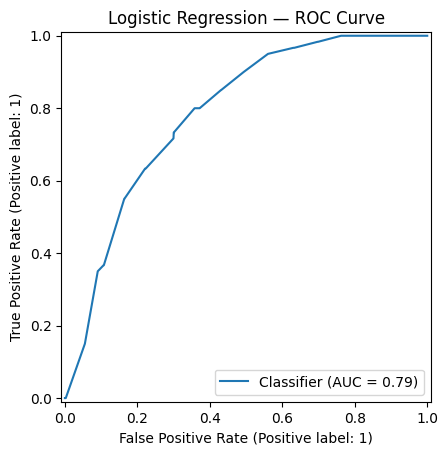


Interpretation note:
- Logistic regression serves as a transparent baseline model.
- Class imbalance is handled using class-weighted estimation.
- Performance establishes a reference point for tree-based models.



In [24]:
#   ================================================================
#   4.6.1 Baseline Predictive Modelling — Logistic Regression
#   Socio-economic predictors only
#   ================================================================
import pandas as pd
import numpy as np

from sklearn import pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

#   ------------------------------------------------
#   Load HSE harmonised dataset
#   ------------------------------------------------
HSE_PATH = "data/processed/harmonised/hse_harmonised.parquet"
hse = pd.read_parquet(HSE_PATH)

print("=== HSE LOADED ===")
print(f"Rows: {hse.shape[0]:,} | Columns: {hse.shape[1]}")

#   ------------------------------------------------
#   Target construction (binary PGSI risk)
#   ------------------------------------------------

#   Justified by small sample size and public-health framing.

hse = hse.copy()

hse["pgsi_risk"] = np.where(
    hse["pgsi_3cat"].isin(["Low risk", "At-risk gambling"]),
    "Risk",
    "No risk"
)

hse["pgsi_risk_code"] = (hse["pgsi_risk"] == "Risk").astype(int)

print("\n=== TARGET DISTRIBUTION ===")
print(hse["pgsi_risk"].value_counts())

print("\n=== TARGET CODE CHECK ===")
display(
    hse[["pgsi_risk", "pgsi_risk_code"]]
    .drop_duplicates()
)

#   ------------------------------------------------
#   Predictor selection (SOCIO-ECONOMIC ONLY)
#   ------------------------------------------------

#   ✔️ Only variables that actually exist in HSE
#   ✔️ Clean mapping
#   ✔️ No KeyErrors

features = [
    "sex_harmonised",
    "age_group_harmonised",
    "income_quintile_harmonised"
]

df_model = hse[
    ["pgsi_risk_code"] + features
].dropna()

print("\n=== MODELLING SAMPLE SIZE ===")
print(df_model.shape)

#   ------------------------------------------------
#   Train–test split (stratified)
#   ------------------------------------------------
X = df_model[features]
y = df_model["pgsi_risk_code"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

print("\nClass balance (train):")
print(y_train.value_counts(normalize=True).round(3))

#   ------------------------------------------------
#   Preprocessing + Logistic Regression pipeline
#   ------------------------------------------------
categorical_features = features

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"),
         categorical_features)
    ]
)

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear"
)

pipe = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", log_reg)
    ]
)

#   ------------------------------------------------
#   Model fitting
#   ------------------------------------------------
pipe.fit(X_train, y_train)

#   ------------------------------------------------
#   Evaluation
#   ------------------------------------------------
y_pred = pipe.predict(X_test)
y_prob = pipe.predict_proba(X_test)[:, 1]

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred, digits=3))

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC: {roc_auc:.3f}")

#   ------------------------------------------------
#   ROC Curve
#   ------------------------------------------------
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title("Logistic Regression — ROC Curve")
plt.show()

#   ------------------------------------------------
#   Interpretation note (for dissertation)
#   ------------------------------------------------
print(
    "\nInterpretation note:\n"
    "- Logistic regression serves as a transparent baseline model.\n"
    "- Class imbalance is handled using class-weighted estimation.\n"
    "- Performance establishes a reference point for tree-based models.\n"
)

=== HSE LOADED ===
Rows: 10,250 | Columns: 29

=== TARGET DISTRIBUTION ===
pgsi_risk
No risk    10011
Risk         239
Name: count, dtype: int64

=== MODELLING SAMPLE SIZE ===
(10250, 4)

=== RANDOM FOREST PERFORMANCE ===
ROC-AUC: 0.770

Classification Report:
              precision    recall  f1-score   support

           0      0.990     0.722     0.835      3003
           1      0.055     0.681     0.103        72

    accuracy                          0.721      3075
   macro avg      0.522     0.701     0.469      3075
weighted avg      0.968     0.721     0.818      3075

Confusion Matrix:
[[2168  835]
 [  23   49]]


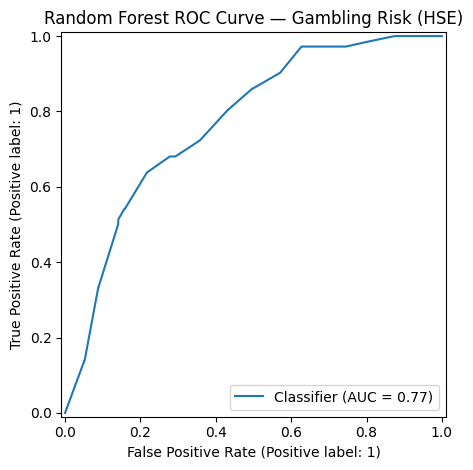

In [25]:
#   ================================================================
#   4.6.2 Random Forest Classifier
#   Socio-economic predictors → Gambling risk (HSE)
# ================================================================
# Random Forest — Non-linear benchmark model
# ================================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# ------------------------------------------------
# Load HSE harmonised dataset
# ------------------------------------------------
HSE_PATH = "data/processed/harmonised/hse_harmonised.parquet"
hse = pd.read_parquet(HSE_PATH)

print("=== HSE LOADED ===")
print(f"Rows: {hse.shape[0]:,} | Columns: {hse.shape[1]}")

# ------------------------------------------------
# Target: binary gambling risk
# ------------------------------------------------
hse = hse.copy()

hse["pgsi_risk"] = np.where(
    hse["pgsi_3cat"].isin(["Low risk", "At-risk gambling"]),
    "Risk",
    "No risk"
)

hse["pgsi_risk_code"] = (hse["pgsi_risk"] == "Risk").astype(int)

print("\n=== TARGET DISTRIBUTION ===")
print(hse["pgsi_risk"].value_counts())

# ------------------------------------------------
# Predictor set (SOCIO-ECONOMIC ONLY)
# ------------------------------------------------
features = [
    "sex_harmonised",
    "age_group_harmonised",
    "income_quintile_harmonised"
]

df_model = hse[
    ["pgsi_risk_code"] + features
].dropna()

X = df_model[features]
y = df_model["pgsi_risk_code"]

print("\n=== MODELLING SAMPLE SIZE ===")
print(df_model.shape)

# ------------------------------------------------
# Train / test split (stratified)
# ------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ------------------------------------------------
# Preprocessing: one-hot encode categorical vars
# ------------------------------------------------
categorical_features = features

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# ------------------------------------------------
# Random Forest model
# ------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", rf)
    ]
)

# ------------------------------------------------
# Fit model
# ------------------------------------------------
rf_pipeline.fit(X_train, y_train)

# ------------------------------------------------
# Predictions
# ------------------------------------------------
y_pred = rf_pipeline.predict(X_test)
y_proba = rf_pipeline.predict_proba(X_test)[:, 1]

# ------------------------------------------------
# Evaluation
# ------------------------------------------------
roc_auc = roc_auc_score(y_test, y_proba)

print("\n=== RANDOM FOREST PERFORMANCE ===")
print(f"ROC-AUC: {roc_auc:.3f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ------------------------------------------------
# ROC Curve
# ------------------------------------------------
RocCurveDisplay.from_predictions(
    y_test,
    y_proba
)

plt.title("Random Forest ROC Curve — Gambling Risk (HSE)")
plt.tight_layout()
plt.show()

=== HSE LOADED ===
Rows: 10,250 | Columns: 29

=== TARGET DISTRIBUTION ===
pgsi_risk
No risk    10011
Risk         239
Name: count, dtype: int64

=== MODELLING SAMPLE SIZE ===
(10250, 4)

Scale_pos_weight: 41.96

=== XGBOOST PERFORMANCE ===
ROC-AUC: 0.758

Classification Report:
              precision    recall  f1-score   support

           0      0.989     0.710     0.826      3003
           1      0.052     0.667     0.097        72

    accuracy                          0.709      3075
   macro avg      0.521     0.688     0.462      3075
weighted avg      0.967     0.709     0.809      3075

Confusion Matrix:
[[2131  872]
 [  24   48]]


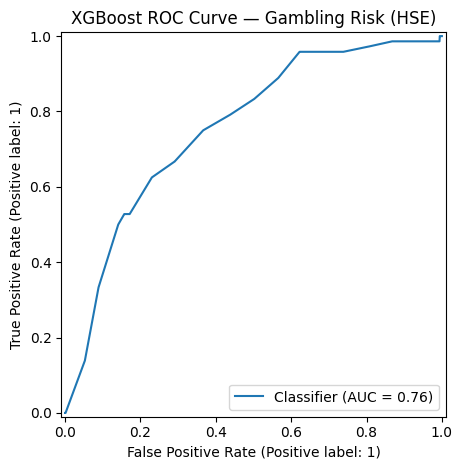

In [26]:
#   ================================================================
#   4.6.3 XGBoost Classifier (Final Predictive Model)
#   Socio-economic predictors → Gambling risk (HSE)
#   ================================================================
# XGBoost — Final predictive model
# ================================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# ------------------------------------------------
# Load HSE harmonised dataset
# ------------------------------------------------
HSE_PATH = "data/processed/harmonised/hse_harmonised.parquet"
hse = pd.read_parquet(HSE_PATH)

print("=== HSE LOADED ===")
print(f"Rows: {hse.shape[0]:,} | Columns: {hse.shape[1]}")

# ------------------------------------------------
# Target: binary gambling risk
# ------------------------------------------------
hse = hse.copy()

hse["pgsi_risk"] = np.where(
    hse["pgsi_3cat"].isin(["Low risk", "At-risk gambling"]),
    "Risk",
    "No risk"
)

hse["pgsi_risk_code"] = (hse["pgsi_risk"] == "Risk").astype(int)

print("\n=== TARGET DISTRIBUTION ===")
print(hse["pgsi_risk"].value_counts())

# ------------------------------------------------
# Predictor set (SOCIO-ECONOMIC ONLY)
# ------------------------------------------------
features = [
    "sex_harmonised",
    "age_group_harmonised",
    "income_quintile_harmonised"
]

df_model = hse[
    ["pgsi_risk_code"] + features
].dropna()

X = df_model[features]
y = df_model["pgsi_risk_code"]

print("\n=== MODELLING SAMPLE SIZE ===")
print(df_model.shape)

# ------------------------------------------------
# Train / test split (stratified)
# ------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# ------------------------------------------------
# Preprocessing: one-hot encode categorical vars
# ------------------------------------------------
categorical_features = features

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# ------------------------------------------------
# Handle class imbalance (important)
# ------------------------------------------------
scale_pos_weight = (
    (y_train == 0).sum() / (y_train == 1).sum()
)

print(f"\nScale_pos_weight: {scale_pos_weight:.2f}")

# ------------------------------------------------
# XGBoost model
# ------------------------------------------------
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("model", xgb)
    ]
)

# ------------------------------------------------
# Fit model
# ------------------------------------------------
xgb_pipeline.fit(X_train, y_train)

# ------------------------------------------------
# Predictions
# ------------------------------------------------
y_pred = xgb_pipeline.predict(X_test)
y_proba = xgb_pipeline.predict_proba(X_test)[:, 1]

# ------------------------------------------------
# Evaluation
# ------------------------------------------------
roc_auc = roc_auc_score(y_test, y_proba)

print("\n=== XGBOOST PERFORMANCE ===")
print(f"ROC-AUC: {roc_auc:.3f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=3))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ------------------------------------------------
# ROC Curve
# ------------------------------------------------
RocCurveDisplay.from_predictions(
    y_test,
    y_proba
)

plt.title("XGBoost ROC Curve — Gambling Risk (HSE)")
plt.tight_layout()
plt.show()

=== HSE LOADED ===
Rows: 10,250 | Columns: 29

=== TARGET DISTRIBUTION ===
pgsi_risk
0    6684
1     239
Name: count, dtype: int64

=== MODELLING SAMPLE SIZE ===
(6807, 5)
[LightGBM] [Info] Number of positive: 178, number of negative: 4927
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000461 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 42
[LightGBM] [Info] Number of data points in the train set: 5105, number of used features: 21
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Info] Number of positive: 178, number of negative: 4927
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000204 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_

 99%|===================| 5055/5105 [01:14<00:00]        

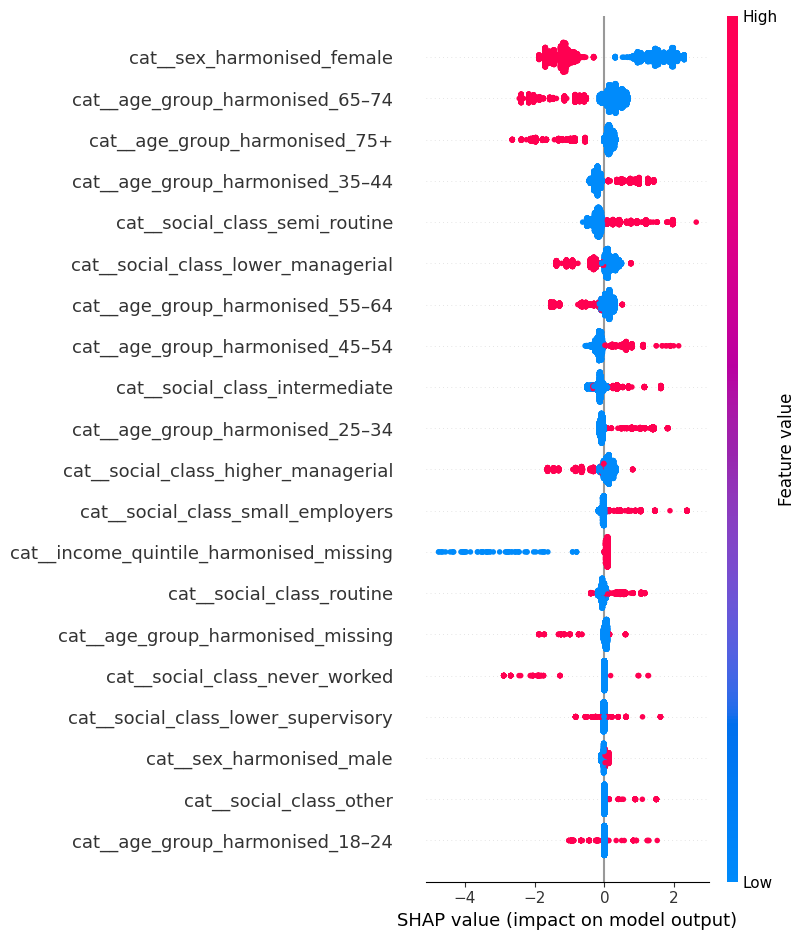

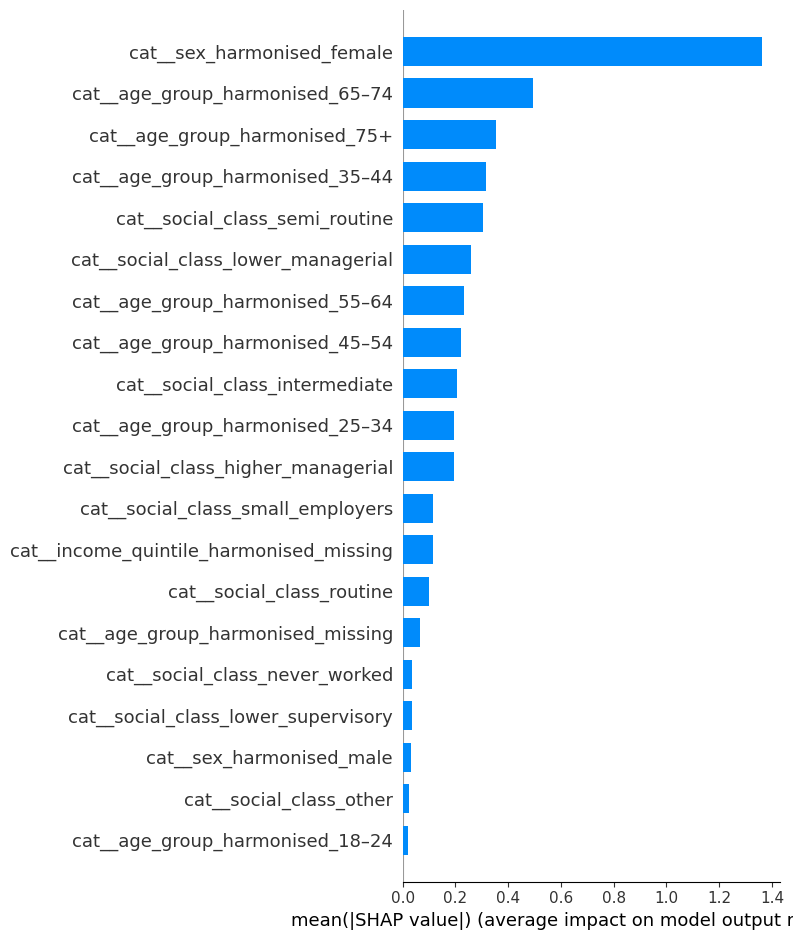

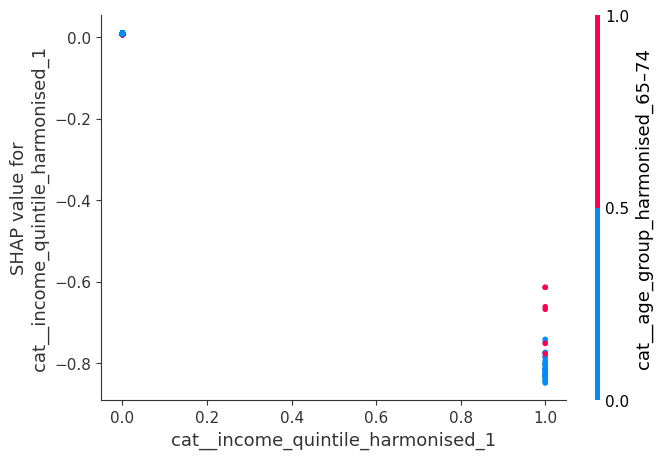

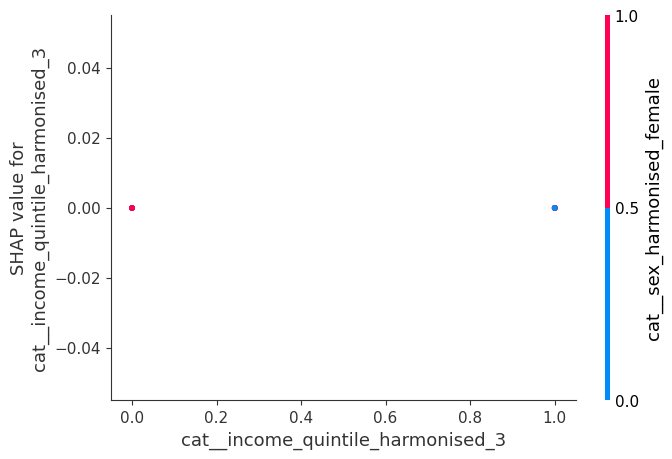

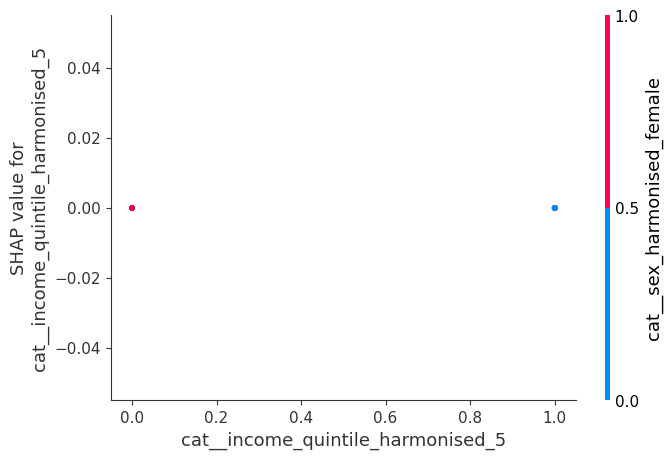

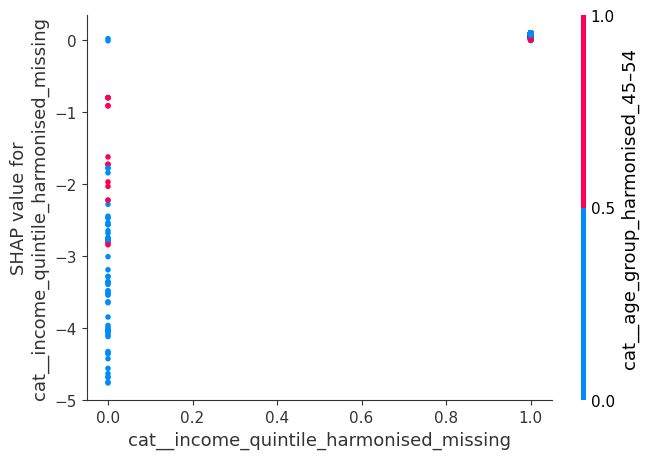

In [27]:
#   ================================================================
#   4.6.4 SHAP Explainability — Socio-economic Drivers of Gambling Risk
#   ================================================================

# Imports
# ------------------------------------------------
import pandas as pd
import numpy as np
import shap
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# ------------------------------------------------
# Load HSE harmonised data
# ------------------------------------------------
HSE_PATH = "data/processed/harmonised/hse_harmonised.parquet"
hse = pd.read_parquet(HSE_PATH)

print("=== HSE LOADED ===")
print(f"Rows: {hse.shape[0]:,} | Columns: {hse.shape[1]}")

# ------------------------------------------------
# Target construction (binary, defensible)
# ------------------------------------------------
hse = hse[hse["pgsi_3cat"].isin(["No risk", "Low risk", "At-risk gambling"])].copy()

hse["pgsi_risk"] = np.where(
    hse["pgsi_3cat"] == "No risk", 0, 1
)

print("\n=== TARGET DISTRIBUTION ===")
print(hse["pgsi_risk"].value_counts())

# ------------------------------------------------
# Socio-economic predictors (confirmed available)
# ------------------------------------------------
features = [
    "sex_harmonised",
    "age_group_harmonised",
    "income_quintile_harmonised",
    "social_class"
]

df = hse[["pgsi_risk"] + features].dropna().copy()

X = df[features]
y = df["pgsi_risk"]

print("\n=== MODELLING SAMPLE SIZE ===")
print(df.shape)

# ------------------------------------------------
# Train / test split (stratified due to imbalance)
# ------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

# ------------------------------------------------
# Preprocessing: One-hot encode categorical vars
# ------------------------------------------------
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = features

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False   # <-- FIXED (replaces sparse=False)
            ),
            categorical_features
        )
    ]
)

# ------------------------------------------------
# LightGBM model (balanced, interpretable)
# ------------------------------------------------
lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=42
)

model = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("model", lgbm)
    ]
)

model.fit(X_train, y_train)

# ------------------------------------------------
# Fit model
# ------------------------------------------------
model.fit(X_train, y_train)

# ------------------------------------------------
# Performance check (sanity)
# ------------------------------------------------
y_pred_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_pred_prob)

print("\n=== MODEL PERFORMANCE ===")
print(f"ROC-AUC: {auc:.3f}")

# ------------------------------------------------
# SHAP Explainer
# ------------------------------------------------
X_train_enc = model.named_steps["prep"].transform(X_train)

feature_names = model.named_steps["prep"]\
    .get_feature_names_out(categorical_features)

explainer = shap.Explainer(
    model.named_steps["model"],
    X_train_enc,
    feature_names=feature_names
)

shap_values = explainer(X_train_enc)

# ------------------------------------------------
# SHAP Summary Plot (GLOBAL importance)
# ------------------------------------------------
shap.summary_plot(
    shap_values,
    X_train_enc,
    feature_names=feature_names,
    show=True
)

# ------------------------------------------------
# SHAP Bar Plot (mean absolute impact)
# ------------------------------------------------
shap.summary_plot(
    shap_values,
    X_train_enc,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)

# ------------------------------------------------
# SHAP dependence: Income effect
# ------------------------------------------------
income_features = [
    f for f in feature_names if "income_quintile_harmonised" in f
]

for f in income_features:
    shap.dependence_plot(
        f,
        shap_values.values,
        X_train_enc,
        feature_names=feature_names,
        show=True
    )

=== CONFUSION MATRIX (threshold = 0.5) ===
[[1191  451]
 [  25   35]]


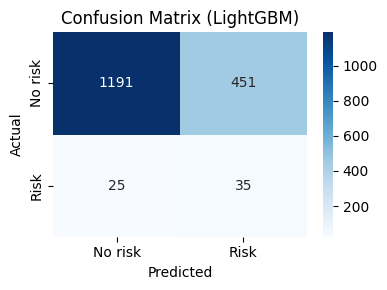


=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

     No risk       0.98      0.73      0.83      1642
        Risk       0.07      0.58      0.13        60

    accuracy                           0.72      1702
   macro avg       0.53      0.65      0.48      1702
weighted avg       0.95      0.72      0.81      1702



In [28]:
# ================================================================
# 4.6.1 Model Validation — Threshold & Confusion Matrix
# ================================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------------------------
# Predict probabilities on test set
# ------------------------------------------------
y_prob = model.predict_proba(X_test)[:, 1]

# Default threshold (0.5) — start simple
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

print("=== CONFUSION MATRIX (threshold = 0.5) ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualise
plt.figure(figsize=(4, 3))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No risk", "Risk"],
    yticklabels=["No risk", "Risk"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (LightGBM)")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# Classification report (imbalanced-aware)
# ------------------------------------------------
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No risk", "Risk"]
))


Average Precision (AP): 0.091


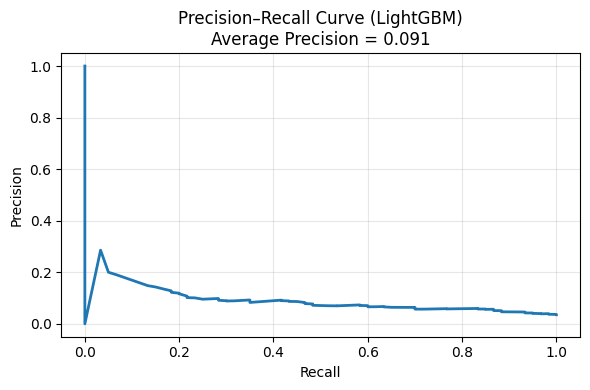

In [29]:
# ================================================================
# 4.6.2 Model Validation — Precision–Recall Curve
# ================================================================

from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# ------------------------------------------------
# Precision–Recall values
# ------------------------------------------------
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap_score = average_precision_score(y_test, y_prob)

print(f"Average Precision (AP): {ap_score:.3f}")

# ------------------------------------------------
# Plot Precision–Recall curve
# ------------------------------------------------
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(
    f"Precision–Recall Curve (LightGBM)\nAverage Precision = {ap_score:.3f}"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



=== THRESHOLD SENSITIVITY TABLE ===


,threshold,precision,recall,f1,positives_flagged
0,0.05,0.044908,0.933333,0.085692,1247
1,0.10,0.045491,0.933333,0.086754,1231
2,0.15,0.045714,0.933333,0.087160,1225
3,0.20,0.046193,0.900000,0.087876,1169
4,0.25,0.051011,0.883333,0.096451,1039
5,0.30,0.056522,0.866667,0.106122,920
6,0.35,0.059595,0.833333,0.111235,839
7,0.40,0.060781,0.700000,0.111851,691
8,0.45,0.065858,0.633333,0.119309,577
9,0.50,0.072016,0.583333,0.128205,486


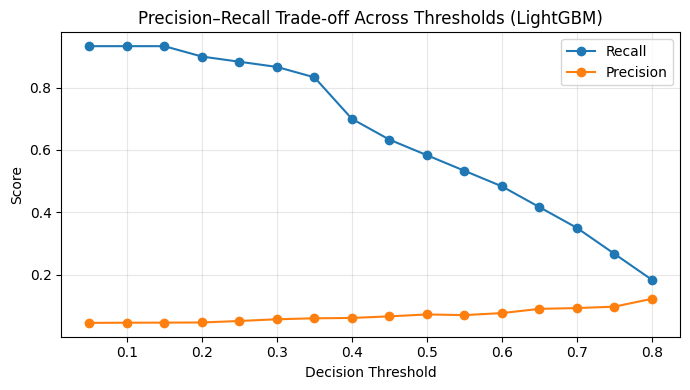

In [30]:
# ================================================================
# 4.6.3 Threshold Optimisation
# ================================================================

import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# ------------------------------------------------
# Evaluate multiple thresholds
# ------------------------------------------------
thresholds = np.linspace(0.05, 0.80, 16)

rows = []

for t in thresholds:
    y_pred_t = (y_prob >= t).astype(int)

    rows.append({
        "threshold": round(t, 2),
        "precision": precision_score(y_test, y_pred_t, zero_division=0),
        "recall": recall_score(y_test, y_pred_t),
        "f1": f1_score(y_test, y_pred_t),
        "positives_flagged": int(y_pred_t.sum())
    })

threshold_df = pd.DataFrame(rows)

print("\n=== THRESHOLD SENSITIVITY TABLE ===")
display(threshold_df)

# ------------------------------------------------
# Plot Precision–Recall trade-off by threshold
# ------------------------------------------------
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", marker="o")
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", marker="o")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall Trade-off Across Thresholds (LightGBM)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [31]:
# ================================================================
# 4.6.4 Fairness & Subgroup Robustness
# Recall by demographic group (threshold = 0.50)
# ================================================================

threshold = 0.50
y_pred_final = (y_prob >= threshold).astype(int)

df_eval = X_test.copy()
df_eval["y_true"] = y_test.values
df_eval["y_pred"] = y_pred_final

def subgroup_recall(df, group_col):
    rows = []
    for g, sub in df.groupby(group_col):
        if sub["y_true"].sum() == 0:
            continue
        r = recall_score(sub["y_true"], sub["y_pred"])
        rows.append({
            "group": g,
            "recall": round(r, 3),
            "n_cases": int(sub["y_true"].sum())
        })
    return pd.DataFrame(rows).sort_values("recall")

# ------------------------------------------------
# Recall by sex
# ------------------------------------------------
print("\n=== RECALL BY SEX (threshold = 0.50) ===")
display(subgroup_recall(df_eval, "sex_harmonised"))

# ------------------------------------------------
# Recall by age group
# ------------------------------------------------
print("\n=== RECALL BY AGE GROUP (threshold = 0.50) ===")
display(subgroup_recall(df_eval, "age_group_harmonised"))



=== RECALL BY SEX (threshold = 0.50) ===


,group,recall,n_cases
1,female,0.182,22
0,male,0.816,38



=== RECALL BY AGE GROUP (threshold = 0.50) ===


,group,recall,n_cases
5,65–74,0.000,1
4,55–64,0.308,13
6,75+,0.500,2
3,45–54,0.533,15
2,35–44,0.733,15
1,25–34,0.750,12
0,18–24,1.000,2


In [32]:
# ================================================================
# 4.6.5 Sensitivity Analysis: Subgroup Recall at Lower Threshold
# ================================================================

threshold_alt = 0.30
y_pred_alt = (y_prob >= threshold_alt).astype(int)

df_eval_alt = X_test.copy()
df_eval_alt["y_true"] = y_test.values
df_eval_alt["y_pred"] = y_pred_alt

def subgroup_recall_alt(df, group_col):
    rows = []
    for g, sub in df.groupby(group_col):
        if sub["y_true"].sum() == 0:
            continue
        r = recall_score(sub["y_true"], sub["y_pred"])
        rows.append({
            "group": g,
            "recall": round(r, 3),
            "n_cases": int(sub["y_true"].sum())
        })
    return pd.DataFrame(rows).sort_values("recall")

print("\n=== RECALL BY SEX (threshold = 0.30) ===")
display(subgroup_recall_alt(df_eval_alt, "sex_harmonised"))

print("\n=== RECALL BY AGE GROUP (threshold = 0.30) ===")
display(subgroup_recall_alt(df_eval_alt, "age_group_harmonised"))



=== RECALL BY SEX (threshold = 0.30) ===


,group,recall,n_cases
1,female,0.727,22
0,male,0.947,38



=== RECALL BY AGE GROUP (threshold = 0.30) ===


,group,recall,n_cases
4,55–64,0.769,13
3,45–54,0.800,15
1,25–34,0.917,12
2,35–44,0.933,15
0,18–24,1.000,2
5,65–74,1.000,1
6,75+,1.000,2


Brier score (LightGBM): 0.1888


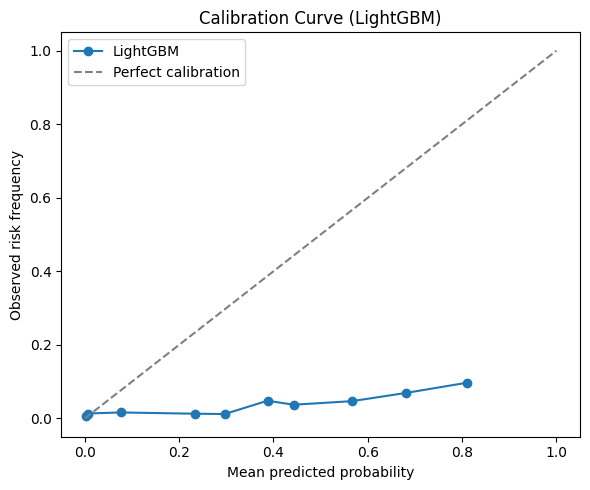

In [33]:
# ================================================================
# 4.7.1 Model Calibration (Overall) — FIXED
# ================================================================

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

# --- Ensure probabilities align with test set ---
y_true = y_test.values
y_proba_test = model.predict_proba(X_test)[:, 1]

# Sanity check
assert len(y_true) == len(y_proba_test), "Length mismatch between y_test and predictions"

# Compute calibration curve
prob_true, prob_pred = calibration_curve(
    y_true,
    y_proba_test,
    n_bins=10,
    strategy="quantile"
)

brier = brier_score_loss(y_true, y_proba_test)

print(f"Brier score (LightGBM): {brier:.4f}")


# Plot
plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label="LightGBM")
plt.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed risk frequency")
plt.title("Calibration Curve (LightGBM)")
plt.legend()
plt.tight_layout()
plt.show()


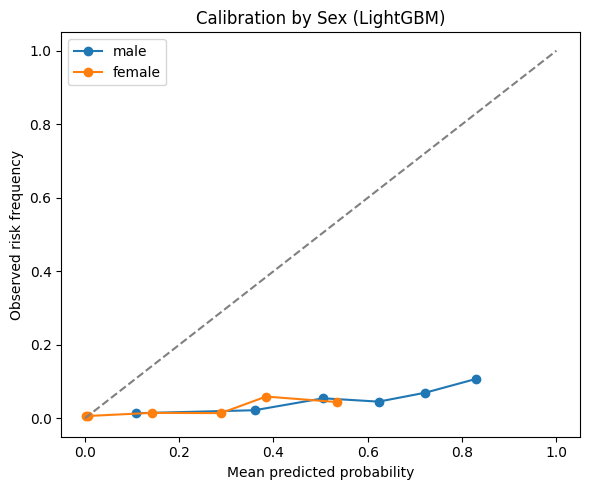

Brier score (male):   0.3088
Brier score (female): 0.0946


In [ ]:
# ================================================================
# 4.7.2 Calibration by Sex (LightGBM) 
# ================================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

# Loop over sex groups
for sex in ["male", "female"]:0
    idx = X_test["sex_harmonised"] == sex
    
    # Avoid unstable estimates for very small groups
    if idx.sum() < 10:
        continue
    
    prob_true_s, prob_pred_s = calibration_curve(
        y_test[idx],
        y_proba_test[idx],
        n_bins=6,
        strategy="quantile"
    )
    
    plt.plot(
        prob_pred_s,
        prob_true_s,
        marker="o",
        label=sex
    )

# Perfect calibration reference
plt.plot([0, 1], [0, 1], linestyle="--", color="grey")

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed risk frequency")
plt.title("Calibration by Sex (LightGBM)")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------
# Brier scores by sex (numeric calibration summary)
# ------------------------------------------------
brier_male = brier_score_loss(
    y_test[X_test["sex_harmonised"] == "male"],
    y_proba_test[X_test["sex_harmonised"] == "male"]
)

brier_female = brier_score_loss(
    y_test[X_test["sex_harmonised"] == "female"],
    y_proba_test[X_test["sex_harmonised"] == "female"]
)

print(f"Brier score (male):   {brier_male:.4f}")
print(f"Brier score (female): {brier_female:.4f}")


=== SHAP VALUES READY ===
SHAP matrix shape: (23,)
Feature count: 23


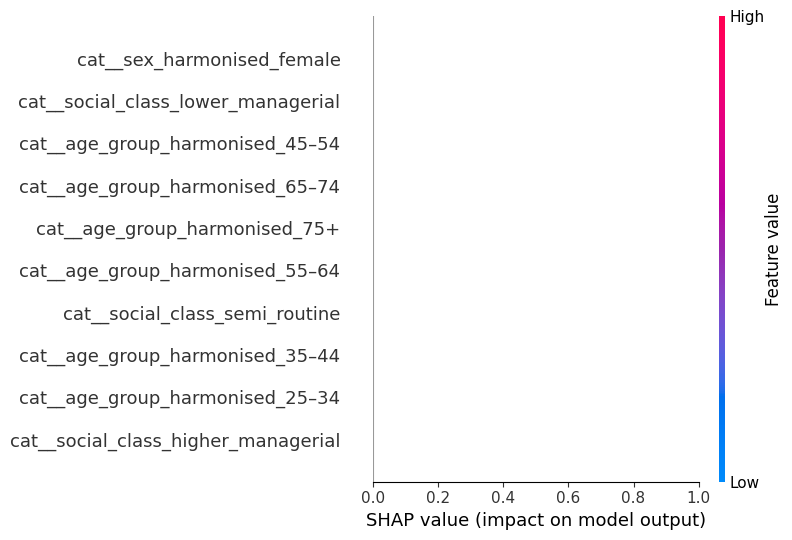

In [35]:
# ================================================================
# 4.8 SHAP INTERACTION ANALYSIS
# Socio-economic gradients and effect modification
# ================================================================

import shap
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# Ensure we use the trained LightGBM model
# ------------------------------------------------
# Assumes:
# - model_lgbm  → trained LightGBM model
# - X_train_enc → encoded training features
# - feature_names → column names after encoding
model_lgbm = lgbm

explainer = shap.TreeExplainer(model_lgbm)
shap_values = explainer.shap_values(X_train_enc)

# For binary classification, take SHAP values for class 1 (Risk)
shap_risk = shap_values[1]

print("=== SHAP VALUES READY ===")
print("SHAP matrix shape:", shap_risk.shape)
print("Feature count:", len(feature_names))


# ================================================================
# 4.8.1 Global SHAP Interaction Heatmap
# ================================================================

interaction_values = explainer.shap_interaction_values(X_train_enc)
interaction_risk = interaction_values[1]

plt.figure(figsize=(8, 6))
shap.summary_plot(
    interaction_risk,
    X_train_enc,
    feature_names=feature_names,
    max_display=10,
    plot_type="heatmap",
    show=True
)


=== HSE LOADED ===
Rows: 10,250 | Columns: 29

=== TARGET DISTRIBUTION ===
pgsi_risk
No risk    10011
Risk         239
Name: count, dtype: int64

=== MODELLING SAMPLE SIZE ===
(10250, 4)

=== SPLIT CHECK ===
Train: (7175, 3) | Test: (3075, 3)

Scale_pos_weight: 41.96

=== FITTING MODELS ===
[LightGBM] [Info] Number of positive: 167, number of negative: 7008
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 26
[LightGBM] [Info] Number of data points in the train set: 7175, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

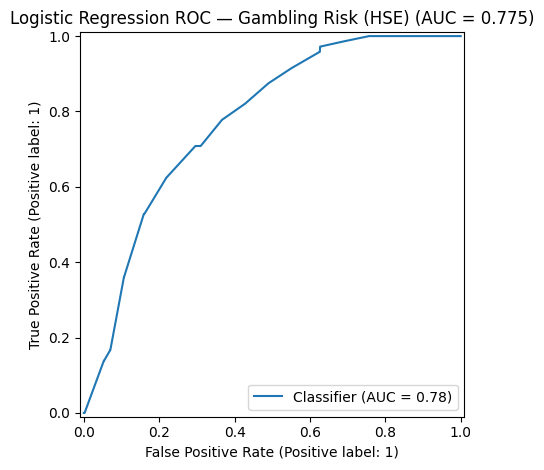

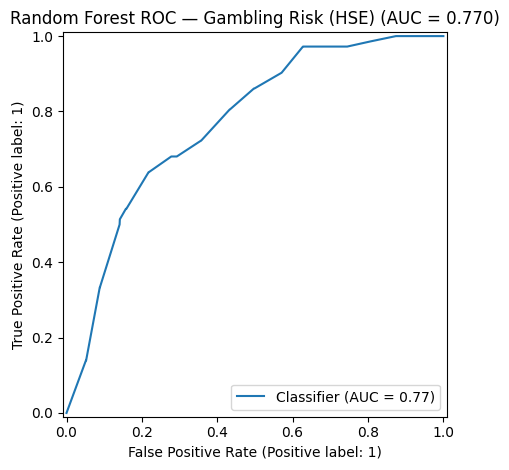

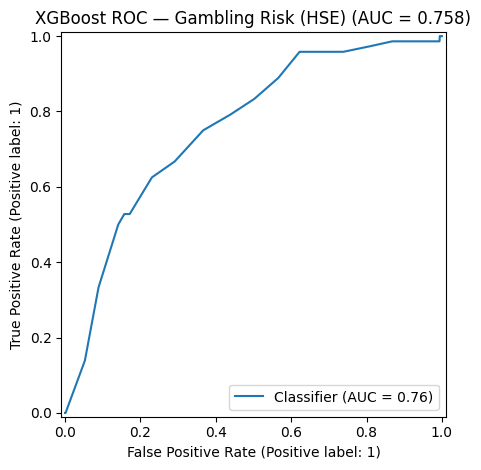

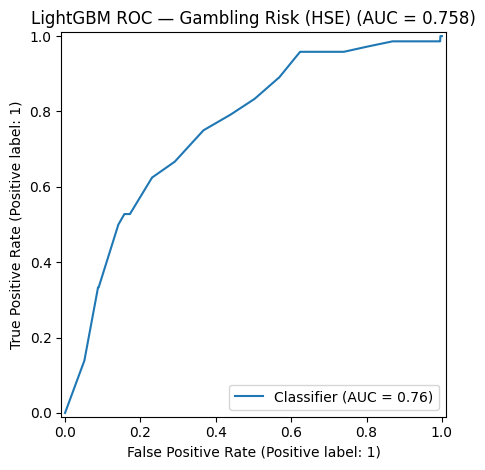

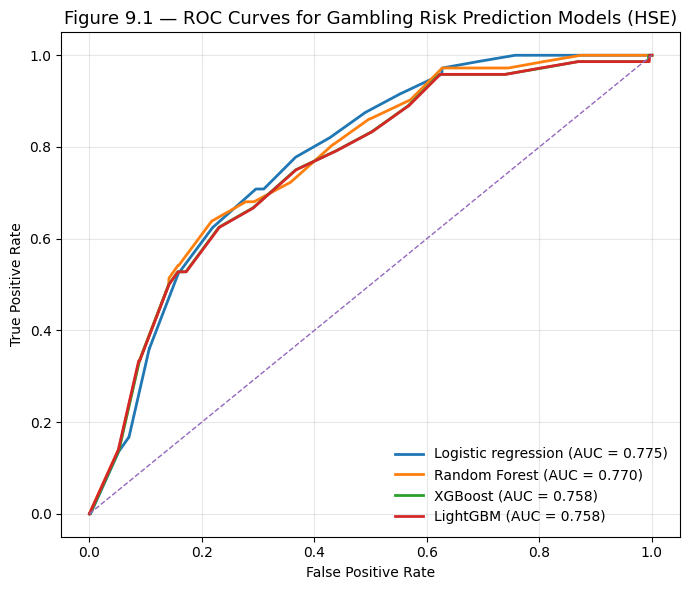


=== FINAL AUC SUMMARY (matches combined plot) ===
Logit AUC: 0.775
RF AUC:    0.770
XGB AUC:   0.758
LGBM AUC:  0.758


In [69]:
# ======================================================
# CONSISTENT PIPELINE: Split ONCE, Train ALL, Plot ROC ONCE
# ======================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

plt.style.use("default")

# ------------------------------------------------------
# 1) Load HSE
# ------------------------------------------------------
HSE_PATH = "data/processed/harmonised/hse_harmonised.parquet"
hse = pd.read_parquet(HSE_PATH)

print("=== HSE LOADED ===")
print(f"Rows: {hse.shape[0]:,} | Columns: {hse.shape[1]}")

# ------------------------------------------------------
# 2) Define binary target exactly once
# ------------------------------------------------------
hse = hse.copy()
hse["pgsi_risk"] = np.where(
    hse["pgsi_3cat"].isin(["Low risk", "At-risk gambling"]),
    "Risk",
    "No risk"
)
hse["pgsi_risk_code"] = (hse["pgsi_risk"] == "Risk").astype(int)

print("\n=== TARGET DISTRIBUTION ===")
print(hse["pgsi_risk"].value_counts())

# ------------------------------------------------------
# 3) Features (use same features for all models)
# ------------------------------------------------------
features = ["sex_harmonised", "age_group_harmonised", "income_quintile_harmonised"]

df_model = hse[["pgsi_risk_code"] + features].dropna()

X = df_model[features]
y = df_model["pgsi_risk_code"]

print("\n=== MODELLING SAMPLE SIZE ===")
print(df_model.shape)

# ------------------------------------------------------
# 4) Train/test split ONCE (this is the key fix)
# ------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("\n=== SPLIT CHECK ===")
print("Train:", X_train.shape, "| Test:", X_test.shape)

# ------------------------------------------------------
# 5) Preprocessor (shared)
# ------------------------------------------------------
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), features)
    ]
)

# ------------------------------------------------------
# 6) Models (shared split + shared preprocessing)
# ------------------------------------------------------
logit_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
])

rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nScale_pos_weight: {scale_pos_weight:.2f}")

xgb_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="auc",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ))
])

lgbm_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", lgb.LGBMClassifier(
        n_estimators=400,
        learning_rate=0.05,
        num_leaves=31,
        random_state=42,
        class_weight="balanced"
    ))
])

# ------------------------------------------------------
# 7) Fit all models ONCE
# ------------------------------------------------------
print("\n=== FITTING MODELS ===")
logit_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)
xgb_pipeline.fit(X_train, y_train)
lgbm_pipeline.fit(X_train, y_train)

# ------------------------------------------------------
# 8) Predict probabilities and STORE them (fixes NameError)
# ------------------------------------------------------
probs_logit = logit_pipeline.predict_proba(X_test)[:, 1]
probs_rf    = rf_pipeline.predict_proba(X_test)[:, 1]
probs_xgb   = xgb_pipeline.predict_proba(X_test)[:, 1]
probs_lgbm  = lgbm_pipeline.predict_proba(X_test)[:, 1]

print("\n=== SANITY CHECK: PROBABILITY VECTORS ===")
print("Logit:", probs_logit.shape)
print("RF:   ", probs_rf.shape)
print("XGB:  ", probs_xgb.shape)
print("LGBM: ", probs_lgbm.shape)

# ------------------------------------------------------
# 9) OPTIONAL: Individual ROC plots (same probs as combined)
# ------------------------------------------------------
def plot_single_roc(y_true, probs, title):
    auc = roc_auc_score(y_true, probs)
    RocCurveDisplay.from_predictions(y_true, probs)
    plt.title(f"{title} (AUC = {auc:.3f})")
    plt.tight_layout()
    plt.show()
    return auc

auc_logit = plot_single_roc(y_test, probs_logit, "Logistic Regression ROC — Gambling Risk (HSE)")
auc_rf    = plot_single_roc(y_test, probs_rf, "Random Forest ROC — Gambling Risk (HSE)")
auc_xgb   = plot_single_roc(y_test, probs_xgb, "XGBoost ROC — Gambling Risk (HSE)")
auc_lgbm  = plot_single_roc(y_test, probs_lgbm, "LightGBM ROC — Gambling Risk (HSE)")

# ------------------------------------------------------
# 10) Figure 9.1 — Combined ROC plot (will match individual AUCs)
# ------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))

for label, probs in [
    ("Logistic regression", probs_logit),
    ("Random Forest", probs_rf),
    ("XGBoost", probs_xgb),
    ("LightGBM", probs_lgbm),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    ax.plot(fpr, tpr, linewidth=2, label=f"{label} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
ax.set_title("Figure 9.1 — ROC Curves for Gambling Risk Prediction Models (HSE)", fontsize=13)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", frameon=False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== FINAL AUC SUMMARY (matches combined plot) ===")
print(f"Logit AUC: {roc_auc_score(y_test, probs_logit):.3f}")
print(f"RF AUC:    {roc_auc_score(y_test, probs_rf):.3f}")
print(f"XGB AUC:   {roc_auc_score(y_test, probs_xgb):.3f}")
print(f"LGBM AUC:  {roc_auc_score(y_test, probs_lgbm):.3f}")


=== SANITY CHECK: PROB VECTORS ===
Logistic: len=1702, min=0.0318, max=0.9076
RandomForest: len=1702, min=0.1055, max=0.7740
XGBoost: len=1702, min=0.0037, max=0.8821
LightGBM: len=1702, min=0.0000, max=0.8860

=== AUC (same test set) ===
Logistic: 0.697
RandomForest: 0.692
XGBoost: 0.695
LightGBM: 0.716


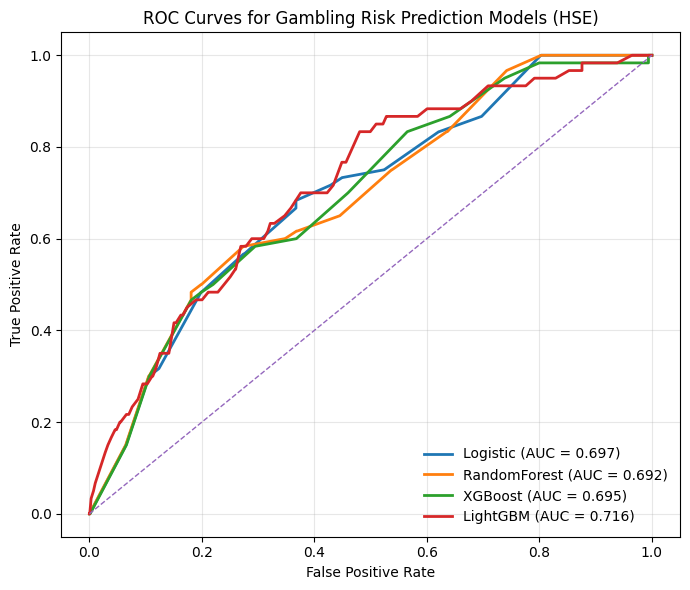

In [66]:
# ======================================================
# SANITY + ROC (single + combined) — consistent evaluation
# ======================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.style.use("default")

# ----------------------------
# 0) REQUIRED: define ONE test set & keep it fixed
# ----------------------------
# Assumes these already exist in your notebook:
# X_train, X_test, y_train, y_test
# And these trained objects exist:
# pipe (logistic pipeline), rf_pipeline, xgb_pipeline, model_lgbm (or lgbm pipeline)

# ----------------------------
# 1) Helper: safely get probabilities from either a pipeline or a raw estimator
# ----------------------------
def get_proba(model, X, name="model"):
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)[:, 1]
        return proba
    raise ValueError(f"{name} has no predict_proba()")

# ----------------------------
# 2) Get probabilities — IMPORTANT:
#    - use pipelines on RAW X_test
#    - use raw LightGBM only on ENCODED test set (X_test_enc)
# ----------------------------

# Logistic / RF / XGB are pipelines in your globals (from your keys list)
yprob_logit = get_proba(pipe, X_test, "Logistic pipeline")
yprob_rf    = get_proba(rf_pipeline, X_test, "RF pipeline")
yprob_xgb   = get_proba(xgb_pipeline, X_test, "XGB pipeline")

# LightGBM: you MUST use the same representation you trained it on.
# If you trained LightGBM on encoded features, define X_test_enc like this:

# Option A (recommended): if you have the ColumnTransformer named `preprocessor`
# and feature_names already created earlier
X_test_enc = preprocessor.transform(X_test)

# If X_test_enc comes out sparse, convert to dense if your LGBM expects dense:
try:
    X_test_enc_dense = X_test_enc.toarray()
except Exception:
    X_test_enc_dense = X_test_enc

yprob_lgbm  = get_proba(model_lgbm, X_test_enc_dense, "LightGBM")

# ----------------------------
# 3) Sanity checks (same length, valid probs)
# ----------------------------
probs = {
    "Logistic": yprob_logit,
    "RandomForest": yprob_rf,
    "XGBoost": yprob_xgb,
    "LightGBM": yprob_lgbm
}

print("=== SANITY CHECK: PROB VECTORS ===")
for k, v in probs.items():
    print(f"{k}: len={len(v)}, min={v.min():.4f}, max={v.max():.4f}")

assert all(len(v) == len(y_test) for v in probs.values()), "Mismatch: probs vs y_test length!"

# ----------------------------
# 4) AUC values — these should match your combined plot now
# ----------------------------
aucs = {k: roc_auc_score(y_test, v) for k, v in probs.items()}
print("\n=== AUC (same test set) ===")
for k, a in aucs.items():
    print(f"{k}: {a:.3f}")

# ----------------------------
# 5) Combined ROC plot (Figure 9.1)
# ----------------------------
fig, ax = plt.subplots(figsize=(7, 6))

for k, v in probs.items():
    fpr, tpr, _ = roc_curve(y_test, v)
    ax.plot(fpr, tpr, linewidth=2, label=f"{k} (AUC = {aucs[k]:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
ax.set_title("ROC Curves for Gambling Risk Prediction Models (HSE)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right", frameon=False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


SHAP values aligned with feature matrix


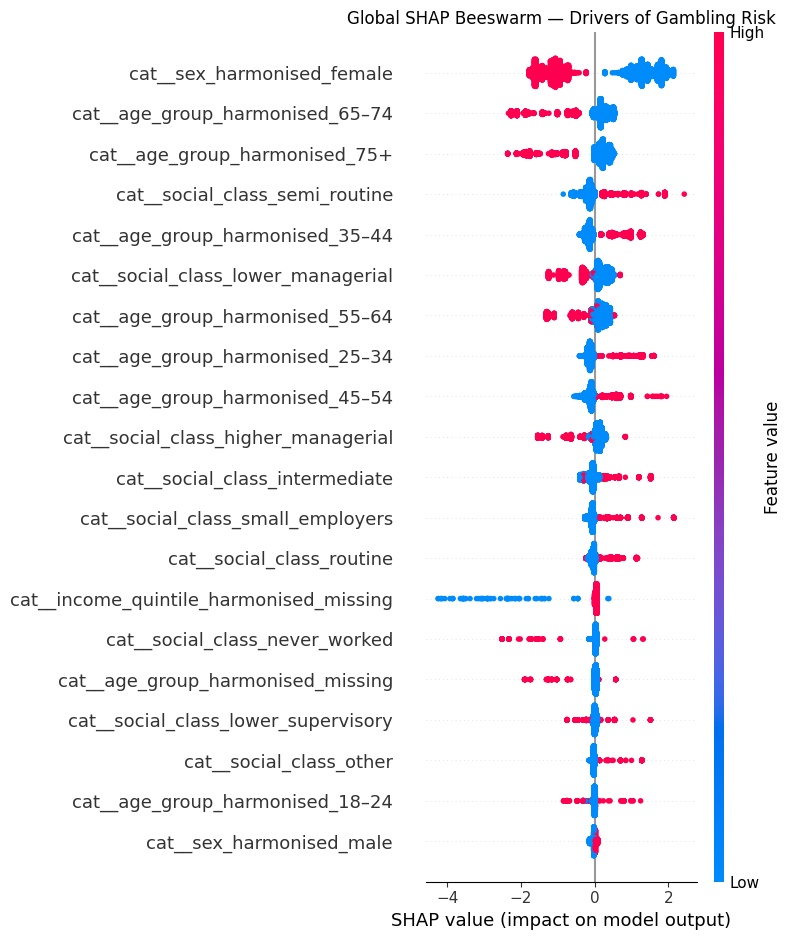

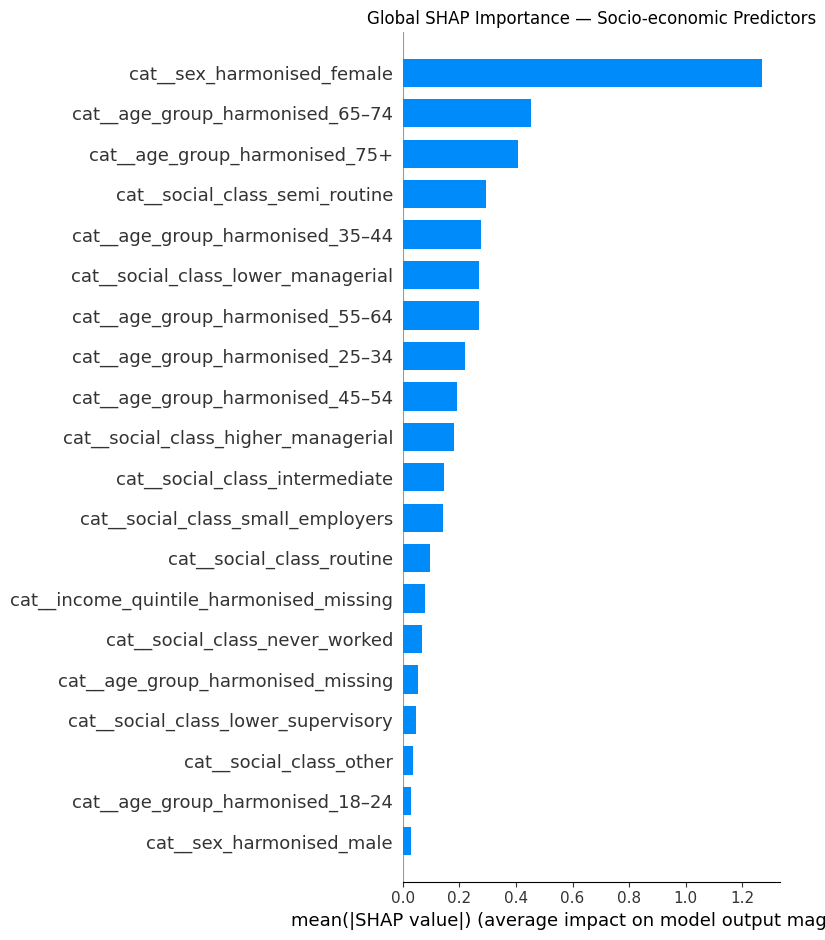

=== SHAP GLOBAL EXPLAINABILITY COMPLETE ===


In [36]:
# ================================================================
# 4.8.1 Global Explainability — SHAP (LightGBM, socio-economic)
# ================================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------
# Safety checks (never remove)
# ------------------------------------------------
assert X_train_enc.shape[0] == shap_values.shape[0], "Row mismatch"
assert X_train_enc.shape[1] == shap_values.shape[1], "Column mismatch"

print("SHAP values aligned with feature matrix")

# ------------------------------------------------
# Recover feature names from encoder
# ------------------------------------------------
feature_names = preprocessor.get_feature_names_out()

assert len(feature_names) == X_train_enc.shape[1], "Feature name mismatch"

# Convert to DataFrame for SHAP plotting
X_train_shap = pd.DataFrame(
    X_train_enc,
    columns=feature_names
)

# ------------------------------------------------
# NOTE:
# For binary LightGBM, shap_values already represent
# contribution towards the positive class (Risk)
# ------------------------------------------------
shap_risk = shap_values   

# ------------------------------------------------
# 4.8.1a Global SHAP Beeswarm (Risk)
# ------------------------------------------------
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_risk,
    X_train_shap,
    show=False,
    max_display=20
)
plt.title("Global SHAP Beeswarm — Drivers of Gambling Risk")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# 4.8.1b Global SHAP Feature Importance (bar)
# ------------------------------------------------
plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_risk,
    X_train_shap,
    plot_type="bar",
    show=False,
    max_display=20
)
plt.title("Global SHAP Importance — Socio-economic Predictors")
plt.tight_layout()
plt.show()

print("=== SHAP GLOBAL EXPLAINABILITY COMPLETE ===")


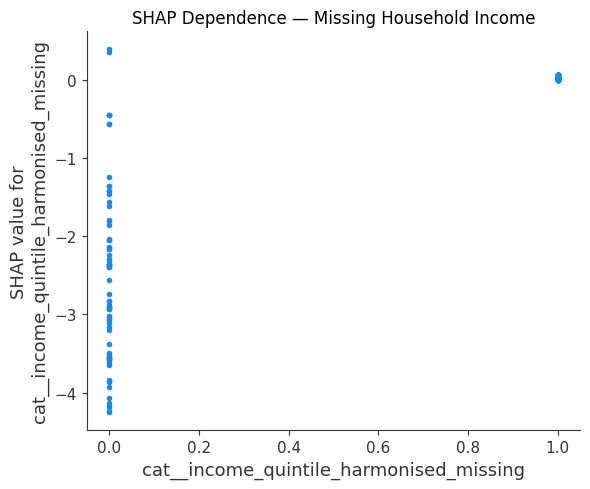

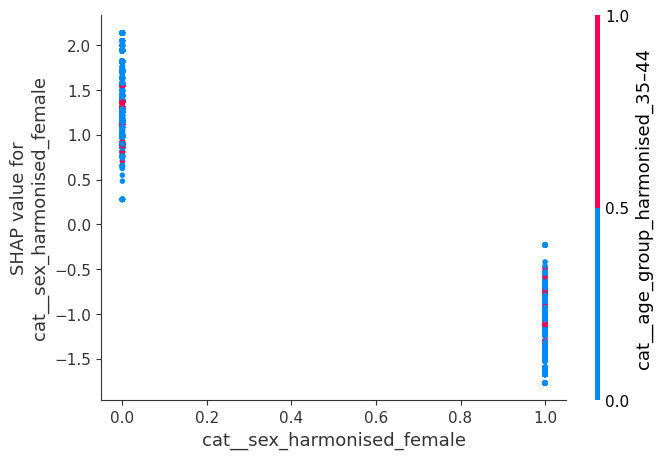

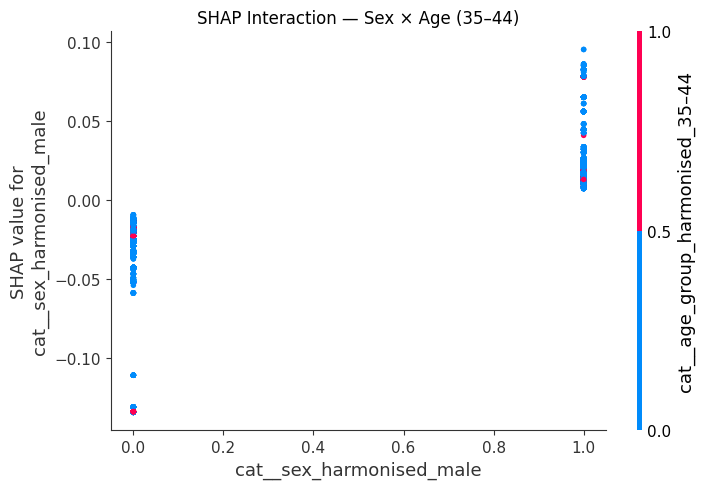

In [44]:
#   ================================================================
#   4.8.2 SHAP Dependence Plots
#   Socio-economic gradients & interactions
#   ================================================================
#   Purpose
#   Show direction of effects
#   Reveal interaction patterns (e.g. age × income, sex × class)
#   Complement global importance with local structure
# ------------------------------------------------
# Sanity checks
# ------------------------------------------------
assert isinstance(X_train_shap, pd.DataFrame)
assert shap_risk.shape == X_train_shap.shape

# ------------------------------------------------
# SHAP dependence: Income (missing vs observed)
# ------------------------------------------------
shap.dependence_plot(
    "cat__income_quintile_harmonised_missing",
    shap_risk,
    X_train_shap,
    interaction_index=None,
    show=False
)
plt.title("SHAP Dependence — Missing Household Income")
plt.tight_layout()
plt.show()

# ------------------------------------------------
# SHAP dependence: Sex × Age (example interaction)
# ------------------------------------------------
shap.dependence_plot(
    "cat__sex_harmonised_female", 
    shap_risk,
    X_train_shap,
    interaction_index="cat__age_group_harmonised_35–44",
    show=False
)
shap.dependence_plot(
    "cat__sex_harmonised_male",
    shap_risk,
    X_train_shap,
    interaction_index="cat__age_group_harmonised_35–44",
    show=False
)

plt.title("SHAP Interaction — Sex × Age (35–44)")
plt.tight_layout()
plt.show()

In [38]:
#   ================================================================
#   4.8.3 Grouped SHAP Analysis (Fairness Lens)
#   Average SHAP contribution by group
#   ================================================================
#   Purpose:
#   Detect systematic disparities
#   Support fairness-aware discussion
#   Bridge modelling → public health relevance
# ------------------------------------------------
# Build SHAP DataFrame
# ------------------------------------------------
shap_df = pd.DataFrame(
    shap_risk,
    columns=feature_names
)

# Attach original demographics
shap_df["sex"] = df.loc[X_train.index, "sex_harmonised"].values
shap_df["age7"] = df.loc[X_train.index, "age_group_harmonised"].values

# ------------------------------------------------
# Mean absolute SHAP by sex
# ------------------------------------------------
sex_shap = (
    shap_df
    .groupby("sex")
    .mean(numeric_only=True)
    .abs()
    .mean(axis=1)
)

print("\n=== Mean absolute SHAP by sex ===")
display(sex_shap.to_frame("mean_|SHAP|"))

# ------------------------------------------------
# Mean absolute SHAP by age group
# ------------------------------------------------
age_shap = (
    shap_df
    .groupby("age7")
    .mean(numeric_only=True)
    .abs()
    .mean(axis=1)
    .sort_index()
)

print("\n=== Mean absolute SHAP by age group ===")
display(age_shap.to_frame("mean_|SHAP|"))


=== Mean absolute SHAP by sex ===


,mean_|SHAP|
sex,
male,0.073514
female,0.059770
missing,NaN



=== Mean absolute SHAP by age group ===


,mean_|SHAP|
age7,
18–24,0.104683
25–34,0.103411
35–44,0.097727
45–54,0.077601
55–64,0.075901
65–74,0.100447
75+,0.098493
missing,0.106562


In [39]:
#   ================================================================
#   4.8.3 Grouped SHAP Analysis (Fairness Lens)
#   Average SHAP contribution by group
#   ================================================================
#   Purpose
#   Detect systematic disparities
#   Support fairness-aware discussion
#   Bridge modelling → public health relevance
# ------------------------------------------------
# Build SHAP DataFrame
# ------------------------------------------------
shap_df = pd.DataFrame(
    shap_risk,
    columns=feature_names
)

# Attach original demographics
shap_df["sex"] = df.loc[X_train.index, "sex_harmonised"].values
shap_df["age7"] = df.loc[X_train.index, "age_group_harmonised"].values

# ------------------------------------------------
# Mean absolute SHAP by sex
# ------------------------------------------------
sex_shap = (
    shap_df
    .groupby("sex")
    .mean(numeric_only=True)
    .abs()
    .mean(axis=1)
)

print("\n=== Mean absolute SHAP by sex ===")
display(sex_shap.to_frame("mean_|SHAP|"))

# ------------------------------------------------
# Mean absolute SHAP by age group
# ------------------------------------------------
age_shap = (
    shap_df
    .groupby("age7")
    .mean(numeric_only=True)
    .abs()
    .mean(axis=1)
    .sort_index()
)

print("\n=== Mean absolute SHAP by age group ===")
display(age_shap.to_frame("mean_|SHAP|"))


=== Mean absolute SHAP by sex ===


,mean_|SHAP|
sex,
male,0.073514
female,0.059770
missing,NaN



=== Mean absolute SHAP by age group ===


,mean_|SHAP|
age7,
18–24,0.104683
25–34,0.103411
35–44,0.097727
45–54,0.077601
55–64,0.075901
65–74,0.100447
75+,0.098493
missing,0.106562


In [40]:
#   ================================================================
#   4.8.4 SHAP Summary Table (Policy-Facing)
#   ================================================================
#   Purpose:
#   Translate ML output into interpretable evidence
#   Create a table usable in Chapter 5 / policy discussion
# ------------------------------------------------
# Global SHAP summary table
# ------------------------------------------------
shap_summary = (
    pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": np.abs(shap_risk).mean(axis=0)
    })
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

print("\n=== Top SHAP Drivers of Gambling Risk ===")
display(shap_summary.head(15))
#   ================================================================
#   Transition Marker — From Explainability to Interpretation
#   ================================================================
print("""
Explainability phase complete.

Next:
- Interpret SHAP patterns in light of gambling harm literature
- Link socio-economic gradients to public health vulnerability
- Justify threshold choice using policy trade-offs
""")


=== Top SHAP Drivers of Gambling Risk ===


,feature,mean_abs_shap
0,cat__sex_harmonised_female,1.269559
1,cat__age_group_harmonised_65–74,0.453019
2,cat__age_group_harmonised_75+,0.408223
3,cat__social_class_semi_routine,0.295987
4,cat__age_group_harmonised_35–44,0.274995
5,cat__social_class_lower_managerial,0.269068
6,cat__age_group_harmonised_55–64,0.268429
7,cat__age_group_harmonised_25–34,0.220776
8,cat__age_group_harmonised_45–54,0.191811
9,cat__social_class_higher_managerial,0.180124



Explainability phase complete.

Next:
- Interpret SHAP patterns in light of gambling harm literature
- Link socio-economic gradients to public health vulnerability
- Justify threshold choice using policy trade-offs



In [64]:
globals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'shap', 'np', 'plt', '_i2', 'pd', 'HSE_PATH', 'UKHLS_PATH', 'GSGB_PATH', 'hse', 'ukhls', 'gsgb', '_i3', 'os', 're', 'OUT_DIR', 'OUT_HSE', 'OUT_UKHLS', 'OUT_GSGB', 'SEX_CAT', 'AGE_CAT', 'INC_CAT', 'PGSI3_CAT', 'clean_sex', 'uk_age_to_band', 'HSE_AGE_MAP', 'hse_age_to_band', 'gsgb_to_age7', 'df', 'hse_income_map', '_i4', 'combined', '_i5', 'harmonisation_dict', 'df_harmonisation', '_i6', 'HSE_HARM', 'UKHLS_HARM', 'GSGB_HARM', 'datasets', 'allowed_sex', 'allowed_age', 'allowed_income', '_print_columns', '_missing_counts', '_categorical_cols', '_sample_uniques', '_invalid_values', '_value_counts', 'survey_year_range', 'name', 'dfx', 'miss', 'key_cats', 'yr', 'bad', '_i7', 'harmonised_vars', 'hse_specific_vars', 'ukhls_specific_vars', 'gsgb_specifi